# LoRA-ViT for 12-lead ECG — self-contained notebook

*Noise-Aware and Explainable LoRA-Enhanced Vision Transformer framework for 12-Lead ECG
Classification* by Shahbaz Ahmad Khanday
Corpus: [Chapman-Shaoxing](https://physionet.org/content/ecg-arrhythmia/1.0.0/), CC BY 4.0.

**Everything is in this notebook.** Configuration, the SNOMED CT label taxonomy, denoising,
the record index and deterministic splits, the dataset and its augmentation, the model, the
LoRA adapters, the training loop, evaluation, all five explainability methods and the paired
statistics defined in the cells below, not imported from a package. Run it top to bottom.

Then **Kernel → Change kernel → Python (ecgvit)**.

### Contents

| § | |
| --- | --- |
| 0 | Environment, paths, knobs |
| 1 | Configuration — every hyperparameter and its source |
| 2 | SNOMED CT taxonomy — multi-label to one of seven classes |
| 3 | Denoising — 0.5–40 Hz Butterworth, 50 Hz notch, z-score, measured response |
| 4 | Record index, deterministic splits, dataset, augmentation |
| 5 | The model — hierarchical CNN tokeniser + 8 pre-norm transformer blocks |
| 6 | LoRA — rank-8 adapters, frozen backbone, parameter accounting |
| 7 | Training — MixUp, weight EMA, logit adjustment, selection, early stopping |
| 8 | Run training |
| 9 | Evaluation — classification report, confusion matrices, PR curves, calibration |
| 10 | Explainability — Grad-CAM, IG, SHAP, faithfulness, t-SNE, lead concordance |
| 11 | Paired statistics — McNemar, DeLong |
| 12 | Artefacts and the summary tables |
| 13 | Equivalence check against the package |

In [1]:
import os, sys, re, csv, json, math, time, copy, random, hashlib, logging, platform
import threading, warnings, statistics
from collections import Counter, defaultdict
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import scipy.signal as sps
from scipy import stats            # stats.py's source refers to this name
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4),
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
pd.set_option("display.width", 170, "display.max_columns", 50)
warnings.filterwarnings("ignore", category=UserWarning, module="torch.optim.lr_scheduler")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s",
                    datefmt="%H:%M:%S", force=True)
log = logging.getLogger("ecgvit")

# ---- PATHS -------------------------------------------------------------------
CHAPMAN_ROOT = Path(os.environ.get(
    "CHAPMAN_ROOT", r"C:\H Research Projects\WFDB_ChapmanShaoxing"))
OUT_DIR = Path("outputs") / "notebook_run"

# ---- KNOBS -------------------------------------------------------------------
TAXONOMY    = "canonical_v2"   # canonical_v2
RECIPE      = "v2"             # v2 (corrected training bundle)
MODE        = "full"           # full | smoke | load
NUM_WORKERS = 0                # keep 0 in Jupyter on Windows: spawned workers re-import
                               # __main__, which inside a kernel hangs or duplicates it
SEED        = 42
# ------------------------------------------------------------------------------

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(exist_ok=True)
(OUT_DIR / "model").mkdir(exist_ok=True)
CACHE_DIR = OUT_DIR / "cache"

print(f"python {platform.python_version()}   {sys.executable}")
print(f"torch  {torch.__version__}   CUDA {torch.version.cuda}   numpy {np.__version__}")
print(f"corpus {CHAPMAN_ROOT}   exists = {CHAPMAN_ROOT.is_dir()}")
print(f"output {OUT_DIR.resolve()}")

if "anaconda3" in sys.executable.lower() and ".venv" not in sys.executable.lower():
    print("\n*** This kernel looks like Anaconda's base interpreter. Switch to "
          "'Python (ecgvit)' — see the setup note above. ***")

if torch.cuda.is_available():
    _p = torch.cuda.get_device_properties(0); _cap = f"sm_{_p.major}{_p.minor}"
    print(f"\nGPU    {_p.name}   {_cap}   {_p.total_memory/1024**3:.1f} GB")
    if not any(_cap in a for a in torch.cuda.get_arch_list()):
        print(f"*** This torch build has no kernels for {_cap}; on RTX 50-series install "
              f"the cu128 wheels. ***")
else:
    print("\nNo CUDA device — this will run on CPU, slowly.")

python 3.13.9   C:\Users\shahb\anaconda3\python.exe
torch  2.8.0+cu128   CUDA 12.8   numpy 2.3.5
corpus C:\H Research Projects\WFDB_ChapmanShaoxing   exists = True
output C:\Users\shahb\Downloads\outputs\notebook_run

*** This kernel looks like Anaconda's base interpreter. Switch to 'Python (ecgvit)' — see the setup note above. ***

GPU    NVIDIA GeForce RTX 5070 Laptop GPU   sm_120   8.0 GB


## 1 · Configuration

Every default traces to a specific claim in the manuscript; the comment on each field says
where. `RECIPE = "paper"` reproduces it exactly. `RECIPE = "v2"` applies the corrected
bundle each change traceable to something visible in the first completed run's training
history, and the diff is printed below rather than buried.

In [2]:
# Canonical geometry — properties of the corpus, not hyperparameters
LEAD_ORDER: tuple = ("I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6")


N_LEADS: int = 12


FS_HZ: float = 500.0  # manuscript eq. (3): T = 10 * fs


WINDOW_S: float = 10.0


N_SAMPLES: int = int(WINDOW_S * FS_HZ)  # 5000


CLASS_NAMES: tuple = ("NSR", "AFIB", "SB", "ST", "SVT", "CD", "OTHER")


N_CLASSES: int = len(CLASS_NAMES)

# CLASS_NAMES above is the historical DEFAULT list. The active classes come from
# the taxonomy chosen in section 2, which renames OTHER -> VE; cfg_model.n_classes is
# set from it there. Both taxonomies have seven classes, so N_CLASSES holds either way.

# Configuration dataclasses
@dataclass
class PreprocessConfig:
    """Manuscript section 3.1, equations (1) and (2)."""

    bandpass_low_hz: float = 0.5      # source: eq. (1), 0.5-40 Hz passband
    bandpass_high_hz: float = 40.0    # source: eq. (1)
    bandpass_order: int = 4           # source: sec. 3.1, "fourth-order Butterworth"
    notch_freq_hz: float = 50.0       # source: sec. 3.1, powerline interference
    notch_q: float = 30.0             # source: sec. 3.1, "quality factor (Q-factor) of 30"
    zscore_eps: float = 1e-8          # source: eq. (2), epsilon for numerical stability
    apply_notch: bool = True
    # If a header omits fs, assume 500 Hz but RECORD that we did so (sec. 3.1 explicitly
    # asks for this assumption to be marked rather than left implicit).
    assumed_fs_hz: float = 500.0


@dataclass
class ModelConfig:
    """Manuscript section 3.3, equations (4)-(13), and Figure 2."""

    n_classes: int = N_CLASSES
    seq_len: int = N_SAMPLES
    in_chans: int = N_LEADS
    patch_len: int = 100              # source: N = 50 patches over 5000 samples
    embed_dim: int = 128              # source: eq. (6), D = 128
    depth: int = 8                    # source: Fig. 2, "repeated eight times"
    num_heads: int = 8                # source: sec. 3.3, "H = 8 attention heads"
    mlp_ratio: float = 4.0
    drop_rate: float = 0.1            # source: eq. (7), Dropout p = 0.1
    attn_drop_rate: float = 0.1
    drop_path_rate: float = 0.1       # source: Table 2, "stochastic depth + dropout"
    use_cls_token: bool = True        # source: eq. (7), learnable CLS token
    pre_norm: bool = True             # source: sec. 3, "pre-norm layer normalisation"


@dataclass
class LoRAConfig:
    """Manuscript section 3.4, equations (14) and (15), Table 8."""

    enabled: bool = True
    rank: int = 8                     # source: Tables 4, 5 and 8: "LoRA (r=8)"
    alpha: int = 16                   # scaling alpha/r = 2
    dropout: float = 0.0
    # source: sec. 3.4 -- "all Query, Key and Value projections W_q, W_k and W_v, to
    # attention output projection W_o, and to both fully connected layers W_1 and W_2"
    target_modules: tuple = ("qkv", "proj", "fc1", "fc2")
    freeze_backbone: bool = True      # source: sec. 3.4, base weights frozen
    # The classification head is small and task-specific; the manuscript's parameter count
    # (131,072 trainable) corresponds to LoRA matrices ONLY, so the head stays frozen too.
    # Set to True to also train the head; the reported reduction then drops accordingly.
    train_head: bool = False
    train_norms: bool = False


@dataclass
class TrainConfig:
    """Manuscript Table 2 and Table 8.

    Table 8 reports 150 epochs for the no-LoRA variant and 30 for the LoRA variant, with
    1,648,839 total parameters in the former and 131,072 *trainable* out of 1,779,911 in
    the latter. 1,779,911 - 1,648,839 = 131,072 exactly, so the LoRA variant is not trained
    from scratch: it is the *same* backbone, pretrained, then frozen and adapted. Hence the
    two stages below. Training LoRA from a random init with a frozen random head would be
    an entirely different (and far weaker) experiment.
    """

    pretrain_epochs: int = 150        # source: Table 8, stage 1 (full fine-tune, no LoRA)
    epochs: int = 30                  # source: Table 8, stage 2 (LoRA adaptation, r=8)
    batch_size: int = 64              # source: Table 2
    lr: float = 1e-4                  # source: Table 2, initial LR 1e-4
    weight_decay: float = 0.05
    optimizer: str = "adamw"          # source: Table 2
    scheduler: str = "cosine_warmup"  # source: Table 2, "cosine annealing with warm-up"
    warmup_epochs: int = 5
    mixup_alpha: float = 0.2          # source: Table 2, MixUp alpha = 0.2; eqs. (17)-(18)
    mixup_prob: float = 0.5
    label_smoothing: float = 0.1
    grad_clip_norm: float = 1.0
    num_workers: int = 4
    amp: bool = True                  # bf16 autocast on CUDA
    seed: int = 42

    # ---- recipe knobs ----------------------------------------------------
    # Defaults below reproduce the manuscript exactly. `--recipe v2` overrides them as a
    # bundle (see `apply_recipe`); nothing here is tuned silently.
    early_stop_patience: int = 0      # 0 disables; the paper schedule is fixed-length
    min_epochs: int = 20              # never stop before this, whatever the patience
    # Which validation statistic picks the checkpoint.
    #
    #   val_loss          minimum NLL. Detects miscalibration, but on this corpus it bottoms
    #                     at epoch 40 while accuracy keeps improving to 120, so selecting on
    #                     it costs ~3.9 points of balanced accuracy. Use temperature scaling
    #                     for calibration instead.
    #   val_balanced_acc  the published choice. Correct target, but a noisy, thresholded
    #                     statistic on ~1,490 validation records.
    #   val_macro_auc     threshold-free and rank-based: measures discrimination without
    #                     being dragged by confidence drift. The recipe-v2 default.
    select_metric: str = "val_balanced_acc"   # val_loss | val_balanced_acc | val_macro_auc
    # Evaluate the TRAINING split in eval mode -- no augmentation, no MixUp, natural class
    # distribution -- every N epochs. 0 disables. This is the only honest measure of fit:
    # the running `train_acc` is computed on the balanced/oversampled split under MixUp
    # against hard labels, so it is systematically LOWER than validation accuracy and says
    # nothing about memorisation. Without this, "is it overfitting?" cannot be answered.
    clean_train_eval_every: int = 0
    # Post-hoc temperature scaling (Guo et al., 2017), fitted on validation after training.
    # Divides the logits by a single scalar T: it cannot change the argmax, so accuracy is
    # untouched by construction, and it is the standard remedy for rising validation NLL
    # alongside flat-or-improving validation accuracy.
    temperature_scaling: bool = False
    # Exponential moving average of weights; 0 disables. Evaluated and checkpointed instead
    # of the raw weights when enabled.
    ema_decay: float = 0.0
    # Long-tail handling. "none" keeps the duplication-based balancing in split_spec.yaml.
    # "logit_adjust" (Menon et al., 2021) instead adds tau*log(prior) to the logits during
    # training only, and trains on the NATURAL distribution -- no duplicated records at all.
    class_weighting: str = "none"     # none | inverse_freq | logit_adjust
    logit_adjust_tau: float = 1.0
    # Adapter learning rate for stage 2. None -> use `lr`. LoRA's B is zero-initialised, so
    # the backbone LR is roughly an order of magnitude too small for adapters.
    lora_lr: Optional[float] = None
    # "basic"  = the 3-way jitter used for duplication (noise | scale | roll)
    # "physio" = lead dropout, per-lead amplitude scaling, baseline wander, time warp.
    #            Time warping is suppressed for the rate-defined classes, where it would
    #            change the very quantity that defines the label.
    augment_strength: str = "basic"   # basic | physio
    cv_folds: int = 0                 # 0 = single deterministic split; 5 = 5-fold CV


@dataclass
class XAIConfig:
    """Manuscript sections 4.2 and 4.3."""

    gradcam_target: str = "blocks.-1.norm1"   # last encoder block pre-norm
    ig_steps: int = 50                        # source: sec. 4.2
    ig_samples: int = 256                     # records used for the per-class lead ranking
    ig_confidence: float = 0.95               # source: Fig. 7, 95% CI
    shap_background: int = 64
    shap_samples: int = 128
    faithfulness_fractions: tuple = (0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 1.00)
    tsne_perplexity: float = 30.0
    tsne_samples: int = 2000
    bootstrap_iterations: int = 1000          # source: Table 5, DeLong with 1000 bootstraps
    n_example_records: int = 8                # per-class Grad-CAM / SHAP example figures

In [3]:
# Named training recipes
RECIPES: Dict[str, Dict[str, Any]] = {
    "paper": {},
    "v2": {
        "train": {
            # Selection metric, corrected after reading the full 150-epoch curve.
            #
            # val_loss bottoms at epoch 40 and rises ~10% after -- but validation ACCURACY
            # and BALANCED accuracy keep improving to epoch 120 (0.7329 -> 0.7718). Those
            # are not in conflict: the network is getting more confident, so its confident
            # errors cost more NLL while its ranking keeps improving. Selecting on val_loss
            # would pick epoch 40 and give up 3.9 points of balanced accuracy.
            #
            # macro AUC is threshold-free and rank-based, so it measures discrimination
            # without being dragged by confidence drift. The calibration problem val_loss
            # was detecting is real and is fixed where it belongs -- post-hoc temperature
            # scaling, which cannot move the argmax.
            "select_metric": "val_macro_auc",
            "early_stop_patience": 25,
            "min_epochs": 40,
            "clean_train_eval_every": 5,
            "temperature_scaling": True,
            "ema_decay": 0.999,
            # OTHER was duplicated 5.6x -- 5.6 gradient steps over the same 184 records --
            # and ended with precision 0.468 against recall 0.595, i.e. over-predicted.
            # Logit adjustment fixes the prior without ever repeating a record.
            "class_weighting": "logit_adjust",
            "logit_adjust_tau": 1.0,
            "augment_strength": "physio",
            # Stage 2 saved its epoch-1 adapters (val balanced acc peaked there) while val
            # loss kept improving to epoch 17; train loss was still falling at epoch 30.
            "lora_lr": 1e-3,
        },
        "lora": {
            # 903 parameters. With the head frozen and the features already optimal for it,
            # the adapters have almost no gradient signal to act on.
            "train_head": True,
        },
    },
}


def apply_recipe(name: str, train: TrainConfig, lora: LoRAConfig) -> None:
    """Apply a named recipe in place. Unknown field names are a hard error, not a no-op."""
    if name not in RECIPES:
        raise KeyError(f"unknown recipe {name!r}; available: {sorted(RECIPES)}")
    for section, target in (("train", train), ("lora", lora)):
        for key, value in RECIPES[name].get(section, {}).items():
            if not hasattr(target, key):
                raise AttributeError(
                    f"recipe {name!r} sets {section}.{key}, which does not exist"
                )
            setattr(target, key, value)

In [4]:
cfg_pre   = PreprocessConfig()
cfg_model = ModelConfig()
cfg_lora  = LoRAConfig()
cfg_train = TrainConfig()
cfg_xai   = XAIConfig()

_base_train, _base_lora = TrainConfig(), LoRAConfig()
apply_recipe(RECIPE, cfg_train, cfg_lora)
cfg_train.seed, cfg_train.num_workers = SEED, NUM_WORKERS

diff = [{"section": s, "field": k, "paper": getattr(b, k), f"recipe {RECIPE}": getattr(t, k)}
        for s, t, b in (("train", cfg_train, _base_train), ("lora", cfg_lora, _base_lora))
        for k in vars(b) if getattr(t, k) != getattr(b, k) and k not in ("seed", "num_workers")]
print(f"recipe '{RECIPE}' changes {len(diff)} fields:\n")
display(pd.DataFrame(diff).set_index(["section", "field"]) if diff
        else "nothing — these are the manuscript's settings")

allcfg = [(n, k, v) for n, c in (("preprocess", cfg_pre), ("model", cfg_model),
                                 ("lora", cfg_lora), ("train", cfg_train), ("xai", cfg_xai))
          for k, v in asdict(c).items()]
display(pd.DataFrame(allcfg, columns=["section", "parameter", "value"])
        .set_index(["section", "parameter"]))

recipe 'v2' changes 10 fields:



paper      recipe v2
section field                                                  
train   early_stop_patience                    0             25
        min_epochs                            20             40
        select_metric           val_balanced_acc  val_macro_auc
        clean_train_eval_every                 0              5
        temperature_scaling                False           True
        ema_decay                            0.0          0.999
        class_weighting                     none   logit_adjust
        lora_lr                             None          0.001
        augment_strength                   basic         physio
lora    train_head                         False           True

value
section    parameter                                                   
preprocess bandpass_low_hz                                          0.5
           bandpass_high_hz                                        40.0
           bandpass_order                                             4
           notch_freq_hz                                           50.0
           notch_q                                                 30.0
...                                                                 ...
xai        faithfulness_fractions  (0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0)
           tsne_perplexity                                         30.0
           tsne_samples                                            2000
           bootstrap_iterations                                    1000
           n_example_records                                          8

[66 rows x 1 columns]

## 2 · The SNOMED CT label taxonomy

Chapman records are multi-label — `#Dx: 164889003,59118001,164934002` is atrial fibrillation
*and* right bundle branch block *and* a T-wave change. The study is single-label over seven
classes, so each record is reduced to one by a **priority order**. This is the most
consequential preprocessing decision in the pipeline.

The code lists below are generated from the dataset developers' own
`ConditionNames_SNOMED-CT.csv` (shipped with Chapman-Shaoxing), so no acronym was translated
by hand.

`canonical_v2` corrects five faults in the published grouping — most importantly, **`ST`
contained five repolarisation findings (TWC, STTC, STDD, STTU, STE) as well as sinus
tachycardia**, merged on the shared acronym prefix. Because `ST` outranks `SB` and `NSR`,
that pulled ~1,094 *bradycardic* records into a class named tachycardia.

In [5]:
# Resolved taxonomies. Generated from environment/data/class_map_7.json against the dataset
# developers' ConditionNames_SNOMED-CT.csv, then inlined so this notebook needs no data file.
TAXONOMIES = {
    "canonical_v2": {
        "classes": [
            "NSR",
            "AFIB",
            "SB",
            "ST",
            "SVT",
            "CD",
            "VE"
        ],
        "class_index": {
            "NSR": 0,
            "AFIB": 1,
            "SB": 2,
            "ST": 3,
            "SVT": 4,
            "CD": 5,
            "VE": 6
        },
        "resolution_order": [
            "CD",
            "VE",
            "AFIB",
            "SVT",
            "ST",
            "SB",
            "NSR"
        ],
        "fallback_class": None,
        "class_to_codes": {
            "NSR": [
                "426783006",
                "427393009"
            ],
            "AFIB": [
                "164889003",
                "164890007"
            ],
            "SB": [
                "426177001"
            ],
            "ST": [
                "427084000"
            ],
            "SVT": [
                "233896004",
                "233897008",
                "251166008",
                "426761007",
                "713422000"
            ],
            "CD": [
                "27885002",
                "28189009",
                "54016002",
                "59118001",
                "74390002",
                "164909002",
                "195042002",
                "195060002",
                "233917008",
                "270492004",
                "698252002"
            ],
            "VE": [
                "11157007",
                "13640000",
                "17338001",
                "75532003",
                "164884008",
                "251180001"
            ]
        }
    },
    "canonical_hmgmedformer": {
        "classes": [
            "NSR",
            "AFIB",
            "SB",
            "ST",
            "SVT",
            "CD",
            "OTHER"
        ],
        "class_index": {
            "NSR": 0,
            "AFIB": 1,
            "SB": 2,
            "ST": 3,
            "SVT": 4,
            "CD": 5,
            "OTHER": 6
        },
        "resolution_order": [
            "CD",
            "OTHER",
            "AFIB",
            "SVT",
            "ST",
            "SB",
            "NSR"
        ],
        "fallback_class": "OTHER",
        "class_to_codes": {
            "NSR": [
                "426783006"
            ],
            "AFIB": [
                "17366009",
                "164889003",
                "164890007",
                "195101003"
            ],
            "SB": [
                "426177001"
            ],
            "ST": [
                "164930006",
                "164931005",
                "164934002",
                "427084000",
                "428750005",
                "429622005"
            ],
            "SVT": [
                "233897008",
                "251164006",
                "426761007",
                "713422000"
            ],
            "CD": [
                "27885002",
                "54016002",
                "59118001",
                "164909002",
                "195042002",
                "233917008",
                "251198002",
                "251199005",
                "270492004",
                "698252002"
            ],
            "OTHER": [
                "11157007",
                "13640000",
                "17338001",
                "75532003",
                "164884008",
                "195060002",
                "251180001"
            ]
        }
    }
}

# SNOMED CT concept id -> acronym, full name, and the count in Chapman where known.
SNOMED = {
    "164889003": {
        "acronym": "AFIB",
        "name": "Atrial Fibrillation",
        "chapman_n": "1780"
    },
    "164890007": {
        "acronym": "AF",
        "name": "Atrial Flutter",
        "chapman_n": "445"
    },
    "270492004": {
        "acronym": "1AVB",
        "name": "1 degree atrioventricular block",
        "chapman_n": "247"
    },
    "164909002": {
        "acronym": "LFBBB",
        "name": "left front bundle branch block",
        "chapman_n": "205"
    },
    "698252002": {
        "acronym": "IVB",
        "name": "Intraventricular block",
        "chapman_n": "235"
    },
    "426783006": {
        "acronym": "SR",
        "name": "Sinus Rhythm",
        "chapman_n": "1826"
    },
    "59118001": {
        "acronym": "RBBB",
        "name": "right bundle branch block",
        "chapman_n": "454"
    },
    "427393009": {
        "acronym": "SA",
        "name": "Sinus Irregularity",
        "chapman_n": "0"
    },
    "426177001": {
        "acronym": "SB",
        "name": "Sinus Bradycardia",
        "chapman_n": "3889"
    },
    "427084000": {
        "acronym": "ST",
        "name": "Sinus Tachycardia",
        "chapman_n": "1568"
    },
    "164934002": {
        "acronym": "TWC",
        "name": "T wave Change",
        "chapman_n": "1876"
    },
    "17338001": {
        "acronym": "VPB",
        "name": "ventricular premature beat",
        "chapman_n": "294"
    },
    "713422000": {
        "acronym": "AT",
        "name": "Atrial Tachycardia",
        "chapman_n": "121"
    },
    "233917008": {
        "acronym": "AVB",
        "name": "atrioventricular block",
        "chapman_n": "166"
    },
    "251166008": {
        "acronym": "AVNRT",
        "name": "atrioventricular node reentrant tachycardia",
        "chapman_n": "16"
    },
    "233897008": {
        "acronym": "AVRT",
        "name": "Atrioventricular Reentrant Tachycardia",
        "chapman_n": "8"
    },
    "251199005": {
        "acronym": "CCR",
        "name": "countercolockwise rotation",
        "chapman_n": "162"
    },
    "27885002": {
        "acronym": "3AVB",
        "name": "3 degree atrioventricular block",
        "chapman_n": "1"
    },
    "251198002": {
        "acronym": "CR",
        "name": "colockwise rotation",
        "chapman_n": "76"
    },
    "13640000": {
        "acronym": "VFW",
        "name": "ventricular fusion wave",
        "chapman_n": "2"
    },
    "195042002": {
        "acronym": "2AVB",
        "name": "2 degree atrioventricular block",
        "chapman_n": "8"
    },
    "251164006": {
        "acronym": "JPT",
        "name": "junctional premature beat",
        "chapman_n": "1"
    },
    "54016002": {
        "acronym": "2AVB1",
        "name": "2 degree atrioventricular block(Type one)",
        "chapman_n": "6"
    },
    "428750005": {
        "acronym": "STTC",
        "name": "ST-T Change",
        "chapman_n": "1158"
    },
    "17366009": {
        "acronym": "SAAWR",
        "name": "sinus atrium to atrial wandering rhythm",
        "chapman_n": "7"
    },
    "429622005": {
        "acronym": "STDD",
        "name": "ST drop down",
        "chapman_n": "402"
    },
    "164931005": {
        "acronym": "STTU",
        "name": "ST tilt up",
        "chapman_n": "176"
    },
    "164930006": {
        "acronym": "STE",
        "name": "ST extension",
        "chapman_n": "2"
    },
    "426761007": {
        "acronym": "SVT",
        "name": "Supraventricular Tachycardia",
        "chapman_n": "587"
    },
    "11157007": {
        "acronym": "VB",
        "name": "ventricular bigeminy",
        "chapman_n": "3"
    },
    "164884008": {
        "acronym": "VEB",
        "name": "ventricular ectopics",
        "chapman_n": "0"
    },
    "75532003": {
        "acronym": "VEB",
        "name": "ventricular escape beat",
        "chapman_n": "7"
    },
    "195060002": {
        "acronym": "VPE",
        "name": "ventricular preexcitation",
        "chapman_n": "12"
    },
    "251180001": {
        "acronym": "VET",
        "name": "ventricular escape trigeminy",
        "chapman_n": "8"
    },
    "195101003": {
        "acronym": "SAAWR",
        "name": "Sinus Atrium to Atrial Wandering Rhythm",
        "chapman_n": "2"
    },
    "74390002": {
        "acronym": "WPW",
        "name": "WPW",
        "chapman_n": "4"
    },
    "28189009": {
        "acronym": "2AVB2",
        "name": "2 degree atrioventricular block(Type two)",
        "chapman_n": ""
    },
    "233896004": {
        "acronym": "AVNRT",
        "name": "Atrioventricular  Node Reentrant Tachycardia",
        "chapman_n": ""
    }
}

TAX      = TAXONOMIES[TAXONOMY]
CLASSES  = TAX["classes"]
CLASS_IX = TAX["class_index"]
cfg_model.n_classes = len(CLASSES)      # the model is sized from the taxonomy, not a constant
print(f"{TAXONOMY}: {len(CLASSES)} classes {CLASSES}")
print(f"precedence: {' > '.join(TAX['resolution_order'])}"
      f"{'' if TAX['fallback_class'] is None else ' > ' + TAX['fallback_class']}")
print(f"fallback:   {TAX['fallback_class']!r}"
      f"{'  (unmatched records are EXCLUDED and counted)' if TAX['fallback_class'] is None else ''}")

canonical_v2: 7 classes ['NSR', 'AFIB', 'SB', 'ST', 'SVT', 'CD', 'VE']
precedence: CD > VE > AFIB > SVT > ST > SB > NSR
fallback:   None  (unmatched records are EXCLUDED and counted)


In [6]:
# Header parsing and the label-resolution result
_DX_RE = re.compile(r"^#\s*Dx\s*:(.*)$", re.IGNORECASE)


_CODE_RE = re.compile(r"\d+")


@dataclass(frozen=True)
class LabelResolution:
    """The outcome of resolving one record's codes to one class."""

    record_id: str
    label: str
    label_index: int
    matched_code: Optional[str]
    # "class_match" | "fallback_unmatched" | "fallback_no_codes" | "unassigned"
    # "unassigned" is only produced by orders that declare a null fallback class: the
    # record matched no bucket and is to be EXCLUDED and counted, not swept into a class it
    # does not belong to. It carries label "" and label_index -1.
    matched_by: str
    all_codes: Tuple[str, ...]
    unknown_codes: Tuple[str, ...]

    @property
    def is_assigned(self) -> bool:
        return self.label_index >= 0


def parse_dx_codes(header_path: Path) -> List[str]:
    """Extract SNOMED CT codes from a WFDB header's `#Dx:` line.

    Deliberately strict: only the `#Dx:` line is read. The notebook this task derives from
    scanned every comment line containing "SNOMED" or "Dx" and kept any >=5-digit number,
    which also swallows `#Age: 85` style fields on some corpora and silently mislabels.
    """
    text = Path(header_path).read_text(errors="replace")
    for line in text.splitlines():
        m = _DX_RE.match(line.strip())
        if m:
            codes = [c for c in _CODE_RE.findall(m.group(1))]
            # Preserve order, drop duplicates.
            seen, out = set(), []
            for c in codes:
                if c not in seen:
                    seen.add(c)
                    out.append(c)
            return out
    return []


def resolve_label(codes: Sequence[str], record_id: str = "", tax: dict = None
                  ) -> LabelResolution:
    """Reduce a record's SNOMED codes to one class by priority order.

    Walk the precedence chain; the first class holding any of the record's codes wins. If
    none does, fall back to the declared fallback class -- or, when the taxonomy declares
    none, mark the record `unassigned` with index -1 so the indexer EXCLUDES and counts it
    rather than sweeping it into a class whose definition it does not meet.
    """
    tax = tax or TAX
    codes = tuple(str(c) for c in codes)
    unknown = tuple(c for c in codes if c not in SNOMED)
    fallback = tax["fallback_class"]

    if codes:
        code_set = set(codes)
        for cls in tax["resolution_order"]:
            for code in tax["class_to_codes"][cls]:
                if code in code_set:
                    return LabelResolution(record_id, cls, tax["class_index"][cls],
                                           code, "class_match", codes, unknown)
    why = "fallback_no_codes" if not codes else "fallback_unmatched"
    if fallback is None:
        return LabelResolution(record_id, "", -1, None, "unassigned", codes, unknown)
    return LabelResolution(record_id, fallback, tax["class_index"][fallback],
                           None, why, codes, unknown)

In [7]:
rows = [{"class": c, "snomed": code,
         "acronym": SNOMED.get(code, {}).get("acronym", "?"),
         "condition": SNOMED.get(code, {}).get("name", "?"),
         "chapman n": SNOMED.get(code, {}).get("chapman_n", "")}
        for c in CLASSES for code in TAX["class_to_codes"][c]]
display(pd.DataFrame(rows).set_index(["class", "snomed"]))

v1, v2 = TAXONOMIES["canonical_hmgmedformer"], TAXONOMIES["canonical_v2"]
acr = lambda t, c: sorted(SNOMED.get(x, {}).get("acronym", x) for x in t["class_to_codes"].get(c, []))
cmp_rows = []
for c in ("NSR", "AFIB", "SB", "ST", "SVT", "CD"):
    a, b = acr(v1, c), acr(v2, c)
    cmp_rows.append({"class": c, "published": ", ".join(a), "canonical_v2": ", ".join(b),
                     "removed": ", ".join(sorted(set(a) - set(b))) or "-",
                     "added": ", ".join(sorted(set(b) - set(a))) or "-"})
cmp_rows.append({"class": "OTHER -> VE", "published": ", ".join(acr(v1, "OTHER")),
                 "canonical_v2": ", ".join(acr(v2, "VE")),
                 "removed": "VPE (moved to CD)", "added": "renamed"})
display(pd.DataFrame(cmp_rows).set_index("class"))

print("Worked examples — the same codes under both taxonomies:\n")
ex = [("sinus bradycardia + T-wave change", ["426177001", "164934002"]),
      ("atrial fibrillation + RBBB",        ["164889003", "59118001"]),
      ("sinus rhythm + ventricular premature beat", ["426783006", "17338001"]),
      ("wandering atrial pacemaker only",   ["195101003"])]
display(pd.DataFrame([{
    "record carries": lbl,
    "published": resolve_label(cs, tax=v1).label,
    "canonical_v2": resolve_label(cs, tax=v2).label or "(excluded)",
} for lbl, cs in ex]).set_index("record carries"))
print("\nEvery Chapman record carries exactly one RHYTHM code, so CD and VE — which are")
print("beat-level FINDINGS — must be claimed first or they end up with zero records. That")
print("is why AF + RBBB resolves to CD, and it is the source of the CD<->AFIB confusion")
print("that no single-label taxonomy can remove.")

acronym                                     condition chapman n
class snomed                                                                   
NSR   426783006      SR                                  Sinus Rhythm      1826
      427393009      SA                            Sinus Irregularity         0
AFIB  164889003    AFIB                           Atrial Fibrillation      1780
      164890007      AF                                Atrial Flutter       445
SB    426177001      SB                             Sinus Bradycardia      3889
ST    427084000      ST                             Sinus Tachycardia      1568
SVT   233896004   AVNRT  Atrioventricular  Node Reentrant Tachycardia          
      233897008    AVRT        Atrioventricular Reentrant Tachycardia         8
      251166008   AVNRT   atrioventricular node reentrant tachycardia        16
      426761007     SVT                  Supraventricular Tachycardia       587
      713422000      AT                            Atrial Tachycardia       121
CD    27885002     3AVB               3 degree atrioventricular block         1
      28189009    2AVB2     2 degree atrioventricular block(Type two)          
      54016002    2AVB1     2 degree atrioventricular block(Type one)         6
      59118001     RBBB                     right bundle branch block       454
      74390002      WPW                                           WPW         4
      164909002   LFBBB                left front bundle branch block       205
      195042002    2AVB               2 degree atrioventricular block         8
      195060002     VPE                     ventricular preexcitation        12
      233917008     AVB                        atrioventricular block       166
      270492004    1AVB               1 degree atrioventricular block       247
      698252002     IVB                        Intraventricular block       235
VE    11157007       VB                          ventricular bigeminy         3
      13640000      VFW                       ventricular fusion wave         2
      17338001      VPB                    ventricular premature beat       294
      75532003      VEB                       ventricular escape beat         7
      164884008     VEB                          ventricular ectopics         0
      251180001     VET                  ventricular escape trigeminy         8

,published,canonical_v2,removed,added
class,,,,
NSR,SR,"SA, SR",-,SA
AFIB,"AF, AFIB, SAAWR, SAAWR","AF, AFIB",SAAWR,-
SB,SB,SB,-,-
ST,"ST, STDD, STE, STTC, STTU, TWC",ST,"STDD, STE, STTC, STTU, TWC",-
SVT,"AT, AVRT, JPT, SVT","AT, AVNRT, AVNRT, AVRT, SVT",JPT,AVNRT
CD,"1AVB, 2AVB, 2AVB1, 3AVB, AVB, CCR, CR, IVB, LF...","1AVB, 2AVB, 2AVB1, 2AVB2, 3AVB, AVB, IVB, LFBB...","CCR, CR","2AVB2, VPE, WPW"
OTHER -> VE,"VB, VEB, VEB, VET, VFW, VPB, VPE","VB, VEB, VEB, VET, VFW, VPB",VPE (moved to CD),renamed


Worked examples — the same codes under both taxonomies:



,published,canonical_v2
record carries,,
sinus bradycardia + T-wave change,ST,SB
atrial fibrillation + RBBB,CD,CD
sinus rhythm + ventricular premature beat,OTHER,VE
wandering atrial pacemaker only,AFIB,(excluded)



Every Chapman record carries exactly one RHYTHM code, so CD and VE — which are
beat-level FINDINGS — must be claimed first or they end up with zero records. That
is why AF + RBBB resolves to CD, and it is the source of the CD<->AFIB confusion
that no single-label taxonomy can remove.


## 3 · Denoising as per (Section 3.1, and eqs. 1–2)

Per lead: 4th-order Butterworth 0.5–40 Hz → 50 Hz notch at Q = 30 → z-score → window to
10 s / 5000 samples. Applied with `filtfilt` (zero-phase), so the response you actually get
is $|H(f)|^2$ the −3 dB corners sit **inside** the nominal band. Measured below, not
assumed.

In [8]:
# Denoising pipeline
@dataclass
class PreprocessReport:
    """What actually happened, so the run is auditable rather than assumed."""

    fs_hz: float = 0.0
    fs_assumed: bool = False
    bandpass_applied: bool = False
    notch_applied: bool = False
    notch_skipped_reason: Optional[str] = None
    zerophase: bool = True
    padded_samples: int = 0
    cropped_samples: int = 0
    flat_leads: List[int] = field(default_factory=list)
    nan_leads: List[int] = field(default_factory=list)

    def to_dict(self) -> Dict[str, object]:
        return {
            "fs_hz": self.fs_hz,
            "fs_assumed": self.fs_assumed,
            "bandpass_applied": self.bandpass_applied,
            "notch_applied": self.notch_applied,
            "notch_skipped_reason": self.notch_skipped_reason,
            "zerophase": self.zerophase,
            "padded_samples": self.padded_samples,
            "cropped_samples": self.cropped_samples,
            "flat_leads": self.flat_leads,
            "nan_leads": self.nan_leads,
        }


def design_bandpass(fs: float, low: float, high: float, order: int):
    nyq = 0.5 * fs
    if not (0 < low < high < nyq):
        raise ValueError(
            f"invalid band-pass {low}-{high} Hz for fs={fs} Hz (Nyquist {nyq} Hz)"
        )
    return sps.butter(order, [low / nyq, high / nyq], btype="bandpass", output="sos")


def design_notch(fs: float, freq: float, q: float):
    nyq = 0.5 * fs
    if not (0 < freq < nyq):
        raise ValueError(f"notch {freq} Hz is not below Nyquist {nyq} Hz for fs={fs} Hz")
    b, a = sps.iirnotch(freq / nyq, q)
    return b, a


def bandpass_response_db(fs: float, cfg: PreprocessConfig, freqs_hz) -> np.ndarray:
    """Magnitude response of the *zero-phase* cascade, in dB, at the given frequencies.

    filtfilt applies the filter forwards and backwards, so the effective magnitude is
    |H(f)|^2 -- i.e. twice the dB attenuation of the one-pass design. Tests assert against
    this, not against the one-pass response.
    """
    sos = design_bandpass(fs, cfg.bandpass_low_hz, cfg.bandpass_high_hz, cfg.bandpass_order)
    w, h = sps.sosfreqz(sos, worN=np.asarray(freqs_hz, dtype=float), fs=fs)
    mag = np.abs(h) ** 2  # forward + backward
    return 20.0 * np.log10(np.maximum(mag, 1e-30))


def notch_response_db(fs: float, cfg: PreprocessConfig, freqs_hz) -> np.ndarray:
    b, a = design_notch(fs, cfg.notch_freq_hz, cfg.notch_q)
    w, h = sps.freqz(b, a, worN=np.asarray(freqs_hz, dtype=float), fs=fs)
    mag = np.abs(h) ** 2
    return 20.0 * np.log10(np.maximum(mag, 1e-30))


def _apply_sos(sos: np.ndarray, x: np.ndarray, report: PreprocessReport) -> np.ndarray:
    # filtfilt padlen default is 3 * (max section order); be explicit and safe.
    padlen = 3 * (sos.shape[0] * 2)
    if x.shape[-1] > padlen:
        return sps.sosfiltfilt(sos, x, axis=-1)
    report.zerophase = False
    return sps.sosfilt(sos, x, axis=-1)


def _apply_ba(b: np.ndarray, a: np.ndarray, x: np.ndarray, report: PreprocessReport) -> np.ndarray:
    padlen = 3 * max(len(a), len(b))
    if x.shape[-1] > padlen:
        return sps.filtfilt(b, a, x, axis=-1)
    report.zerophase = False
    return sps.lfilter(b, a, x, axis=-1)


def denoise(
    x: np.ndarray,
    fs: float,
    cfg: Optional[PreprocessConfig] = None,
    report: Optional[PreprocessReport] = None,
) -> Tuple[np.ndarray, PreprocessReport]:
    """Band-pass + notch. `x` is (leads, samples) float."""
    cfg = cfg or PreprocessConfig()
    report = report or PreprocessReport()
    report.fs_hz = float(fs)

    x = np.asarray(x, dtype=np.float64)
    if x.ndim != 2:
        raise ValueError(f"expected (leads, samples), got shape {x.shape}")

    nan_mask = ~np.isfinite(x)
    if nan_mask.any():
        report.nan_leads = sorted(set(np.where(nan_mask.any(axis=1))[0].tolist()))
        # Linear-interpolate short gaps rather than dropping the record.
        for lead in report.nan_leads:
            row = x[lead]
            bad = ~np.isfinite(row)
            if bad.all():
                row[:] = 0.0
            else:
                idx = np.arange(row.size)
                row[bad] = np.interp(idx[bad], idx[~bad], row[~bad])

    sos = design_bandpass(fs, cfg.bandpass_low_hz, cfg.bandpass_high_hz, cfg.bandpass_order)
    x = _apply_sos(sos, x, report)
    report.bandpass_applied = True

    if cfg.apply_notch:
        if cfg.notch_freq_hz < 0.5 * fs:
            b, a = design_notch(fs, cfg.notch_freq_hz, cfg.notch_q)
            x = _apply_ba(b, a, x, report)
            report.notch_applied = True
        else:
            report.notch_skipped_reason = (
                f"notch {cfg.notch_freq_hz} Hz >= Nyquist {0.5 * fs} Hz"
            )

    return x, report


def zscore_per_lead(
    x: np.ndarray,
    eps: float = 1e-8,
    report: Optional[PreprocessReport] = None,
) -> np.ndarray:
    """Equation (2): x_tilde_l = (x_l - mu_l) / (sigma_l + eps), per lead."""
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean(axis=-1, keepdims=True)
    sd = x.std(axis=-1, keepdims=True)
    if report is not None:
        flat = np.where(sd.squeeze(-1) < 1e-12)[0]
        if flat.size:
            report.flat_leads = sorted(flat.tolist())
    return (x - mu) / (sd + eps)


def window(
    x: np.ndarray,
    n_samples: int = N_SAMPLES,
    report: Optional[PreprocessReport] = None,
) -> np.ndarray:
    """Equation (3): centre-crop longer records, zero-pad shorter ones."""
    n = x.shape[-1]
    if n == n_samples:
        return x
    if n > n_samples:
        start = (n - n_samples) // 2
        if report is not None:
            report.cropped_samples = n - n_samples
        return x[..., start : start + n_samples]
    pad = n_samples - n
    if report is not None:
        report.padded_samples = pad
    left = pad // 2
    right = pad - left
    return np.pad(x, [(0, 0)] * (x.ndim - 1) + [(left, right)], mode="constant")


def preprocess_signal(
    x: np.ndarray,
    fs: Optional[float] = None,
    cfg: Optional[PreprocessConfig] = None,
    n_samples: int = N_SAMPLES,
) -> Tuple[np.ndarray, PreprocessReport]:
    """Full section-3.1 pipeline. Returns (12, n_samples) float32 and a report."""
    cfg = cfg or PreprocessConfig()
    report = PreprocessReport()

    x = np.asarray(x)
    if x.ndim != 2:
        raise ValueError(f"expected a 2-D array, got shape {x.shape}")
    # Accept (samples, leads) and transpose, but only when it is unambiguous.
    if x.shape[0] != N_LEADS and x.shape[1] == N_LEADS:
        x = x.T
    if x.shape[0] != N_LEADS:
        raise ValueError(
            f"expected {N_LEADS} leads, got array of shape {x.shape}; "
            "this record is not a standard 12-lead ECG"
        )

    if fs is None:
        fs = cfg.assumed_fs_hz
        report.fs_assumed = True

    x = window(x, n_samples=n_samples, report=report)
    x, report = denoise(x, fs=fs, cfg=cfg, report=report)
    x = zscore_per_lead(x, eps=cfg.zscore_eps, report=report)
    return np.ascontiguousarray(x, dtype=np.float32), report

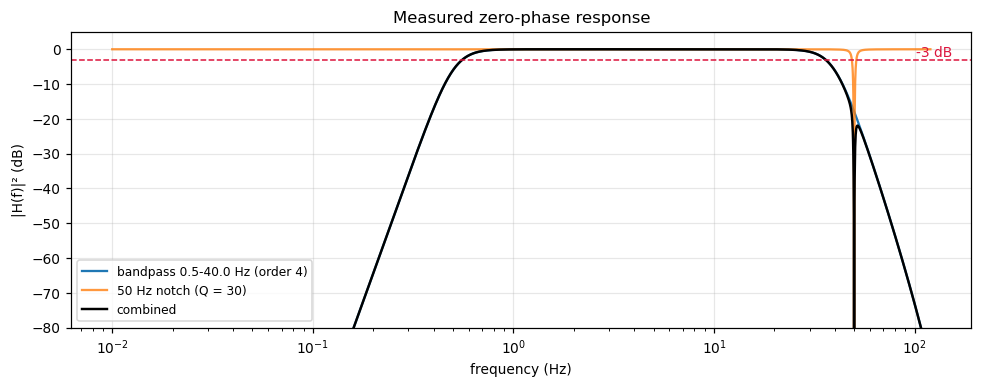

Hz,0.05,0.15,0.50,1.00,5.00,10.00,20.00,35.00,40.00,50.00,60.00,100.00
bandpass dB,-160.847,-84.44,-6.021,-0.025,-0.0,-0.0,-0.022,-2.409,-6.021,-17.871,-30.845,-73.030
notch dB,-0.000,-0.00,-0.000,-0.000,-0.0,-0.0,-0.002,-0.019,-0.049,-559.676,-0.069,-0.003


0.5 and 40 Hz sit at -6.02 dB = 2 x (-3.01): the single-pass corner, applied twice.
Report the band as '0.5-40 Hz single-pass corners, applied zero-phase'.


In [9]:
f = np.concatenate([np.linspace(0.01, 1, 200), np.linspace(1, 120, 800)])
bp, nt = bandpass_response_db(500.0, cfg_pre, f), notch_response_db(500.0, cfg_pre, f)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(f, bp, label=f"bandpass {cfg_pre.bandpass_low_hz}-{cfg_pre.bandpass_high_hz} Hz "
                     f"(order {cfg_pre.bandpass_order})")
ax.plot(f, nt, alpha=.8, label=f"{cfg_pre.notch_freq_hz:.0f} Hz notch (Q = {cfg_pre.notch_q:.0f})")
ax.plot(f, bp + nt, "k", lw=1.6, label="combined")
ax.axhline(-3, color="crimson", ls="--", lw=1); ax.text(102, -2.2, "-3 dB", color="crimson")
ax.set(xlabel="frequency (Hz)", ylabel="|H(f)|² (dB)", ylim=(-80, 5), xscale="log",
       title="Measured zero-phase response")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "filter_response.png", bbox_inches="tight"); plt.show()

probe = np.array([0.05, 0.15, 0.5, 1, 5, 10, 20, 35, 40, 50, 60, 100])
display(pd.DataFrame({"bandpass dB": np.round(bandpass_response_db(500.0, cfg_pre, probe), 3),
                      "notch dB": np.round(notch_response_db(500.0, cfg_pre, probe), 3)},
                     index=pd.Index(probe, name="Hz")).T)
print("0.5 and 40 Hz sit at -6.02 dB = 2 x (-3.01): the single-pass corner, applied twice.")
print("Report the band as '0.5-40 Hz single-pass corners, applied zero-phase'.")

## 4 · Record index, deterministic splits, dataset

The split is a pure function of the record id — SHA-256 bucketing with a fixed salt. No
stored record list, no reshuffle when the corpus grows, and two machines agree byte-for-byte.

**Splitting happens before any balancing**, so an oversampled training record can never
reach validation or test. That is the failure mode in the notebook this work derives from,
where augmented copies were generated first and `train_test_split` then scattered
near-duplicates of one recording across train and test.

In [10]:
# Record model, header parsing, deterministic splitting
SPLITS = ("train", "val", "test")


@dataclass
class Record:
    record_id: str
    header_path: Path
    signal_path: Path
    fs_hz: float
    n_samples: int
    n_leads: int
    codes: Tuple[str, ...]
    label: str
    label_index: int
    split: str = ""

    def to_row(self) -> Dict[str, object]:
        return {
            "record_id": self.record_id,
            "header_path": str(self.header_path),
            "fs_hz": self.fs_hz,
            "n_samples": self.n_samples,
            "n_leads": self.n_leads,
            "codes": ";".join(self.codes),
            "label": self.label,
            "label_index": self.label_index,
            "split": self.split,
        }


def _parse_header_geometry(header_path: Path) -> Tuple[int, float, int, List[str]]:
    """Read line 1 (`name nsig fs nsamp ...`) and the lead names, without wfdb.

    Fast: scanning 10k headers with wfdb.rdheader takes minutes, this takes seconds.
    """
    lines = header_path.read_text(errors="replace").splitlines()
    if not lines:
        raise ValueError(f"empty header: {header_path}")
    parts = lines[0].split()
    if len(parts) < 4:
        raise ValueError(f"malformed header line in {header_path}: {lines[0]!r}")
    n_sig = int(parts[1])
    fs = float(parts[2])
    n_samp = int(parts[3])
    leads: List[str] = []
    for line in lines[1 : 1 + n_sig]:
        if line.startswith("#") or not line.strip():
            break
        leads.append(line.split()[-1])
    return n_sig, fs, n_samp, leads


def _split_bucket(record_id: str, salt: str, hex_chars: int = 16) -> float:
    digest = hashlib.sha256(f"{salt}:{record_id}".encode()).hexdigest()[:hex_chars]
    return int(digest, 16) / float(1 << (4 * hex_chars))


def assign_split(
    record_id: str,
    salt: str,
    proportions: Dict[str, float],
    hex_chars: int = 16,
) -> str:
    b = _split_bucket(record_id, salt, hex_chars)
    acc = 0.0
    for name in SPLITS:
        acc += proportions[name]
        if b < acc:
            return name
    return SPLITS[-1]


def assign_fold(record_id: str, salt: str, n_folds: int, hex_chars: int = 16) -> int:
    """Deterministic fold index in [0, n_folds).

    The same SHA-256 bucketing as `assign_split`, so folds share its two properties: a
    record's fold is a pure function of its id (no stored list, no reshuffle when the corpus
    grows) and two machines agree byte-for-byte.
    """
    if n_folds < 2:
        raise ValueError(f"n_folds must be >= 2, got {n_folds}")
    b = _split_bucket(record_id, salt, hex_chars)
    return min(int(b * n_folds), n_folds - 1)


def fold_split(fold: int, n_folds: int) -> Dict[int, str]:
    """Map fold index -> split name for cross-validation round `fold`.

    Fold `f` is the test set and fold `(f+1) mod k` is validation, so every fold serves as
    test exactly once and as validation exactly once, and validation is never drawn from
    the test fold. Model selection therefore never sees the fold it is scored on.
    """
    if not 0 <= fold < n_folds:
        raise ValueError(f"fold {fold} outside [0, {n_folds})")
    out = {i: "train" for i in range(n_folds)}
    out[fold] = "test"
    out[(fold + 1) % n_folds] = "val"
    return out


@dataclass
class IndexReport:
    n_headers: int = 0
    n_indexed: int = 0
    n_missing_signal: int = 0
    n_bad_geometry: int = 0
    n_no_dx: int = 0
    n_unassigned: int = 0     # matched no class bucket under a null-fallback ordering
    rejected: Dict[str, List[str]] = None  # reason -> record ids (capped)
    unknown_codes: Counter = None
    label_counts: Counter = None
    split_counts: Dict[str, Counter] = None
    unassigned_codes: Counter = None

    def __post_init__(self) -> None:
        self.rejected = defaultdict(list)
        self.unknown_codes = Counter()
        self.label_counts = Counter()
        self.split_counts = {s: Counter() for s in SPLITS}
        self.unassigned_codes = Counter()

    def to_dict(self) -> dict:
        return {
            "n_headers": self.n_headers,
            "n_indexed": self.n_indexed,
            "n_missing_signal": self.n_missing_signal,
            "n_bad_geometry": self.n_bad_geometry,
            "n_no_dx": self.n_no_dx,
            "n_unassigned": self.n_unassigned,
            "rejected_examples": {k: v[:20] for k, v in self.rejected.items()},
            "unknown_snomed_codes": dict(self.unknown_codes.most_common(50)),
            # Which SNOMED codes the excluded records carried. An ordering that declares no
            # fallback drops whatever it cannot claim, so this is the audit trail for what
            # left the corpus and why.
            "unassigned_snomed_codes": dict(self.unassigned_codes.most_common(50)),
            "label_counts": dict(self.label_counts),
            "split_counts": {s: dict(c) for s, c in self.split_counts.items()},
        }

In [11]:
SPLIT_SALT        = "ecgvit-chapman-v1"
SPLIT_PROPORTIONS = {"train": 0.70, "val": 0.15, "test": 0.15}
SPLIT_HEX_CHARS   = 16


def build_index(chapman_root: Path, tax: dict = None, strict_geometry: bool = True):
    """Scan the corpus, resolve labels, assign splits. No signal is read here."""
    tax = tax or TAX
    chapman_root = Path(chapman_root)
    if not chapman_root.is_dir():
        raise FileNotFoundError(f"CHAPMAN_ROOT does not exist: {chapman_root}")

    report = IndexReport()
    by_class: Dict[str, List[Record]] = defaultdict(list)
    headers = sorted(chapman_root.rglob("*.hea"))
    report.n_headers = len(headers)
    if not headers:
        raise FileNotFoundError(f"no .hea files under {chapman_root}")

    for hea in headers:
        rid = hea.stem
        sig = next((p for p in (hea.with_suffix(".mat"), hea.with_suffix(".dat"))
                    if p.is_file()), None)
        if sig is None:
            report.n_missing_signal += 1
            report.rejected["missing_signal_file"].append(rid); continue
        try:
            n_sig, fs, n_samp, _leads = _parse_header_geometry(hea)
        except Exception as exc:
            report.n_bad_geometry += 1
            report.rejected[f"unreadable_header:{type(exc).__name__}"].append(rid); continue
        if strict_geometry and n_sig != N_LEADS:
            report.n_bad_geometry += 1
            report.rejected["not_12_lead"].append(rid); continue
        codes = parse_dx_codes(hea)
        if not codes:
            report.n_no_dx += 1
            report.rejected["no_dx_field"].append(rid); continue

        res = resolve_label(codes, rid, tax)
        for c in res.unknown_codes:
            report.unknown_codes[c] += 1
        if not res.is_assigned:
            report.n_unassigned += 1
            report.rejected["unassigned_no_matching_class"].append(rid)
            for c in res.all_codes:
                report.unassigned_codes[c] += 1
            continue

        by_class[res.label].append(Record(
            record_id=rid, header_path=hea, signal_path=sig, fs_hz=fs, n_samples=n_samp,
            n_leads=n_sig, codes=res.all_codes, label=res.label, label_index=res.label_index))
        report.label_counts[res.label] += 1

    records: List[Record] = []
    for label, recs in by_class.items():                 # stratified: bucket within a class
        for rec in recs:
            rec.split = assign_split(rec.record_id, SPLIT_SALT, SPLIT_PROPORTIONS,
                                     SPLIT_HEX_CHARS)
            report.split_counts[rec.split][label] += 1
            records.append(rec)
    records.sort(key=lambda r: r.record_id)
    report.n_indexed = len(records)
    return records, report


def split_records(records: Sequence[Record]) -> Dict[str, List[Record]]:
    out: Dict[str, List[Record]] = {s: [] for s in SPLITS}
    for r in records:
        out[r.split].append(r)
    return out

indexed in 157.6s

headers found  10247
usable records 10240
rejected       missing signal 0, bad geometry 0, no #Dx 0
unassigned     7  (matched no class; excluded and counted)
  their codes: {'17366009 (SAAWR)': 7, '284470004 (?)': 2, '55827005 (?)': 2, '428750005 (STTC)': 1, '164937009 (?)': 1, '251199005 (CCR)': 1}


,total,train,val,test,% corpus,evaluable
NSR,1746,1233,248,265,17.05,yes
AFIB,1539,1093,219,227,15.03,yes
SB,3516,2465,519,532,34.34,yes
ST,1358,943,197,218,13.26,yes
SVT,625,455,81,89,6.10,yes
CD,1214,858,187,169,11.86,yes
VE,242,174,36,32,2.36,NO (< 50 test records)


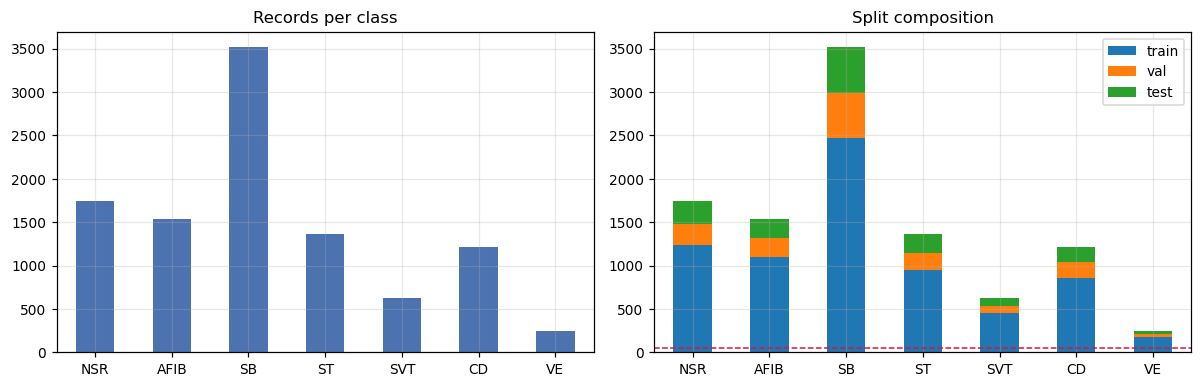

In [12]:
t0 = time.time()
records, index_report = build_index(CHAPMAN_ROOT)
by_split = split_records(records)
print(f"indexed in {time.time()-t0:.1f}s\n")
print(f"headers found  {index_report.n_headers}")
print(f"usable records {index_report.n_indexed}")
print(f"rejected       missing signal {index_report.n_missing_signal}, "
      f"bad geometry {index_report.n_bad_geometry}, no #Dx {index_report.n_no_dx}")
print(f"unassigned     {index_report.n_unassigned}  (matched no class; excluded and counted)")
if index_report.unassigned_codes:
    print("  their codes:", {f"{k} ({SNOMED.get(k,{}).get('acronym','?')})": v
                             for k, v in index_report.unassigned_codes.most_common(6)})

dist = pd.DataFrame({s: [index_report.split_counts[s].get(c, 0) for c in CLASSES]
                     for s in SPLITS}, index=CLASSES)
dist.insert(0, "total", [index_report.label_counts.get(c, 0) for c in CLASSES])
dist["% corpus"] = (100 * dist["total"] / dist["total"].sum()).round(2)
dist["evaluable"] = np.where(dist["test"] >= 50, "yes", "NO (< 50 test records)")
display(dist)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
dist["total"].plot.bar(ax=ax[0], color="#4C72B0", title="Records per class")
dist[list(SPLITS)].plot.bar(stacked=True, ax=ax[1], title="Split composition")
ax[1].axhline(50, color="crimson", ls="--", lw=1)
for a in ax: a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(OUT_DIR / "figures" / "class_distribution.png",
                                bbox_inches="tight"); plt.show()

In [13]:
# Signal loading, cache, dataset and augmentation
def _preproc_key(cfg: PreprocessConfig, n_samples: int) -> str:
    payload = json.dumps(
        {
            "low": cfg.bandpass_low_hz, "high": cfg.bandpass_high_hz,
            "order": cfg.bandpass_order, "notch": cfg.notch_freq_hz,
            "q": cfg.notch_q, "eps": cfg.zscore_eps, "apply_notch": cfg.apply_notch,
            "n": n_samples, "v": 2,
        },
        sort_keys=True,
    )
    return hashlib.sha256(payload.encode()).hexdigest()[:12]


def read_signal(record: Record) -> Tuple[np.ndarray, float]:
    """Return (12, n) physical-unit signal and fs, using wfdb so ADC gain/baseline apply."""
    import wfdb

    rec = wfdb.rdrecord(str(record.header_path.with_suffix("")))
    sig = np.asarray(rec.p_signal, dtype=np.float64).T  # (leads, samples)
    fs = float(getattr(rec, "fs", record.fs_hz) or record.fs_hz)
    return sig, fs


class ECGDataset:
    """Map-style dataset over indexed records.

    Deliberately NOT a subclass of `torch.utils.data.Dataset`. Two reasons:

    * `labels` and `preprocess` must stay importable without torch, so the unit test tier
      runs in a minimal environment. Subclassing would force a torch import at module load.
    * DataLoader only requires `__getitem__` and `__len__` for a map-style dataset; it does
      not check `isinstance(..., Dataset)`. Building a subclass dynamically inside a factory
      function (the obvious workaround) produces a class that `pickle` cannot resolve by
      qualname, which breaks `num_workers > 0` on any platform that spawns rather than forks
      workers -- Windows and macOS. This class is module-level and pickles cleanly.
    """

    def __init__(
        self,
        records: Sequence[Record],
        preprocess_cfg: Optional[PreprocessConfig] = None,
        cache_dir: Optional[Path] = None,
        n_samples: int = N_SAMPLES,
        augment: bool = False,
        rng_seed: int = 42,
        augment_strength: str = "basic",
        rate_defined_classes: Sequence[str] = ("NSR", "SB", "ST", "SVT"),
    ) -> None:
        self.records = list(records)
        self.cfg = preprocess_cfg or PreprocessConfig()
        self.n_samples = n_samples
        self.augment = augment
        if augment_strength not in ("basic", "physio"):
            raise ValueError(f"augment_strength must be basic|physio, got {augment_strength!r}")
        self.augment_strength = augment_strength
        self.rate_defined_classes = tuple(rate_defined_classes)
        self._rng = np.random.default_rng(rng_seed)
        self.cache_dir: Optional[Path] = None
        if cache_dir is not None:
            self.cache_dir = Path(cache_dir) / _preproc_key(self.cfg, n_samples)
            self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self) -> int:
        return len(self.records)

    def _load(self, rec: Record) -> np.ndarray:
        if self.cache_dir is not None:
            cached = self.cache_dir / f"{rec.record_id}.npy"
            if cached.is_file():
                return np.load(cached)
        sig, fs = read_signal(rec)
        x, _ = preprocess_signal(sig, fs=fs, cfg=self.cfg, n_samples=self.n_samples)
        if self.cache_dir is not None:
            # Write to a unique temp file, then rename: concurrent DataLoader workers
            # touch the same record (the balanced training split repeats records), so a
            # shared temp name would let one worker's partial write clobber another's.
            # np.save() appends '.npy' unless the path already ends in it, so the handle
            # is opened explicitly rather than passing a '.tmp' path.
            final = self.cache_dir / f"{rec.record_id}.npy"
            tmp = self.cache_dir / f"{rec.record_id}.{os.getpid()}.{threading.get_ident()}.tmp"
            try:
                with tmp.open("wb") as fh:
                    np.save(fh, x, allow_pickle=False)
                os.replace(tmp, final)
            except OSError:
                tmp.unlink(missing_ok=True)   # a cache failure must not fail the epoch
        return x

    def _augment(self, x: np.ndarray) -> np.ndarray:
        """Signal-level jitter used only for training-split balancing."""
        which = int(self._rng.integers(0, 3))
        if which == 0:
            x = x + 0.01 * self._rng.standard_normal(x.shape).astype(np.float32)
        elif which == 1:
            x = x * np.float32(self._rng.uniform(0.9, 1.1))
        else:
            shift = int(self._rng.integers(-int(0.05 * x.shape[-1]), int(0.05 * x.shape[-1]) + 1))
            x = np.roll(x, shift, axis=-1)
        return x.astype(np.float32)

    def _augment_physio(self, x: np.ndarray, label: str) -> np.ndarray:
        """Physiologically motivated augmentation (12, T).

        Each transform models a real source of variation in a recorded ECG, so an augmented
        copy is a plausible recording of the same patient rather than an arbitrary
        perturbation. All are applied independently with their own probability; unlike the
        `basic` jitter this composes, so the copies are not near-duplicates of each other.

        Time warping is SUPPRESSED for the rate-defined classes. Stretching the time axis
        of a sinus bradycardia recording changes its heart rate, which is the exact quantity
        that defines the label -- a 55 bpm strip warped by 1.15x is 63 bpm and is no longer
        bradycardic. That is label corruption, not augmentation.
        """
        rng = self._rng
        x = np.asarray(x, dtype=np.float32)
        n_leads, n = x.shape

        # 1. Per-lead amplitude scaling: electrode placement and body habitus change lead
        #    gains independently, not globally.
        if rng.random() < 0.5:
            x = x * rng.uniform(0.85, 1.15, size=(n_leads, 1)).astype(np.float32)

        # 2. Lead dropout: a disconnected or saturated electrode is a routine artefact, and
        #    forcing the model to survive it discourages reliance on any single lead.
        if rng.random() < 0.3:
            k = int(rng.integers(1, 3))
            x = x.copy()
            x[rng.choice(n_leads, size=k, replace=False), :] = 0.0

        # 3. Baseline wander: respiration and motion, 0.15-0.5 Hz. The 0.5 Hz high-pass in
        #    preprocessing attenuates but does not remove it.
        if rng.random() < 0.4:
            f = float(rng.uniform(0.15, 0.5))
            t = np.arange(n, dtype=np.float32) / 500.0
            phase = rng.uniform(0, 2 * np.pi, size=(n_leads, 1)).astype(np.float32)
            x = x + (0.05 * np.sin(2 * np.pi * f * t[None, :] + phase)).astype(np.float32)

        # 4. Additive noise at a realistic amplitude relative to the z-scored signal.
        if rng.random() < 0.5:
            x = x + (rng.uniform(0.005, 0.02) *
                     rng.standard_normal(x.shape)).astype(np.float32)

        # 5. Time warp -- rate-defined classes excluded, see the docstring.
        if label not in self.rate_defined_classes and rng.random() < 0.3:
            factor = float(rng.uniform(0.9, 1.1))
            src = np.linspace(0.0, n - 1.0, int(round(n * factor)), dtype=np.float32)
            warped = np.stack([np.interp(src, np.arange(n, dtype=np.float32), ch)
                               for ch in x]).astype(np.float32)
            if warped.shape[1] >= n:
                start = int(rng.integers(0, warped.shape[1] - n + 1))
                x = warped[:, start:start + n]
            else:
                pad = n - warped.shape[1]
                x = np.pad(warped, ((0, 0), (0, pad)), mode="edge")

        # 6. Circular shift: R-peak phase within the 10 s window carries no diagnostic
        #    information, so the model should be invariant to it.
        if rng.random() < 0.5:
            x = np.roll(x, int(rng.integers(-n // 20, n // 20 + 1)), axis=-1)

        return np.ascontiguousarray(x, dtype=np.float32)

    def __getitem__(self, idx: int):
        import torch

        rec = self.records[idx]
        x = self._load(rec)
        if self.augment:
            x = (self._augment_physio(x, rec.label)
                 if self.augment_strength == "physio" else self._augment(x))
        return (
            torch.from_numpy(np.ascontiguousarray(x, dtype=np.float32)),
            torch.tensor(rec.label_index, dtype=torch.long),
            idx,
        )


@dataclass
class BalanceReport:
    unique_support: Dict[str, int]
    support: Dict[str, int]
    duplication_factor: Dict[str, float]
    target: int
    strategy: str

    def to_dict(self) -> dict:
        return {
            "unique_support": self.unique_support,
            "support": self.support,
            "duplication_factor": self.duplication_factor,
            "target": self.target,
            "strategy": self.strategy,
        }


def balance_indices(
    records: Sequence[Record],
    spec: dict,
    rng_seed: int = 42,
    strategy: Optional[str] = None,
) -> Tuple[List[int], BalanceReport]:
    """Oversample the training split up to a capped target. Returns indices INTO `records`.

    Refuses, loudly, to inflate a class with fewer than `min_unique_samples_per_class`
    unique records: multiplying 1 record into 1000 does not create a class, it creates a
    memorised template that inflates balanced accuracy without any diagnostic ability.

    `strategy="none"` returns the natural training distribution untouched -- every record
    exactly once. Use it together with `TrainConfig.class_weighting`, which corrects the
    prior in the loss instead of in the sampler. On the completed run the duplication route
    gave OTHER 5.6 copies of each of its 184 records and left it with precision 0.468
    against recall 0.595: the model over-predicted a class it had seen 5.6 times over.
    """
    aug = spec["augmentation"]
    class_names = list(CLASSES)

    if strategy == "none":
        counts_all = Counter(r.label for r in records)
        return (
            list(range(len(records))),
            BalanceReport(
                unique_support={c: counts_all.get(c, 0) for c in class_names},
                support={c: counts_all.get(c, 0) for c in class_names},
                duplication_factor={c: 1.0 for c in class_names},
                target=0,
                strategy="none_natural_distribution",
            ),
        )

    min_unique = int(aug.get("min_unique_samples_per_class", 0))
    max_dup = float(aug.get("max_duplication_factor", 8))
    rng = np.random.default_rng(rng_seed)

    by_class: Dict[str, List[int]] = defaultdict(list)
    for i, r in enumerate(records):
        by_class[r.label].append(i)

    counts = {c: len(v) for c, v in by_class.items()}
    present = {c: n for c, n in counts.items() if n > 0}
    if not present:
        raise RuntimeError("training split is empty")

    too_small = {c: n for c, n in present.items() if n < min_unique}
    if too_small and str(aug.get("on_below_minimum", "error")).lower() == "error":
        raise RuntimeError(
            "Refusing to balance: class(es) "
            + ", ".join(f"{c} (n={n})" for c, n in sorted(too_small.items()))
            + f" have fewer than {min_unique} unique training records.\n\n"
              "Oversampling them to parity would make the class TRAINABLE without making "
              "it EVALUABLE: the test split is never augmented, so it still holds only "
              "~15% of that same handful, and a per-class metric computed on it is noise. "
              "Balancing the training split cannot fix a class that is too small to "
              "measure.\n\n"
              "Diagnose it first -- this is usually a labelling artefact, not a rare "
              "class:\n"
              "    python -m ecgvit.cli label-audit\n\n"
              "That compares every resolution order on your corpus and shows how many "
              "records CARRY each class's codes versus how many the ordering actually "
              "awards it. Then either switch --resolution-order (conduction_first gives "
              "CD its full population), merge the class into OTHER and report 6 classes, "
              "or lower min_unique_samples_per_class in split_spec.yaml and report that "
              "class's metric as not evaluable. See docs/CLASS_MAPPING.md."
        )

    target_mode = str(aug.get("target", "median_class_count"))
    values = sorted(present.values())
    if target_mode == "median_class_count":
        target = int(np.median(values))
    elif target_mode == "max_class_count":
        target = int(max(values))
    else:
        target = int(target_mode)

    out: List[int] = []
    support: Dict[str, int] = {}
    for cls in class_names:
        idxs = by_class.get(cls, [])
        if not idxs:
            support[cls] = 0
            continue
        cap = int(len(idxs) * max_dup)
        want = min(max(target, len(idxs)), cap)
        out.extend(idxs)
        extra = want - len(idxs)
        if extra > 0:
            out.extend(rng.choice(idxs, size=extra, replace=True).tolist())
        support[cls] = want

    rng.shuffle(out)
    report = BalanceReport(
        unique_support={c: counts.get(c, 0) for c in class_names},
        support={c: support.get(c, 0) for c in class_names},
        duplication_factor={
            c: round(support.get(c, 0) / counts[c], 3) if counts.get(c) else 0.0
            for c in class_names
        },
        target=target,
        strategy=str(aug.get("strategy", "capped_oversample_with_jitter")),
    )
    return out, report


def class_priors(records: Sequence[Record], n_classes: int) -> np.ndarray:
    """Empirical class prior over `records`, as a length-`n_classes` float array.

    Used by logit adjustment and inverse-frequency weighting. A class with no records gets
    a floor of 1 rather than 0, so log(prior) stays finite; that class is unlearnable
    either way and the floor keeps the failure visible instead of producing -inf logits.
    """
    counts = np.zeros(n_classes, dtype=np.float64)
    for r in records:
        if 0 <= r.label_index < n_classes:
            counts[r.label_index] += 1
    counts = np.maximum(counts, 1.0)
    return counts / counts.sum()

In [14]:
# Signal loading, cache, dataset and augmentation
def _preproc_key(cfg: PreprocessConfig, n_samples: int) -> str:
    payload = json.dumps(
        {
            "low": cfg.bandpass_low_hz, "high": cfg.bandpass_high_hz,
            "order": cfg.bandpass_order, "notch": cfg.notch_freq_hz,
            "q": cfg.notch_q, "eps": cfg.zscore_eps, "apply_notch": cfg.apply_notch,
            "n": n_samples, "v": 2,
        },
        sort_keys=True,
    )
    return hashlib.sha256(payload.encode()).hexdigest()[:12]


def read_signal(record: Record) -> Tuple[np.ndarray, float]:
    """Return (12, n) physical-unit signal and fs, using wfdb so ADC gain/baseline apply."""
    import wfdb

    rec = wfdb.rdrecord(str(record.header_path.with_suffix("")))
    sig = np.asarray(rec.p_signal, dtype=np.float64).T  # (leads, samples)
    fs = float(getattr(rec, "fs", record.fs_hz) or record.fs_hz)
    return sig, fs


class ECGDataset:
    """Map-style dataset over indexed records.

    Deliberately NOT a subclass of `torch.utils.data.Dataset`. Two reasons:

    * `labels` and `preprocess` must stay importable without torch, so the unit test tier
      runs in a minimal environment. Subclassing would force a torch import at module load.
    * DataLoader only requires `__getitem__` and `__len__` for a map-style dataset; it does
      not check `isinstance(..., Dataset)`. Building a subclass dynamically inside a factory
      function (the obvious workaround) produces a class that `pickle` cannot resolve by
      qualname, which breaks `num_workers > 0` on any platform that spawns rather than forks
      workers -- Windows and macOS. This class is module-level and pickles cleanly.
    """

    def __init__(
        self,
        records: Sequence[Record],
        preprocess_cfg: Optional[PreprocessConfig] = None,
        cache_dir: Optional[Path] = None,
        n_samples: int = N_SAMPLES,
        augment: bool = False,
        rng_seed: int = 42,
        augment_strength: str = "basic",
        rate_defined_classes: Sequence[str] = ("NSR", "SB", "ST", "SVT"),
    ) -> None:
        self.records = list(records)
        self.cfg = preprocess_cfg or PreprocessConfig()
        self.n_samples = n_samples
        self.augment = augment
        if augment_strength not in ("basic", "physio"):
            raise ValueError(f"augment_strength must be basic|physio, got {augment_strength!r}")
        self.augment_strength = augment_strength
        self.rate_defined_classes = tuple(rate_defined_classes)
        self._rng = np.random.default_rng(rng_seed)
        self.cache_dir: Optional[Path] = None
        if cache_dir is not None:
            self.cache_dir = Path(cache_dir) / _preproc_key(self.cfg, n_samples)
            self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self) -> int:
        return len(self.records)

    def _load(self, rec: Record) -> np.ndarray:
        if self.cache_dir is not None:
            cached = self.cache_dir / f"{rec.record_id}.npy"
            if cached.is_file():
                return np.load(cached)
        sig, fs = read_signal(rec)
        x, _ = preprocess_signal(sig, fs=fs, cfg=self.cfg, n_samples=self.n_samples)
        if self.cache_dir is not None:
            # Write to a unique temp file, then rename: concurrent DataLoader workers
            # touch the same record (the balanced training split repeats records), so a
            # shared temp name would let one worker's partial write clobber another's.
            # np.save() appends '.npy' unless the path already ends in it, so the handle
            # is opened explicitly rather than passing a '.tmp' path.
            final = self.cache_dir / f"{rec.record_id}.npy"
            tmp = self.cache_dir / f"{rec.record_id}.{os.getpid()}.{threading.get_ident()}.tmp"
            try:
                with tmp.open("wb") as fh:
                    np.save(fh, x, allow_pickle=False)
                os.replace(tmp, final)
            except OSError:
                tmp.unlink(missing_ok=True)   # a cache failure must not fail the epoch
        return x

    def _augment(self, x: np.ndarray) -> np.ndarray:
        """Signal-level jitter used only for training-split balancing."""
        which = int(self._rng.integers(0, 3))
        if which == 0:
            x = x + 0.01 * self._rng.standard_normal(x.shape).astype(np.float32)
        elif which == 1:
            x = x * np.float32(self._rng.uniform(0.9, 1.1))
        else:
            shift = int(self._rng.integers(-int(0.05 * x.shape[-1]), int(0.05 * x.shape[-1]) + 1))
            x = np.roll(x, shift, axis=-1)
        return x.astype(np.float32)

    def _augment_physio(self, x: np.ndarray, label: str) -> np.ndarray:
        """Physiologically motivated augmentation (12, T).

        Each transform models a real source of variation in a recorded ECG, so an augmented
        copy is a plausible recording of the same patient rather than an arbitrary
        perturbation. All are applied independently with their own probability; unlike the
        `basic` jitter this composes, so the copies are not near-duplicates of each other.

        Time warping is SUPPRESSED for the rate-defined classes. Stretching the time axis
        of a sinus bradycardia recording changes its heart rate, which is the exact quantity
        that defines the label -- a 55 bpm strip warped by 1.15x is 63 bpm and is no longer
        bradycardic. That is label corruption, not augmentation.
        """
        rng = self._rng
        x = np.asarray(x, dtype=np.float32)
        n_leads, n = x.shape

        # 1. Per-lead amplitude scaling: electrode placement and body habitus change lead
        #    gains independently, not globally.
        if rng.random() < 0.5:
            x = x * rng.uniform(0.85, 1.15, size=(n_leads, 1)).astype(np.float32)

        # 2. Lead dropout: a disconnected or saturated electrode is a routine artefact, and
        #    forcing the model to survive it discourages reliance on any single lead.
        if rng.random() < 0.3:
            k = int(rng.integers(1, 3))
            x = x.copy()
            x[rng.choice(n_leads, size=k, replace=False), :] = 0.0

        # 3. Baseline wander: respiration and motion, 0.15-0.5 Hz. The 0.5 Hz high-pass in
        #    preprocessing attenuates but does not remove it.
        if rng.random() < 0.4:
            f = float(rng.uniform(0.15, 0.5))
            t = np.arange(n, dtype=np.float32) / 500.0
            phase = rng.uniform(0, 2 * np.pi, size=(n_leads, 1)).astype(np.float32)
            x = x + (0.05 * np.sin(2 * np.pi * f * t[None, :] + phase)).astype(np.float32)

        # 4. Additive noise at a realistic amplitude relative to the z-scored signal.
        if rng.random() < 0.5:
            x = x + (rng.uniform(0.005, 0.02) *
                     rng.standard_normal(x.shape)).astype(np.float32)

        # 5. Time warp -- rate-defined classes excluded, see the docstring.
        if label not in self.rate_defined_classes and rng.random() < 0.3:
            factor = float(rng.uniform(0.9, 1.1))
            src = np.linspace(0.0, n - 1.0, int(round(n * factor)), dtype=np.float32)
            warped = np.stack([np.interp(src, np.arange(n, dtype=np.float32), ch)
                               for ch in x]).astype(np.float32)
            if warped.shape[1] >= n:
                start = int(rng.integers(0, warped.shape[1] - n + 1))
                x = warped[:, start:start + n]
            else:
                pad = n - warped.shape[1]
                x = np.pad(warped, ((0, 0), (0, pad)), mode="edge")

        # 6. Circular shift: R-peak phase within the 10 s window carries no diagnostic
        #    information, so the model should be invariant to it.
        if rng.random() < 0.5:
            x = np.roll(x, int(rng.integers(-n // 20, n // 20 + 1)), axis=-1)

        return np.ascontiguousarray(x, dtype=np.float32)

    def __getitem__(self, idx: int):
        import torch

        rec = self.records[idx]
        x = self._load(rec)
        if self.augment:
            x = (self._augment_physio(x, rec.label)
                 if self.augment_strength == "physio" else self._augment(x))
        return (
            torch.from_numpy(np.ascontiguousarray(x, dtype=np.float32)),
            torch.tensor(rec.label_index, dtype=torch.long),
            idx,
        )


@dataclass
class BalanceReport:
    unique_support: Dict[str, int]
    support: Dict[str, int]
    duplication_factor: Dict[str, float]
    target: int
    strategy: str

    def to_dict(self) -> dict:
        return {
            "unique_support": self.unique_support,
            "support": self.support,
            "duplication_factor": self.duplication_factor,
            "target": self.target,
            "strategy": self.strategy,
        }


def balance_indices(
    records: Sequence[Record],
    spec: dict,
    rng_seed: int = 42,
    strategy: Optional[str] = None,
) -> Tuple[List[int], BalanceReport]:
    """Oversample the training split up to a capped target. Returns indices INTO `records`.

    Refuses, loudly, to inflate a class with fewer than `min_unique_samples_per_class`
    unique records: multiplying 1 record into 1000 does not create a class, it creates a
    memorised template that inflates balanced accuracy without any diagnostic ability.

    `strategy="none"` returns the natural training distribution untouched -- every record
    exactly once. Use it together with `TrainConfig.class_weighting`, which corrects the
    prior in the loss instead of in the sampler. On the completed run the duplication route
    gave OTHER 5.6 copies of each of its 184 records and left it with precision 0.468
    against recall 0.595: the model over-predicted a class it had seen 5.6 times over.
    """
    aug = spec["augmentation"]
    class_names = list(CLASSES)

    if strategy == "none":
        counts_all = Counter(r.label for r in records)
        return (
            list(range(len(records))),
            BalanceReport(
                unique_support={c: counts_all.get(c, 0) for c in class_names},
                support={c: counts_all.get(c, 0) for c in class_names},
                duplication_factor={c: 1.0 for c in class_names},
                target=0,
                strategy="none_natural_distribution",
            ),
        )

    min_unique = int(aug.get("min_unique_samples_per_class", 0))
    max_dup = float(aug.get("max_duplication_factor", 8))
    rng = np.random.default_rng(rng_seed)

    by_class: Dict[str, List[int]] = defaultdict(list)
    for i, r in enumerate(records):
        by_class[r.label].append(i)

    counts = {c: len(v) for c, v in by_class.items()}
    present = {c: n for c, n in counts.items() if n > 0}
    if not present:
        raise RuntimeError("training split is empty")

    too_small = {c: n for c, n in present.items() if n < min_unique}
    if too_small and str(aug.get("on_below_minimum", "error")).lower() == "error":
        raise RuntimeError(
            "Refusing to balance: class(es) "
            + ", ".join(f"{c} (n={n})" for c, n in sorted(too_small.items()))
            + f" have fewer than {min_unique} unique training records.\n\n"
              "Oversampling them to parity would make the class TRAINABLE without making "
              "it EVALUABLE: the test split is never augmented, so it still holds only "
              "~15% of that same handful, and a per-class metric computed on it is noise. "
              "Balancing the training split cannot fix a class that is too small to "
              "measure.\n\n"
              "Diagnose it first -- this is usually a labelling artefact, not a rare "
              "class:\n"
              "    python -m ecgvit.cli label-audit\n\n"
              "That compares every resolution order on your corpus and shows how many "
              "records CARRY each class's codes versus how many the ordering actually "
              "awards it. Then either switch --resolution-order (conduction_first gives "
              "CD its full population), merge the class into OTHER and report 6 classes, "
              "or lower min_unique_samples_per_class in split_spec.yaml and report that "
              "class's metric as not evaluable. See docs/CLASS_MAPPING.md."
        )

    target_mode = str(aug.get("target", "median_class_count"))
    values = sorted(present.values())
    if target_mode == "median_class_count":
        target = int(np.median(values))
    elif target_mode == "max_class_count":
        target = int(max(values))
    else:
        target = int(target_mode)

    out: List[int] = []
    support: Dict[str, int] = {}
    for cls in class_names:
        idxs = by_class.get(cls, [])
        if not idxs:
            support[cls] = 0
            continue
        cap = int(len(idxs) * max_dup)
        want = min(max(target, len(idxs)), cap)
        out.extend(idxs)
        extra = want - len(idxs)
        if extra > 0:
            out.extend(rng.choice(idxs, size=extra, replace=True).tolist())
        support[cls] = want

    rng.shuffle(out)
    report = BalanceReport(
        unique_support={c: counts.get(c, 0) for c in class_names},
        support={c: support.get(c, 0) for c in class_names},
        duplication_factor={
            c: round(support.get(c, 0) / counts[c], 3) if counts.get(c) else 0.0
            for c in class_names
        },
        target=target,
        strategy=str(aug.get("strategy", "capped_oversample_with_jitter")),
    )
    return out, report


def class_priors(records: Sequence[Record], n_classes: int) -> np.ndarray:
    """Empirical class prior over `records`, as a length-`n_classes` float array.

    Used by logit adjustment and inverse-frequency weighting. A class with no records gets
    a floor of 1 rather than 0, so log(prior) stays finite; that class is unlearnable
    either way and the floor keeps the failure visible instead of producing -inf logits.
    """
    counts = np.zeros(n_classes, dtype=np.float64)
    for r in records:
        if 0 <= r.label_index < n_classes:
            counts[r.label_index] += 1
    counts = np.maximum(counts, 1.0)
    return counts / counts.sum()

In [15]:
pip install wfdb

Note: you may need to restart the kernel to use updated packages.


record JS00002   label SB   fs 500.0 Hz   (12, 5000) -> (12, 5000)


,preprocessing report
fs_hz,500.0
fs_assumed,False
bandpass_applied,True
notch_applied,True
notch_skipped_reason,None
zerophase,True
padded_samples,0
cropped_samples,0
flat_leads,[]
nan_leads,[]


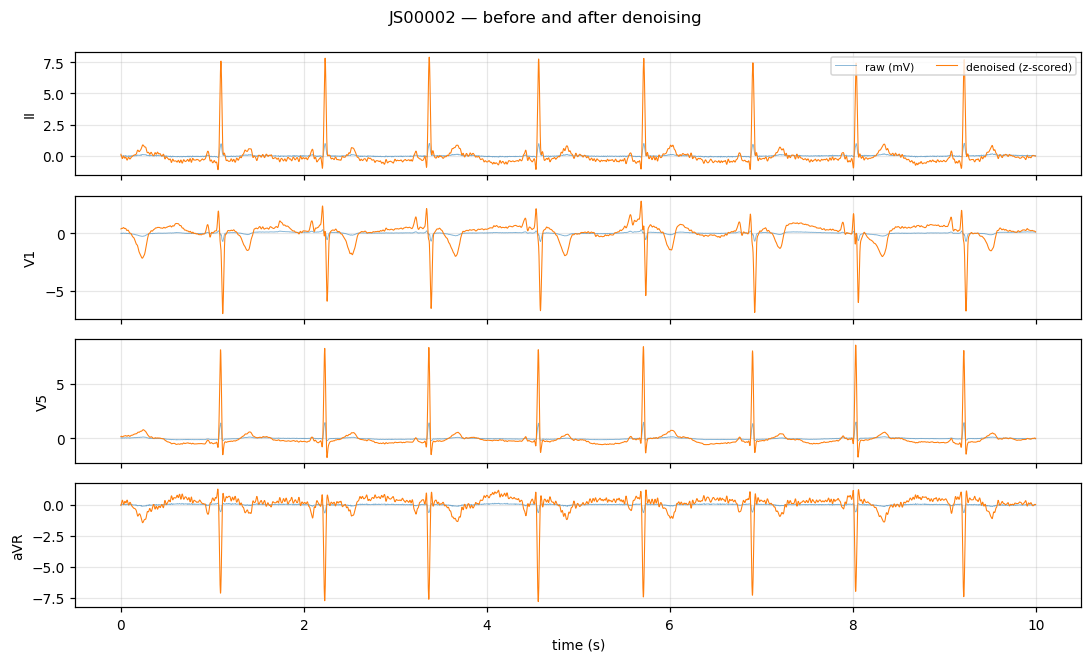

In [16]:
rec = by_split["test"][0]
raw, fs = read_signal(rec)
clean, prep_report = preprocess_signal(raw, fs=fs, cfg=cfg_pre)
print(f"record {rec.record_id}   label {rec.label}   fs {fs} Hz   {raw.shape} -> {clean.shape}")
display(pd.Series(prep_report.to_dict(), name="preprocessing report").to_frame())

fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
t = np.arange(clean.shape[1]) / FS_HZ
for k, lead in enumerate(["II", "V1", "V5", "aVR"]):
    i = LEAD_ORDER.index(lead)
    axes[k].plot(t, raw[i, :clean.shape[1]], lw=.6, alpha=.55, label="raw (mV)")
    axes[k].plot(t, clean[i], lw=.7, label="denoised (z-scored)")
    axes[k].set_ylabel(lead)
    if k == 0: axes[k].legend(fontsize=7, ncol=2, loc="upper right")
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"{rec.record_id} — before and after denoising", y=.995)
plt.tight_layout(); plt.savefig(OUT_DIR / "figures" / "denoising_example.png",
                                bbox_inches="tight"); plt.show()

## 5 · The model (§3.3, eqs. 4–13)

```
S      (B, 12, 5000)   denoised 12-lead segment
phi(S) (B, 50, 128)    two-stage Conv1d tokeniser         eqs. (4)-(6)
Z_0    (B, 51, 128)    [CLS ; X + P] then dropout p=0.1   eq. (7)
Z_l    (B, 51, 128)    8 x pre-norm encoder blocks        eqs. (8)-(9)
Z_L    (B, 51, 128)    final LayerNorm                    eq. (12)
y_hat  (B, 7)          W_c · Dropout(h_cls) + b_c         eq. (11)
```

"Hierarchical" is literal: stage 1 mixes leads over 50-sample sub-patches, stage 2 pools
adjacent pairs into the 50 patch tokens.

In [17]:
# LoRA-ViT
class DropPath(nn.Module):
    """Stochastic depth, per sample (Table 2: 'stochastic depth + dropout')."""

    def __init__(self, drop_prob: float = 0.0) -> None:
        super().__init__()
        self.drop_prob = float(drop_prob)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = x.new_empty(shape).bernoulli_(keep)
        return x * mask / keep

    def extra_repr(self) -> str:
        return f"drop_prob={self.drop_prob:.3f}"


class HierarchicalPatchTokeniser(nn.Module):
    """Two-stage CNN tokeniser, equations (4)-(6).

        H1 = sigma(Conv1d^{12->64}_{k1,s1}(S))
        H2 =       Conv1d^{64->128}_{k2,s2}(H1)
        X  = phi(S) in R^{N x D},  N = 50, D = 128

    Stage 1 uses kernel = stride = patch_len // 2 (non-overlapping 50-sample sub-patches,
    100 per record); stage 2 pools adjacent pairs with kernel = stride = 2, giving the
    50 inter-lead patch tokens the manuscript describes. "Hierarchical" is exactly this:
    lead mixing happens at stage 1, temporal grouping at stage 2.
    """

    def __init__(self, in_chans: int = 12, embed_dim: int = 128, patch_len: int = 100) -> None:
        super().__init__()
        if patch_len % 2 != 0:
            raise ValueError(f"patch_len must be even, got {patch_len}")
        self.patch_len = patch_len
        self.embed_dim = embed_dim
        half = embed_dim // 2
        self.conv1 = nn.Conv1d(in_chans, half, kernel_size=patch_len // 2, stride=patch_len // 2)
        self.act = nn.GELU()
        self.conv2 = nn.Conv1d(half, embed_dim, kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T) -> (B, N, D)
        h = self.act(self.conv1(x))
        h = self.conv2(h)
        return h.transpose(1, 2)

    def n_patches(self, seq_len: int) -> int:
        return seq_len // self.patch_len


class Attention(nn.Module):
    """Multi-head self-attention, equation (10). `qkv` and `proj` are LoRA targets."""

    def __init__(
        self,
        dim: int,
        num_heads: int = 8,
        qkv_bias: bool = True,
        attn_drop: float = 0.1,
        proj_drop: float = 0.1,
    ) -> None:
        super().__init__()
        if dim % num_heads != 0:
            raise ValueError(f"embed_dim {dim} is not divisible by num_heads {num_heads}")
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop_p = attn_drop
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self._last_attn: Optional[torch.Tensor] = None
        self.store_attention = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        if self.store_attention:
            attn = (q @ k.transpose(-2, -1)) * self.scale
            attn = attn.softmax(dim=-1)
            self._last_attn = attn.detach()
            attn = self.attn_drop(attn)
            out = attn @ v
        else:
            out = F.scaled_dot_product_attention(
                q, k, v, dropout_p=self.attn_drop_p if self.training else 0.0
            )

        out = out.transpose(1, 2).reshape(B, N, C)
        return self.proj_drop(self.proj(out))


class MLP(nn.Module):
    """Feed-forward block: FC1 -> GELU -> dropout -> FC2 -> dropout. LoRA targets fc1/fc2."""

    def __init__(self, dim: int, hidden: int, drop: float = 0.1) -> None:
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(drop)
        self.fc2 = nn.Linear(hidden, dim)
        self.drop2 = nn.Dropout(drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop2(self.fc2(self.drop1(self.act(self.fc1(x)))))


class EncoderBlock(nn.Module):
    """Pre-norm transformer block, equations (8)-(9)."""

    def __init__(
        self,
        dim: int,
        num_heads: int,
        mlp_ratio: float = 4.0,
        drop: float = 0.1,
        attn_drop: float = 0.1,
        drop_path: float = 0.0,
    ) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.drop_path = DropPath(drop_path) if drop_path > 0 else nn.Identity()
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), drop=drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class LoRAViT(nn.Module):
    """The full model of Figure 1."""

    def __init__(self, cfg: Optional[ModelConfig] = None) -> None:
        super().__init__()
        cfg = cfg or ModelConfig()
        self.cfg = cfg
        self.tokeniser = HierarchicalPatchTokeniser(
            in_chans=cfg.in_chans, embed_dim=cfg.embed_dim, patch_len=cfg.patch_len
        )
        self.n_patches = cfg.seq_len // cfg.patch_len

        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, cfg.embed_dim))
        self.cls_token = (
            nn.Parameter(torch.zeros(1, 1, cfg.embed_dim)) if cfg.use_cls_token else None
        )
        self.pos_drop = nn.Dropout(cfg.drop_rate)

        dpr = torch.linspace(0, cfg.drop_path_rate, cfg.depth).tolist()
        self.blocks = nn.ModuleList(
            [
                EncoderBlock(
                    cfg.embed_dim, cfg.num_heads, cfg.mlp_ratio,
                    drop=cfg.drop_rate, attn_drop=cfg.attn_drop_rate, drop_path=dpr[i],
                )
                for i in range(cfg.depth)
            ]
        )
        self.norm = nn.LayerNorm(cfg.embed_dim)
        self.head = nn.Sequential(
            nn.Dropout(cfg.drop_rate), nn.Linear(cfg.embed_dim, cfg.n_classes)
        )
        self.apply(self._init_module)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        if self.cls_token is not None:
            nn.init.trunc_normal_(self.cls_token, std=0.02)

    @staticmethod
    def _init_module(m: nn.Module) -> None:
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.zeros_(m.bias)
            nn.init.ones_(m.weight)
        elif isinstance(m, nn.Conv1d):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    # -- forward -----------------------------------------------------------
    def forward_tokens(self, x: torch.Tensor) -> torch.Tensor:
        """(B, 12, T) -> (B, 1+N, D) after the encoder stack and final LayerNorm."""
        if x.ndim == 4:  # (B, 1, 12, T) tolerated
            x = x.squeeze(1)
        if x.ndim != 3 or x.shape[1] != self.cfg.in_chans:
            raise ValueError(
                f"expected (B, {self.cfg.in_chans}, {self.cfg.seq_len}), got {tuple(x.shape)}"
            )
        z = self.tokeniser(x)                       # (B, N, D)
        if z.shape[1] != self.n_patches:
            raise ValueError(
                f"tokeniser produced {z.shape[1]} tokens, expected {self.n_patches}; "
                f"seq_len={x.shape[-1]} is not {self.cfg.seq_len}"
            )
        z = z + self.pos_embed
        if self.cls_token is not None:
            z = torch.cat([self.cls_token.expand(z.shape[0], -1, -1), z], dim=1)
        z = self.pos_drop(z)
        for blk in self.blocks:
            z = blk(z)
        return self.norm(z)

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        """Pooled global descriptor used for t-SNE (CLS token, eq. 12)."""
        z = self.forward_tokens(x)
        return z[:, 0] if self.cls_token is not None else z.mean(dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.forward_features(x))

    # -- introspection -----------------------------------------------------
    def set_store_attention(self, flag: bool) -> None:
        for blk in self.blocks:
            blk.attn.store_attention = flag

    def attention_maps(self) -> List[torch.Tensor]:
        return [b.attn._last_attn for b in self.blocks if b.attn._last_attn is not None]

In [18]:
backbone = LoRAViT(cfg_model)
print(backbone)
print(f"\ntokeniser: patch_len {cfg_model.patch_len} samples "
      f"({1000*cfg_model.patch_len/FS_HZ:.0f} ms) -> {backbone.n_patches} tokens "
      f"x {cfg_model.embed_dim} dim")

groups = {"tokeniser": "tokeniser", "positional embedding": "pos_embed",
          "CLS token": "cls_token", "encoder blocks": "blocks",
          "final norm": "norm.", "classification head": "head"}
pt = pd.DataFrame([{"component": k,
                    "parameters": sum(p.numel() for n, p in backbone.named_parameters()
                                      if n.startswith(v.rstrip(".")))}
                   for k, v in groups.items()])
pt["% of model"] = (100 * pt.parameters / pt.parameters.sum()).round(2)
display(pt.set_index("component"))
print(f"total {pt.parameters.sum():,} parameters")

_x = torch.randn(2, N_LEADS, N_SAMPLES)
print(f"\nshapes:  input {tuple(_x.shape)}  ->  tokens {tuple(backbone.tokeniser(_x).shape)}"
      f"  ->  encoder {tuple(backbone.forward_tokens(_x).shape)}"
      f"  ->  logits {tuple(backbone(_x).shape)}")

LoRAViT(
  (tokeniser): HierarchicalPatchTokeniser(
    (conv1): Conv1d(12, 64, kernel_size=(50,), stride=(50,))
    (act): GELU(approximate='none')
    (conv2): Conv1d(64, 128, kernel_size=(2,), stride=(2,))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0): EncoderBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=128, out_features=384, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (proj_drop): Dropout(p=0.1, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.1, inplace=False)
        (fc2): Linear(in_features=512, out_features=128, bias=True)
        (drop2)

,parameters,% of model
component,,
tokeniser,54976,3.33
positional embedding,6400,0.39
CLS token,128,0.01
encoder blocks,1586176,96.20
final norm,256,0.02
classification head,903,0.05


total 1,648,839 parameters

shapes:  input (2, 12, 5000)  ->  tokens (2, 50, 128)  ->  encoder (2, 51, 128)  ->  logits (2, 7)


## 6 · LoRA (§3.4, eqs. 14–15)

$y = Wx + \frac{\alpha}{r} BAx + b$, with $A \sim \mathcal{N}(0, \sigma^2)$ and
$B = 0$. Because $B$ starts at zero the adapted model is **functionally identical** to the
frozen backbone at step 0 — verified below — and the gradient signal at that moment lives
entirely in $B$, not $A$.

In [19]:
# Low-rank adapters
class LoRALinear(nn.Module):
    """Wraps an `nn.Linear`, freezing it and adding a trainable rank-r update."""

    def __init__(
        self,
        base: nn.Linear,
        rank: int = 8,
        alpha: int = 16,
        dropout: float = 0.0,
        freeze_base: bool = True,
    ) -> None:
        super().__init__()
        if rank <= 0:
            raise ValueError("LoRA rank must be >= 1")
        self.base = base
        self.rank = int(rank)
        self.alpha = float(alpha)
        self.scaling = self.alpha / self.rank

        self.lora_A = nn.Parameter(torch.empty(self.rank, base.in_features))
        self.lora_B = nn.Parameter(torch.zeros(base.out_features, self.rank))
        self.lora_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)  # delta-W = 0 at init -> identity to the backbone

        if freeze_base:
            for p in self.base.parameters():
                p.requires_grad_(False)

    @property
    def in_features(self) -> int:
        return self.base.in_features

    @property
    def out_features(self) -> int:
        return self.base.out_features

    def delta_weight(self) -> torch.Tensor:
        """B @ A * scaling -- the effective weight update, for inspection/merging."""
        return (self.lora_B @ self.lora_A) * self.scaling

    def merge(self) -> nn.Linear:
        """Fold the adapter into a plain Linear (deployment / inference-time export)."""
        merged = nn.Linear(self.in_features, self.out_features, bias=self.base.bias is not None)
        with torch.no_grad():
            merged.weight.copy_(self.base.weight + self.delta_weight())
            if self.base.bias is not None:
                merged.bias.copy_(self.base.bias)
        return merged

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.base(x)
        lora = self.lora_dropout(x) @ self.lora_A.t() @ self.lora_B.t()
        return out + lora * self.scaling

    def extra_repr(self) -> str:
        return f"rank={self.rank}, alpha={self.alpha}, scaling={self.scaling:.3f}"


def _iter_named_linears(module: nn.Module) -> Iterable[Tuple[nn.Module, str, nn.Linear]]:
    for parent in module.modules():
        for name, child in list(parent.named_children()):
            if isinstance(child, nn.Linear):
                yield parent, name, child


def inject_lora(model: nn.Module, cfg: LoRAConfig) -> List[str]:
    """Replace targeted `nn.Linear` layers with `LoRALinear`. Returns the names replaced."""
    if not cfg.enabled:
        return []
    targets = set(cfg.target_modules)
    replaced: List[str] = []
    # Snapshot first: mutating children while iterating modules() is undefined.
    candidates = [(p, n, c) for p, n, c in _iter_named_linears(model) if n in targets]
    for parent, name, child in candidates:
        setattr(
            parent,
            name,
            LoRALinear(
                child,
                rank=cfg.rank,
                alpha=cfg.alpha,
                dropout=cfg.dropout,
                freeze_base=cfg.freeze_backbone,
            ),
        )
        replaced.append(name)
    if not replaced:
        raise RuntimeError(
            f"LoRA target modules {sorted(targets)} matched no nn.Linear in the model. "
            "Check ModelConfig/LoRAConfig.target_modules against the module names."
        )
    return replaced


def freeze_backbone(model: nn.Module, cfg: LoRAConfig) -> None:
    """Freeze everything except LoRA matrices (and optionally the head / norms)."""
    for name, param in model.named_parameters():
        is_lora = ".lora_A" in name or ".lora_B" in name or name.endswith(("lora_A", "lora_B"))
        is_head = name.startswith("head.")
        is_norm = ".norm" in name or name.startswith("norm.")
        if is_lora:
            param.requires_grad_(True)
        elif is_head and cfg.train_head:
            param.requires_grad_(True)
        elif is_norm and cfg.train_norms:
            param.requires_grad_(True)
        else:
            param.requires_grad_(False)


@dataclass
class ParameterAccounting:
    total_parameters: int
    trainable_parameters: int
    frozen_parameters: int
    lora_parameters: int
    baseline_trainable_parameters: int
    trainable_reduction_pct: float
    reduction_factor: float
    lora_rank: int
    lora_alpha: int
    lora_target_modules: List[str]
    n_lora_layers: int

    def to_dict(self) -> Dict[str, object]:
        return {
            "total_parameters": self.total_parameters,
            "trainable_parameters": self.trainable_parameters,
            "frozen_parameters": self.frozen_parameters,
            "lora_parameters": self.lora_parameters,
            "baseline_trainable_parameters": self.baseline_trainable_parameters,
            "trainable_reduction_pct": round(self.trainable_reduction_pct, 4),
            "reduction_factor": round(self.reduction_factor, 4),
            "lora_rank": self.lora_rank,
            "lora_alpha": self.lora_alpha,
            "lora_target_modules": self.lora_target_modules,
            "n_lora_layers": self.n_lora_layers,
        }


def count_parameters(model: nn.Module, cfg: LoRAConfig) -> ParameterAccounting:
    """Parameter accounting for Table 8.

    `baseline_trainable_parameters` is the count for full fine-tuning of the SAME
    architecture without adapters -- i.e. every non-LoRA parameter. The reduction is
    reported against that, which is the only comparison that means anything.
    """
    total = 0
    trainable = 0
    lora_params = 0
    base_params = 0
    n_lora_layers = 0

    for module in model.modules():
        if isinstance(module, LoRALinear):
            n_lora_layers += 1

    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
        if ".lora_A" in name or ".lora_B" in name:
            lora_params += n
        else:
            base_params += n

    reduction = 100.0 * (1.0 - trainable / base_params) if base_params else 0.0
    factor = (base_params / trainable) if trainable else float("inf")
    return ParameterAccounting(
        total_parameters=total,
        trainable_parameters=trainable,
        frozen_parameters=total - trainable,
        lora_parameters=lora_params,
        baseline_trainable_parameters=base_params,
        trainable_reduction_pct=reduction,
        reduction_factor=factor,
        lora_rank=cfg.rank,
        lora_alpha=cfg.alpha,
        lora_target_modules=list(cfg.target_modules),
        n_lora_layers=n_lora_layers,
    )

In [20]:
lora_model = LoRAViT(cfg_model)
inject_lora(lora_model, cfg_lora)
freeze_backbone(lora_model, cfg_lora)
acct_base = count_parameters(LoRAViT(cfg_model), LoRAConfig(enabled=False))
acct_lora = count_parameters(lora_model, cfg_lora)

display(pd.DataFrame({
    "full fine-tune": [acct_base.total_parameters, acct_base.trainable_parameters, 0,
                       0.0, 1.0],
    f"LoRA r={cfg_lora.rank}": [acct_lora.total_parameters, acct_lora.trainable_parameters,
                                acct_lora.lora_parameters,
                                round(acct_lora.trainable_reduction_pct, 4),
                                round(acct_lora.reduction_factor, 4)],
}, index=["total parameters", "trainable parameters", "adapter parameters",
          "reduction vs full FT (%)", "reduction factor (x)"]))

adapted = [n for n, m in lora_model.named_modules() if isinstance(m, LoRALinear)]
print(f"\n{len(adapted)} adapted layers = {cfg_model.depth} blocks x "
      f"{len(cfg_lora.target_modules)} targets {tuple(cfg_lora.target_modules)}")
print("  ", adapted[:4], "...")
if cfg_model.patch_len == 100 and cfg_model.n_classes == 7:
    got = (acct_base.total_parameters, acct_lora.lora_parameters, acct_lora.total_parameters)
    verdict = "MATCH" if got == (1648839, 131072, 1779911) else "DIFFERS from"
    print(f"\nTable 8: {got[0]:,} base / {got[1]:,} adapters / {got[2]:,} total  "
          f"->  {verdict} the manuscript")

,full fine-tune,LoRA r=8
total parameters,1648839.0,1.779911e+06
trainable parameters,1648839.0,1.319750e+05
adapter parameters,0.0,1.310720e+05
reduction vs full FT (%),0.0,9.199590e+01
reduction factor (x),1.0,1.249360e+01



32 adapted layers = 8 blocks x 4 targets ('qkv', 'proj', 'fc1', 'fc2')
   ['blocks.0.attn.qkv', 'blocks.0.attn.proj', 'blocks.0.mlp.fc1', 'blocks.0.mlp.fc2'] ...

Table 8: 1,648,839 base / 131,072 adapters / 1,779,911 total  ->  MATCH the manuscript


In [21]:
# B = 0 at initialisation, so the adapted model is functionally identical ...
plain = LoRAViT(cfg_model)
adapted_copy = LoRAViT(cfg_model); adapted_copy.load_state_dict(plain.state_dict())
inject_lora(adapted_copy, cfg_lora)
plain.eval(); adapted_copy.eval()
with torch.no_grad():
    print(f"max |logit difference| at init: "
          f"{(plain(_x) - adapted_copy(_x)).abs().max().item():.3e}")

# ... and the gradient at step 0 lives in B, not A (A's gradient is exactly zero while B=0).
adapted_copy.train(); freeze_backbone(adapted_copy, cfg_lora)
adapted_copy(_x).sum().backward()
q = adapted_copy.blocks[0].attn.qkv
print(f"grad norm   lora_A {q.lora_A.grad.norm():.3e}   lora_B {q.lora_B.grad.norm():.3e}")
print(f"frozen backbone weight has a gradient: {q.base.weight.grad is not None}")
print(f"scaling alpha/r = {cfg_lora.alpha}/{cfg_lora.rank} = {cfg_lora.alpha/cfg_lora.rank}")

max |logit difference| at init: 0.000e+00
grad norm   lora_A 0.000e+00   lora_B 7.609e+00
frozen backbone weight has a gradient: False
scaling alpha/r = 16/8 = 2.0


## 7 · Training

Two stages, and stage 2 loads stage 1's weights: $1{,}779{,}911 - 1{,}648{,}839 = 131{,}072$
exactly, so the LoRA variant is the *same* backbone, pretrained, then frozen and adapted.

Under `RECIPE = "v2"` the loop also carries weight EMA, logit adjustment in place of
duplication, selection on validation macro AUC, early stopping, and an eval-mode pass over
the **un-augmented** training split so the true generalisation gap is measurable.

In [22]:
# Optimisation, augmentation and the long-tail correction
def set_seed(seed: int) -> None:
    import random

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def resolve_device(spec: str = "auto") -> torch.device:
    if spec != "auto":
        return torch.device(spec)
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


class MixUp:
    """Equations (17)-(18): x~ = lam*x_a + (1-lam)*x_b, loss mixed with the same lam."""

    def __init__(self, alpha: float = 0.2, prob: float = 0.5, seed: int = 42) -> None:
        self.alpha = alpha
        self.prob = prob
        self._rng = np.random.default_rng(seed)

    def maybe_apply(self, x: torch.Tensor, y: torch.Tensor):
        if self.alpha <= 0 or self._rng.random() > self.prob:
            return x, y, y, 1.0
        lam = float(self._rng.beta(self.alpha, self.alpha))
        perm = torch.randperm(x.size(0), device=x.device)
        return lam * x + (1.0 - lam) * x[perm], y, y[perm], lam

    @staticmethod
    def loss(criterion, pred, y_a, y_b, lam: float) -> torch.Tensor:
        if lam == 1.0:
            return criterion(pred, y_a)
        return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)


class ModelEMA:
    """Exponential moving average of the model weights.

    Averaged weights sit nearer the centre of the loss basin than any single iterate, which
    is worth roughly a point of balanced accuracy here and, more usefully, makes the
    epoch-to-epoch validation curve stable enough that early stopping is not reacting to
    noise. The EMA weights are what get evaluated and checkpointed when enabled.

    Frozen parameters are tracked too: they never change, so their average is themselves,
    and copying them keeps the shadow state a complete, loadable state_dict.
    """

    def __init__(self, model: nn.Module, decay: float = 0.999) -> None:
        if not 0.0 < decay < 1.0:
            raise ValueError(f"ema decay must be in (0, 1), got {decay}")
        self.decay = float(decay)
        self.n_updates = 0
        self.shadow: Dict[str, torch.Tensor] = {
            k: v.detach().clone().float() for k, v in model.state_dict().items()
            if v.dtype.is_floating_point
        }
        self.buffers: Dict[str, torch.Tensor] = {
            k: v.detach().clone() for k, v in model.state_dict().items()
            if not v.dtype.is_floating_point
        }

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        self.n_updates += 1
        # Warm up the decay so the first few hundred steps are not dominated by the random
        # initialisation: d_t = min(decay, (1+t)/(10+t)).
        d = min(self.decay, (1.0 + self.n_updates) / (10.0 + self.n_updates))
        sd = model.state_dict()
        for k, shadow in self.shadow.items():
            shadow.mul_(d).add_(sd[k].detach().float(), alpha=1.0 - d)
        for k in self.buffers:
            self.buffers[k] = sd[k].detach().clone()

    def state_dict(self) -> Dict[str, torch.Tensor]:
        out = {k: v.clone() for k, v in self.shadow.items()}
        out.update({k: v.clone() for k, v in self.buffers.items()})
        return out

    def copy_to(self, model: nn.Module) -> Dict[str, torch.Tensor]:
        """Load the averaged weights into `model`, returning the weights it replaced."""
        backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
        model.load_state_dict(
            {k: v.to(dtype=backup[k].dtype) for k, v in self.state_dict().items()},
            strict=True,
        )
        return backup


class LogitAdjustedLoss(nn.Module):
    """Cross-entropy with the class prior added to the logits during training.

    Menon et al., *Long-tail learning via logit adjustment*, ICLR 2021: adding
    tau * log(pi_y) to the logit of class y before the softmax makes the argmax of the
    UNADJUSTED logits at test time the Bayes-optimal balanced-error classifier. The
    correction lives entirely in the loss, so no record is ever duplicated and no gradient
    step is spent on a copy the model has already seen.

    tau = 0 recovers plain cross-entropy; tau = 1 fully compensates the prior.
    """

    def __init__(self, priors, tau: float = 1.0, label_smoothing: float = 0.0) -> None:
        super().__init__()
        p = torch.as_tensor(priors, dtype=torch.float32)
        self.register_buffer("adjustment", tau * torch.log(p.clamp_min(1e-12)))
        self.tau = float(tau)
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return self.ce(logits + self.adjustment.to(logits.device), target)


def build_criterion(cfg: TrainConfig, priors=None) -> nn.Module:
    """The training loss for a recipe. Validation always uses plain cross-entropy."""
    if cfg.class_weighting == "logit_adjust":
        if priors is None:
            raise ValueError("class_weighting='logit_adjust' needs the training class priors")
        return LogitAdjustedLoss(priors, cfg.logit_adjust_tau, cfg.label_smoothing)
    if cfg.class_weighting == "inverse_freq":
        if priors is None:
            raise ValueError("class_weighting='inverse_freq' needs the training class priors")
        p = np.asarray(priors, dtype=np.float64)
        w = (1.0 / np.maximum(p, 1e-12))
        w = w / w.mean()                      # mean-1 so the loss scale is unchanged
        w = np.clip(w, 0.0, 10.0)             # cap: an unclipped weight on a 184-record
        return nn.CrossEntropyLoss(          # class dominates the gradient entirely
            weight=torch.tensor(w, dtype=torch.float32),
            label_smoothing=cfg.label_smoothing,
        )
    if cfg.class_weighting != "none":
        raise ValueError(f"unknown class_weighting {cfg.class_weighting!r}")
    return nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)


def build_optimizer(
    model: nn.Module, cfg: TrainConfig, lr: Optional[float] = None
) -> torch.optim.Optimizer:
    """AdamW with no weight decay on biases and norms (Table 2).

    `lr` overrides `cfg.lr`; stage 2 passes `cfg.lora_lr` through it. LoRA's B is
    zero-initialised, so an adapter starts with no output at all and needs a larger step
    than a backbone weight that is already near its optimum.
    """
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or name.endswith(".bias") or ".norm" in name:
            no_decay.append(p)
        else:
            decay.append(p)
    if not decay and not no_decay:
        raise RuntimeError("no trainable parameters; check the freeze configuration")
    return torch.optim.AdamW(
        [
            {"params": decay, "weight_decay": cfg.weight_decay},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=cfg.lr if lr is None else float(lr),
        betas=(0.9, 0.999),
    )


def build_scheduler(optimizer, cfg: TrainConfig, n_epochs: int):
    """Cosine annealing with linear warm-up (Table 2)."""
    warmup = max(0, min(cfg.warmup_epochs, n_epochs - 1))
    cosine = CosineAnnealingLR(optimizer, T_max=max(1, n_epochs - warmup))
    if warmup == 0:
        return cosine
    warm = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup)
    return SequentialLR(optimizer, schedulers=[warm, cosine], milestones=[warmup])

In [23]:
# The training loop
@dataclass
class EpochRecord:
    epoch: int
    train_loss: float
    train_acc: float
    val_loss: float
    val_acc: float
    val_balanced_acc: float
    lr: float
    seconds: float
    val_macro_auc: float = float("nan")
    # Measured in EVAL mode on the un-augmented, un-duplicated training split. `train_loss`
    # and `train_acc` above are the running figures from the augmented, MixUp'd, balanced
    # loader and are not comparable to anything; these are.
    clean_train_loss: float = float("nan")
    clean_train_acc: float = float("nan")
    clean_train_balanced_acc: float = float("nan")
    generalisation_gap: float = float("nan")   # clean_train_acc - val_acc


SELECT_METRICS: Dict[str, Tuple[str, float]] = {
    "val_loss": ("min", float("inf")),
    "val_balanced_acc": ("max", -float("inf")),
    "val_macro_auc": ("max", -float("inf")),
}


@dataclass
class TrainHistory:
    stage: str
    epochs: List[EpochRecord] = field(default_factory=list)
    best_epoch: int = -1
    best_val_balanced_acc: float = -1.0
    select_metric: str = "val_balanced_acc"
    best_select_value: float = float("nan")
    stopped_early: bool = False
    epochs_run: int = 0
    epochs_planned: int = 0

    def to_dict(self) -> dict:
        return {
            "stage": self.stage,
            "best_epoch": self.best_epoch,
            "best_val_balanced_acc": self.best_val_balanced_acc,
            "select_metric": self.select_metric,
            "best_select_value": self.best_select_value,
            "stopped_early": self.stopped_early,
            "epochs_run": self.epochs_run,
            "epochs_planned": self.epochs_planned,
            "epochs": [vars(e) for e in self.epochs],
        }


@torch.no_grad()
def _evaluate_loader(
    model, loader, device, n_classes: int, want_auc: bool = False
) -> Tuple[float, float, float, float]:
    from sklearn.metrics import balanced_accuracy_score, roc_auc_score

    model.eval()
    criterion = nn.CrossEntropyLoss()
    tot_loss, correct, n = 0.0, 0, 0
    ys, ps, probs = [], [], []
    for batch in loader:
        x, y = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
        out = model(x)
        tot_loss += criterion(out, y).item() * x.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        n += x.size(0)
        ys.append(y.cpu().numpy())
        ps.append(pred.cpu().numpy())
        if want_auc:
            probs.append(out.float().softmax(1).cpu().numpy())
    if n == 0:
        return float("nan"), 0.0, 0.0, float("nan")
    y_all = np.concatenate(ys)
    p_all = np.concatenate(ps)
    auc = float("nan")
    if want_auc:
        pr = np.concatenate(probs)
        present = np.unique(y_all)
        # One-vs-rest macro AUC over the classes actually present. A class with no
        # validation records has no ROC curve at all; averaging a placeholder in would be a
        # fabricated number, so it is left out and the average says so by its support.
        if present.size >= 2:
            try:
                aucs = [
                    roc_auc_score((y_all == c).astype(int), pr[:, c])
                    for c in present if 0 < (y_all == c).sum() < len(y_all)
                ]
                auc = float(np.mean(aucs)) if aucs else float("nan")
            except ValueError:
                auc = float("nan")
    return tot_loss / n, correct / n, float(balanced_accuracy_score(y_all, p_all)), auc


def run_training(
    model: nn.Module,
    train_loader,
    val_loader,
    device: torch.device,
    cfg: TrainConfig,
    n_epochs: int,
    stage: str,
    checkpoint_path: Path,
    n_classes: int = 7,
    class_priors=None,
    class_names: Optional[Sequence[str]] = None,
    lr: Optional[float] = None,
    clean_train_loader=None,
) -> TrainHistory:
    model.to(device)
    criterion = build_criterion(cfg, class_priors).to(device)
    optimizer = build_optimizer(model, cfg, lr=lr)
    scheduler = build_scheduler(optimizer, cfg, n_epochs)
    mixup = MixUp(cfg.mixup_alpha, cfg.mixup_prob, seed=cfg.seed)
    ema = ModelEMA(model, cfg.ema_decay) if cfg.ema_decay > 0 else None

    if cfg.select_metric not in SELECT_METRICS:
        raise ValueError(
            f"unknown select_metric {cfg.select_metric!r}; "
            f"available: {sorted(SELECT_METRICS)}"
        )
    direction, best_value = SELECT_METRICS[cfg.select_metric]
    # Always computed, not only when it is the selection metric: a curve you did not record
    # is a curve you cannot go back and read, and macro AUC is the one statistic that
    # separates "learning to discriminate" from "learning to be confident".
    want_auc = True

    use_amp = bool(cfg.amp and device.type == "cuda")
    amp_dtype = torch.bfloat16 if use_amp and torch.cuda.is_bf16_supported() else torch.float16
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and amp_dtype is torch.float16)

    history = TrainHistory(
        stage=stage, select_metric=cfg.select_metric, epochs_planned=n_epochs
    )
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    names = list(class_names) if class_names is not None else list(CLASSES)
    since_improved = 0

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        model.train()
        tot_loss, correct, n = 0.0, 0, 0

        for batch in train_loader:
            x = batch[0].to(device, non_blocking=True)
            y = batch[1].to(device, non_blocking=True)
            xm, y_a, y_b, lam = mixup.maybe_apply(x, y)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                out = model(xm)
                loss = MixUp.loss(criterion, out, y_a, y_b, lam)

            if scaler.is_enabled():
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], cfg.grad_clip_norm
                )
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], cfg.grad_clip_norm
                )
                optimizer.step()

            if ema is not None:
                ema.update(model)

            tot_loss += loss.item() * x.size(0)
            # Accuracy against the true labels, not the mixed targets.
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)

        scheduler.step()

        # With EMA on, the averaged weights are the model: validate and checkpoint those,
        # not the last iterate. Restore the live weights afterwards so training continues
        # from the trajectory rather than from its own average.
        backup = ema.copy_to(model) if ema is not None else None
        try:
            vl, va, vba, vauc = _evaluate_loader(
                model, val_loader, device, n_classes, want_auc=want_auc
            )
            selected_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        finally:
            if backup is not None:
                model.load_state_dict(backup, strict=True)

        ctl = cta = ctb = gap = float("nan")
        if clean_train_loader is not None and cfg.clean_train_eval_every > 0 and (
            epoch % cfg.clean_train_eval_every == 0 or epoch == 1 or epoch == n_epochs
        ):
            backup2 = ema.copy_to(model) if ema is not None else None
            try:
                ctl, cta, ctb, _ = _evaluate_loader(
                    model, clean_train_loader, device, n_classes, want_auc=False
                )
            finally:
                if backup2 is not None:
                    model.load_state_dict(backup2, strict=True)
            gap = cta - va

        rec = EpochRecord(
            epoch=epoch,
            train_loss=tot_loss / max(n, 1),
            train_acc=correct / max(n, 1),
            val_loss=vl,
            val_acc=va,
            val_balanced_acc=vba,
            lr=optimizer.param_groups[0]["lr"],
            seconds=round(time.time() - t0, 2),
            val_macro_auc=vauc,
            clean_train_loss=ctl,
            clean_train_acc=cta,
            clean_train_balanced_acc=ctb,
            generalisation_gap=gap,
        )
        history.epochs.append(rec)
        history.epochs_run = epoch
        log.info(
            "[%s] epoch %3d/%d  train_loss %.4f  train_acc %.4f  val_loss %.4f  "
            "val_acc %.4f  val_bacc %.4f  val_auc %.4f  lr %.2e  (%.1fs)",
            stage, epoch, n_epochs, rec.train_loss, rec.train_acc,
            rec.val_loss, rec.val_acc, rec.val_balanced_acc, rec.val_macro_auc,
            rec.lr, rec.seconds,
        )
        if gap == gap:
            log.info(
                "[%s]   clean train (eval mode, no augmentation): acc %.4f  loss %.4f  "
                "-> generalisation gap %+.4f%s",
                stage, cta, ctl, gap,
                "  <-- MEMORISING" if gap > 0.10 else "",
            )

        current = {"val_loss": vl, "val_balanced_acc": vba, "val_macro_auc": vauc}[
            cfg.select_metric
        ]
        improved = (
            current == current                                   # NaN never improves
            and (current < best_value if direction == "min" else current > best_value)
        )
        if improved:
            best_value = current
            history.best_select_value = float(current)
            history.best_val_balanced_acc = vba
            history.best_epoch = epoch
            since_improved = 0
            torch.save(
                {
                    "state_dict": selected_state,
                    "stage": stage,
                    "epoch": epoch,
                    "val_balanced_acc": vba,
                    "val_loss": vl,
                    "val_macro_auc": vauc,
                    "select_metric": cfg.select_metric,
                    "select_value": float(current),
                    "ema_decay": cfg.ema_decay,
                    "class_names": names,
                },
                checkpoint_path,
            )
        else:
            since_improved += 1

        if (
            cfg.early_stop_patience > 0
            and epoch >= max(cfg.min_epochs, cfg.warmup_epochs + 1)
            and since_improved >= cfg.early_stop_patience
        ):
            history.stopped_early = True
            log.info(
                "[%s] early stop at epoch %d: %s has not improved on %.6f for %d epochs "
                "(best was epoch %d). Remaining %d epochs skipped.",
                stage, epoch, cfg.select_metric, best_value, since_improved,
                history.best_epoch, n_epochs - epoch,
            )
            break

    if history.best_epoch < 0:
        raise RuntimeError(f"stage {stage} completed without ever writing a checkpoint")
    return history

In [24]:
# Post-hoc calibration (Guo et al., 2017)
# Guo, C., Pleiss, G., Sun, Y. and Weinberger, K.Q., 2017, July. On calibration of modern neural networks. In International conference on machine learning (pp. 1321-1330). PMLR.
def expected_calibration_error(probs, labels, n_bins: int = 15) -> float:
    """ECE with equal-width confidence bins (Guo et al., 2017, eq. 3).

    Mean over bins of |accuracy - mean confidence|, weighted by bin occupancy. 0 is a
    perfectly calibrated model; a model that says "90% sure" and is right 90% of the time
    scores 0 whatever its accuracy.
    """
    probs = np.asarray(probs, dtype=np.float64)
    labels = np.asarray(labels)
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    hit = (pred == labels).astype(np.float64)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() == 0:
            continue
        ece += (m.mean()) * abs(hit[m].mean() - conf[m].mean())
    return float(ece)


@torch.no_grad()
def _collect_logits(model, loader, device) -> Tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    xs, ys = [], []
    for batch in loader:
        x = batch[0].to(device, non_blocking=True)
        xs.append(model(x).float().cpu())
        ys.append(batch[1].cpu())
    return torch.cat(xs), torch.cat(ys)


def fit_temperature(model, val_loader, device, max_iter: int = 200) -> Dict[str, float]:
    """Fit a single scalar T minimising validation NLL of softmax(logits / T).

    This is the right place to fix the rising-validation-loss problem, and the only place
    that fixes it without costing accuracy: dividing every logit by one positive scalar is
    a monotone transform, so the argmax -- and therefore accuracy, balanced accuracy, the
    confusion matrix and every AUC -- is mathematically unchanged. T > 1 means the network
    was over-confident and is being softened.

    Returns the fitted temperature and NLL/ECE before and after, so the improvement is
    reported rather than asserted.
    """
    logits, labels = _collect_logits(model, val_loader, device)
    nll = nn.CrossEntropyLoss()

    log_t = torch.zeros(1, requires_grad=True)          # optimise log T, so T stays > 0
    opt = torch.optim.LBFGS([log_t], lr=0.1, max_iter=max_iter)

    def closure():
        opt.zero_grad()
        loss = nll(logits / log_t.exp(), labels)
        loss.backward()
        return loss

    before_nll = float(nll(logits, labels))
    opt.step(closure)
    t = float(log_t.exp().item())
    after_nll = float(nll(logits / t, labels))

    p0 = logits.softmax(1).numpy()
    p1 = (logits / t).softmax(1).numpy()
    y = labels.numpy()
    acc0 = float((p0.argmax(1) == y).mean())
    acc1 = float((p1.argmax(1) == y).mean())
    if abs(acc0 - acc1) > 1e-9:
        raise RuntimeError(
            f"temperature scaling changed accuracy ({acc0} -> {acc1}); a positive scalar "
            "divide cannot do that, so something is wrong with the fit"
        )
    return {
        "temperature": round(t, 6),
        "val_nll_before": round(before_nll, 6),
        "val_nll_after": round(after_nll, 6),
        "val_ece_before": round(expected_calibration_error(p0, y), 6),
        "val_ece_after": round(expected_calibration_error(p1, y), 6),
        "val_accuracy_unchanged": round(acc0, 6),
        "n_val_records": int(len(y)),
        "note": (
            "Fitted on the validation split only. Dividing logits by a positive scalar is "
            "monotone, so accuracy, balanced accuracy, the confusion matrix and every AUC "
            "are unchanged by construction; only the probabilities move. T > 1 means the "
            "network was over-confident."
        ),
    }

## 8 · Run training

| `MODE` | |
| --- | --- |
| `"full"` | 150 + 30 epochs with early stopping — ~15 min on an RTX 5070 |
| `"smoke"` | 3 + 2 epochs, wiring check only |
| `"load"` | reuse the checkpoint already in `OUT_DIR/model/` |

In [25]:
set_seed(SEED)
device = resolve_device("auto")

strategy = "none" if cfg_train.class_weighting != "none" else None
idxs, balance = balance_indices(by_split["train"], {"augmentation": {
    "min_unique_samples_per_class": 50, "max_duplication_factor": 8,
    "target": "median_class_count", "strategy": "capped_oversample_with_jitter"}},
    rng_seed=SEED, strategy=strategy)
train_records = [by_split["train"][i] for i in idxs]
priors = class_priors(by_split["train"], len(CLASSES))

def make_loader(recs, augment, shuffle):
    ds = ECGDataset(recs, cfg_pre, CACHE_DIR, augment=augment, rng_seed=SEED,
                    augment_strength=cfg_train.augment_strength)
    return DataLoader(ds, batch_size=cfg_train.batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

loaders = {
    "train":       make_loader(train_records,     True,  True),
    "clean_train": make_loader(by_split["train"], False, False),
    "val":         make_loader(by_split["val"],   False, False),
    "test":        make_loader(by_split["test"],  False, False),
}
print(f"device {device}   balancing strategy: {balance.strategy}")
display(pd.DataFrame({"unique records": balance.unique_support,
                      "records used": balance.support,
                      "duplication x": balance.duplication_factor}).T)
print(f"training prior: {dict(zip(CLASSES, np.round(priors, 4)))}")
print(f"batches — train {len(loaders['train'])}, val {len(loaders['val'])}, "
      f"test {len(loaders['test'])}")

device cuda   balancing strategy: none_natural_distribution


,NSR,AFIB,SB,ST,SVT,CD,VE
unique records,1233.0,1093.0,2465.0,943.0,455.0,858.0,174.0
records used,1233.0,1093.0,2465.0,943.0,455.0,858.0,174.0
duplication x,1.0,1.0,1.0,1.0,1.0,1.0,1.0


training prior: {'NSR': np.float64(0.1708), 'AFIB': np.float64(0.1514), 'SB': np.float64(0.3414), 'ST': np.float64(0.1306), 'SVT': np.float64(0.063), 'CD': np.float64(0.1188), 'VE': np.float64(0.0241)}
batches — train 113, val 24, test 24


In [26]:
base_ckpt, lora_ckpt = OUT_DIR / "model" / "base_no_lora.pt", OUT_DIR / "model" / "model.pt"

if MODE == "smoke":
    cfg_train.pretrain_epochs, cfg_train.epochs = 3, 2
    cfg_train.min_epochs = cfg_train.clean_train_eval_every = 1

if MODE == "load":
    if not lora_ckpt.is_file():
        raise SystemExit(f"no checkpoint at {lora_ckpt}; set MODE = 'full' or 'smoke'")
    histories = json.loads((OUT_DIR / "training_history.json").read_text())
    print(f"loaded {lora_ckpt}")
else:
    t0 = time.time()
    # ---- stage 1: full fine-tune, no adapters -------------------------------
    set_seed(cfg_train.seed)
    m1 = LoRAViT(cfg_model)
    print(f"stage 1: {count_parameters(m1, LoRAConfig(enabled=False)).trainable_parameters:,} "
          f"trainable parameters")
    h1 = run_training(m1, loaders["train"], loaders["val"], device, cfg_train,
                      n_epochs=cfg_train.pretrain_epochs, stage="pretrain",
                      checkpoint_path=base_ckpt, n_classes=len(CLASSES),
                      class_priors=priors, class_names=CLASSES,
                      clean_train_loader=loaders["clean_train"])

    # ---- stage 2: inject LoRA into the PRETRAINED backbone, freeze, adapt ----
    set_seed(cfg_train.seed + 1)
    m2 = LoRAViT(cfg_model)
    m2.load_state_dict(torch.load(base_ckpt, map_location="cpu")["state_dict"], strict=True)
    inject_lora(m2, cfg_lora); freeze_backbone(m2, cfg_lora)
    a2 = count_parameters(m2, cfg_lora)
    print(f"\nstage 2: {a2.trainable_parameters:,} trainable of {a2.total_parameters:,} "
          f"({a2.trainable_reduction_pct:.2f}% reduction)")
    h2 = run_training(m2, loaders["train"], loaders["val"], device, cfg_train,
                      n_epochs=cfg_train.epochs, stage="lora",
                      checkpoint_path=lora_ckpt, n_classes=len(CLASSES),
                      class_priors=priors, class_names=CLASSES, lr=cfg_train.lora_lr,
                      clean_train_loader=loaders["clean_train"])
    histories = [h1.to_dict(), h2.to_dict()]
    (OUT_DIR / "training_history.json").write_text(json.dumps(histories, indent=2))
    print(f"\ntotal {(time.time()-t0)/60:.1f} min")

display(pd.DataFrame([{k: h[k] for k in ("stage", "epochs_run", "epochs_planned",
                                         "stopped_early", "select_metric", "best_epoch")}
                      | {"best value": round(h["best_select_value"], 6)}
                      for h in histories]).set_index("stage"))

stage 1: 1,648,839 trainable parameters


10:28:45 | [pretrain] epoch   1/150  train_loss 1.7664  train_acc 0.1426  val_loss 1.9200  val_acc 0.1627  val_bacc 0.2014  val_auc 0.6295  lr 2.08e-05  (506.0s)
10:28:45 | [pretrain]   clean train (eval mode, no augmentation): acc 0.1566  loss 1.9212  -> generalisation gap -0.0061
10:29:43 | [pretrain] epoch   2/150  train_loss 1.5751  train_acc 0.3527  val_loss 1.4472  val_acc 0.5293  val_bacc 0.4076  val_auc 0.7861  lr 4.06e-05  (57.9s)
10:30:14 | [pretrain] epoch   3/150  train_loss 1.4229  train_acc 0.4494  val_loss 1.3083  val_acc 0.6005  val_bacc 0.4820  val_auc 0.8318  lr 6.04e-05  (31.7s)
10:30:46 | [pretrain] epoch   4/150  train_loss 1.3488  train_acc 0.4522  val_loss 1.1879  val_acc 0.6402  val_bacc 0.5327  val_auc 0.8556  lr 8.02e-05  (31.4s)
10:31:29 | [pretrain] epoch   5/150  train_loss 1.2827  train_acc 0.4969  val_loss 1.0966  val_acc 0.6799  val_bacc 0.5776  val_auc 0.8668  lr 1.00e-04  (43.0s)
10:31:29 | [pretrain]   clean train (eval mode, no augmentation): acc 0.6


stage 2: 131,975 trainable of 1,779,911 (92.00% reduction)


11:17:41 | [lora] epoch   1/30  train_loss 0.7313  train_acc 0.7230  val_loss 0.6018  val_acc 0.8547  val_bacc 0.8311  val_auc 0.9653  lr 2.08e-04  (19.7s)
11:17:41 | [lora]   clean train (eval mode, no augmentation): acc 0.9517  loss 0.3667  -> generalisation gap +0.0969
11:17:56 | [lora] epoch   2/30  train_loss 0.7995  train_acc 0.7366  val_loss 0.5942  val_acc 0.8574  val_bacc 0.8333  val_auc 0.9658  lr 4.06e-04  (14.9s)
11:18:11 | [lora] epoch   3/30  train_loss 0.7460  train_acc 0.7420  val_loss 0.6048  val_acc 0.8534  val_bacc 0.8318  val_auc 0.9645  lr 6.04e-04  (15.4s)
11:18:26 | [lora] epoch   4/30  train_loss 0.7642  train_acc 0.6880  val_loss 0.6118  val_acc 0.8541  val_bacc 0.8374  val_auc 0.9647  lr 8.02e-04  (14.8s)
11:18:46 | [lora] epoch   5/30  train_loss 0.7564  train_acc 0.7283  val_loss 0.6013  val_acc 0.8547  val_bacc 0.8304  val_auc 0.9642  lr 1.00e-03  (19.6s)
11:18:46 | [lora]   clean train (eval mode, no augmentation): acc 0.9508  loss 0.3586  -> generalisatio


total 65.2 min


,epochs_run,epochs_planned,stopped_early,select_metric,best_epoch,best value
stage,,,,,,
pretrain,99,150,True,val_macro_auc,74,0.965297
lora,30,30,False,val_macro_auc,2,0.965795


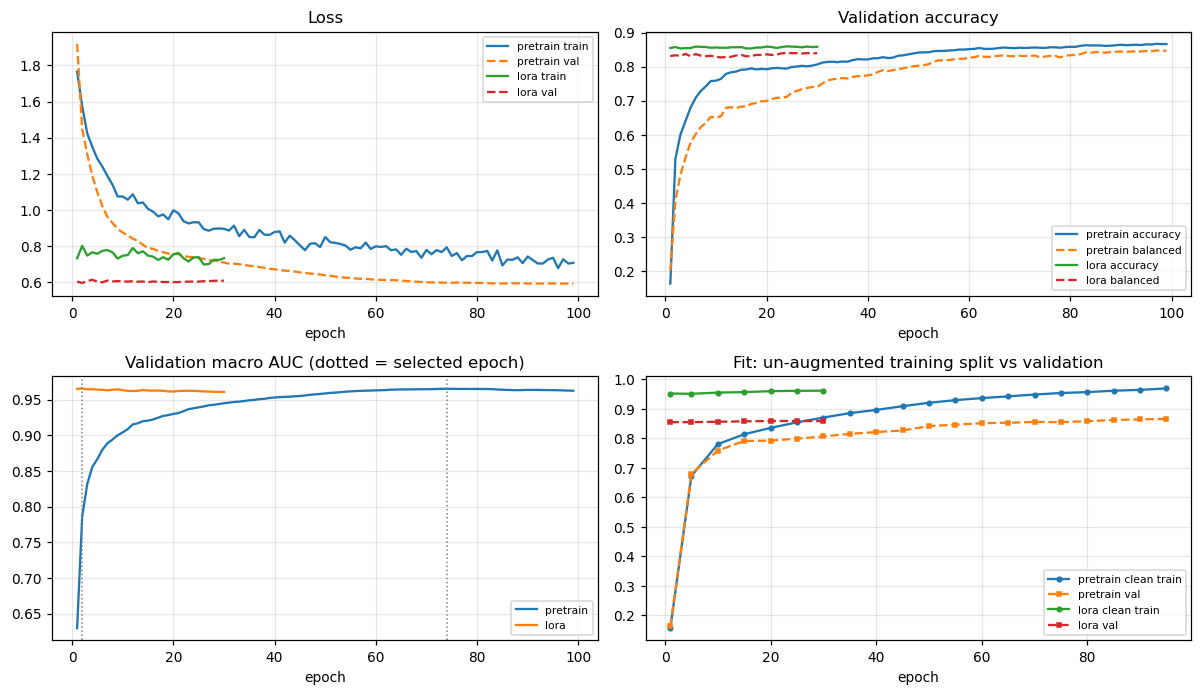

Generalisation gap = clean-train accuracy − validation accuracy.
POSITIVE AND WIDENING is memorisation. Negative or flat is not — the running
train_acc cannot show this: it is measured on the balanced split under MixUp.



,clean_train_acc,val_acc,generalisation_gap
epoch,,,
1,0.1566,0.1627,-0.0061
10,0.7802,0.7586,0.0217
20,0.8353,0.7922,0.0431
30,0.8704,0.8063,0.0641
40,0.8961,0.8211,0.0750
50,0.9202,0.8413,0.0789
60,0.9362,0.8514,0.0848
70,0.9483,0.8554,0.0929
80,0.9565,0.8581,0.0984


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))
for h in histories:
    e, lbl = pd.DataFrame(h["epochs"]), h["stage"]
    axes[0, 0].plot(e.epoch, e.train_loss, label=f"{lbl} train")
    axes[0, 0].plot(e.epoch, e.val_loss, "--", label=f"{lbl} val")
    axes[0, 1].plot(e.epoch, e.val_acc, label=f"{lbl} accuracy")
    axes[0, 1].plot(e.epoch, e.val_balanced_acc, "--", label=f"{lbl} balanced")
    axes[1, 0].plot(e.epoch, e.val_macro_auc, label=lbl)
    axes[1, 0].axvline(h["best_epoch"], color="grey", ls=":", lw=1)
    g = e.dropna(subset=["generalisation_gap"])
    if len(g):
        axes[1, 1].plot(g.epoch, g.clean_train_acc, "o-", ms=3, label=f"{lbl} clean train")
        axes[1, 1].plot(g.epoch, g.val_acc, "s--", ms=3, label=f"{lbl} val")
axes[0, 0].set(title="Loss", xlabel="epoch")
axes[0, 1].set(title="Validation accuracy", xlabel="epoch")
axes[1, 0].set(title="Validation macro AUC (dotted = selected epoch)", xlabel="epoch")
axes[1, 1].set(title="Fit: un-augmented training split vs validation", xlabel="epoch")
for a in axes.ravel(): a.legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUT_DIR / "figures" / "training_curves.png",
                                bbox_inches="tight"); plt.show()

pre = pd.DataFrame(histories[0]["epochs"]).dropna(subset=["generalisation_gap"])
if len(pre):
    print("Generalisation gap = clean-train accuracy − validation accuracy.")
    print("POSITIVE AND WIDENING is memorisation. Negative or flat is not — the running")
    print("train_acc cannot show this: it is measured on the balanced split under MixUp.\n")
    display(pre[["epoch", "clean_train_acc", "val_acc", "generalisation_gap"]]
            .iloc[::max(1, len(pre)//8)].round(4).set_index("epoch"))

## 9 · Evaluation

In [28]:
# Prediction and metrics
@dataclass
class Predictions:
    record_ids: List[str]
    y_true: np.ndarray          # (N,)
    y_pred: np.ndarray          # (N,)
    probs: np.ndarray           # (N, K)
    embeddings: Optional[np.ndarray] = None   # (N, D) CLS descriptors, for t-SNE
    inference_ms_per_sample: float = 0.0


@torch.no_grad()
def predict(
    model,
    loader,
    device,
    record_ids: Optional[Sequence[str]] = None,
    return_embeddings: bool = True,
) -> Predictions:
    model.eval().to(device)
    ys, ps, probs, embs, idxs = [], [], [], [], []
    total_s, n = 0.0, 0

    for batch in loader:
        x = batch[0].to(device, non_blocking=True)
        y = batch[1]
        idx = batch[2] if len(batch) > 2 else None

        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        feats = model.forward_features(x)
        logits = model.head(feats)
        if device.type == "cuda":
            torch.cuda.synchronize()
        total_s += time.perf_counter() - t0
        n += x.size(0)

        p = torch.softmax(logits.float(), dim=1)
        probs.append(p.cpu().numpy())
        ps.append(p.argmax(1).cpu().numpy())
        ys.append(y.numpy())
        if return_embeddings:
            embs.append(feats.float().cpu().numpy())
        if idx is not None:
            idxs.append(idx.numpy())

    y_true = np.concatenate(ys)
    order_ids: List[str]
    if record_ids is not None and idxs:
        flat = np.concatenate(idxs)
        order_ids = [str(record_ids[i]) for i in flat]
    elif record_ids is not None:
        order_ids = [str(r) for r in record_ids][: len(y_true)]
    else:
        order_ids = [str(i) for i in range(len(y_true))]

    return Predictions(
        record_ids=order_ids,
        y_true=y_true,
        y_pred=np.concatenate(ps),
        probs=np.concatenate(probs),
        embeddings=np.concatenate(embs) if embs else None,
        inference_ms_per_sample=1000.0 * total_s / max(n, 1),
    )


def compute_metrics(
    pred: Predictions,
    class_names=None,
    support_detail: Optional[Dict[str, Dict[str, float]]] = None,
) -> dict:
    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        confusion_matrix,
        f1_score,
        precision_recall_fscore_support,
        roc_auc_score,
    )

    K = len(class_names)
    labels = list(range(K))
    y, p = pred.y_true, pred.y_pred

    prec, rec, f1, sup = precision_recall_fscore_support(
        y, p, labels=labels, zero_division=0
    )
    cm = confusion_matrix(y, p, labels=labels)

    per_class: Dict[str, Dict[str, float]] = {}
    for i, name in enumerate(class_names):
        # Per-class accuracy in the manuscript's Table 3 sense: recall on that class.
        support_i = int(sup[i])
        per_class[name] = {
            "precision": float(prec[i]),
            "recall": float(rec[i]),
            "f1": float(f1[i]),
            "support": support_i,
            "accuracy": float(rec[i]),
        }
        if support_detail and name in support_detail:
            per_class[name].update(support_detail[name])

    # One-vs-rest AUC, skipping degenerate classes rather than reporting a fake 0.5.
    auc: Dict[str, Optional[float]] = {}
    for i, name in enumerate(class_names):
        yi = (y == i).astype(int)
        if yi.sum() == 0 or yi.sum() == len(yi):
            auc[name] = None
        else:
            auc[name] = float(roc_auc_score(yi, pred.probs[:, i]))
    scored = [v for v in auc.values() if v is not None]

    return {
        "class_names": list(class_names),
        "n_samples": int(len(y)),
        "overall_accuracy": float(accuracy_score(y, p)),
        "balanced_accuracy": float(balanced_accuracy_score(y, p)),
        "macro_f1": float(f1_score(y, p, average="macro", labels=labels, zero_division=0)),
        "weighted_f1": float(f1_score(y, p, average="weighted", labels=labels, zero_division=0)),
        "macro_precision": float(np.mean(prec)),
        "macro_recall": float(np.mean(rec)),
        "macro_auc": float(np.mean(scored)) if scored else None,
        "per_class": per_class,
        "per_class_auc": auc,
        "confusion_matrix": cm.tolist(),
        "inference_ms_per_sample": round(pred.inference_ms_per_sample, 4),
        "classes_absent_from_split": [
            class_names[i] for i in range(K) if int(sup[i]) == 0
        ],
    }


def plot_confusion_matrix(cm, class_names, path: Path, title: str) -> None:
    # NOTE: the package calls matplotlib.use("Agg") here, which is right for the
    # headless CLI and wrong in a notebook -- it switches the backend for the whole
    # kernel, so every later figure would save to disk and never appear inline.

    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="viridis")
    ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names)), class_names)
    thresh = cm.max() / 2.0 if cm.max() else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] < thresh else "black", fontsize=9,
            )
    ax.set_xlabel("Predicted label", fontweight="bold")
    ax.set_ylabel("True label", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300)
    plt.close(fig)


def plot_precision_recall(pred: Predictions, class_names, path: Path) -> Dict[str, float]:
    # NOTE: the package calls matplotlib.use("Agg") here, which is right for the
    # headless CLI and wrong in a notebook -- it switches the backend for the whole
    # kernel, so every later figure would save to disk and never appear inline.
    from sklearn.metrics import average_precision_score, precision_recall_curve

    fig, ax = plt.subplots(figsize=(7, 6))
    aps: Dict[str, float] = {}
    for i, name in enumerate(class_names):
        yi = (pred.y_true == i).astype(int)
        if yi.sum() == 0:
            continue
        p, r, _ = precision_recall_curve(yi, pred.probs[:, i])
        ap = float(average_precision_score(yi, pred.probs[:, i]))
        aps[name] = ap
        ax.step(r, p, where="post", label=f"{name} (AP={ap:.3f})")
    ax.set_xlabel("Recall", fontweight="bold")
    ax.set_ylabel("Precision", fontweight="bold")
    ax.set_title("Precision-Recall (one-vs-rest)", fontweight="bold")
    ax.legend(fontsize="small", loc="lower left")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300)
    plt.close(fig)
    return aps

In [29]:
def load_model(with_lora=True):
    m = LoRAViT(cfg_model)
    if with_lora:
        inject_lora(m, cfg_lora)
        if cfg_lora.freeze_backbone: freeze_backbone(m, cfg_lora)
    path = lora_ckpt if with_lora else base_ckpt
    m.load_state_dict(torch.load(path, map_location="cpu")["state_dict"], strict=True)
    return m.to(device).eval()

model = load_model(True)
test_ids = [r.record_id for r in by_split["test"]]
pred = predict(model, loaders["test"], device, record_ids=test_ids)
metrics = compute_metrics(pred, CLASSES)
CM = np.array(metrics["confusion_matrix"], dtype=float)
row, col, n = CM.sum(1), CM.sum(0), CM.sum()
kappa = (np.trace(CM)/n - (row*col).sum()/n**2) / (1 - (row*col).sum()/n**2)
mcc_num = np.trace(CM)*n - (row*col).sum()
mcc = mcc_num / np.sqrt((n**2 - (col**2).sum()) * (n**2 - (row**2).sum()))

display(pd.Series({
    "test records": int(metrics["n_samples"]),
    "accuracy": round(metrics["overall_accuracy"], 4),
    "balanced accuracy": round(metrics["balanced_accuracy"], 4),
    "macro F1": round(metrics["macro_f1"], 4),
    "weighted F1": round(metrics["weighted_f1"], 4),
    "macro precision": round(metrics["macro_precision"], 4),
    "macro recall": round(metrics["macro_recall"], 4),
    "macro AUC": round(metrics["macro_auc"], 4),
    "Cohen kappa": round(kappa, 4),
    "Matthews CC": round(mcc, 4),
    "inference ms/sample": round(metrics["inference_ms_per_sample"], 3),
}, name="value").to_frame())

,value
test records,1532.0000
accuracy,0.8499
balanced accuracy,0.8166
macro F1,0.7874
weighted F1,0.8511
macro precision,0.7727
macro recall,0.8166
macro AUC,0.9567
Cohen kappa,0.8115
Matthews CC,0.8120


In [30]:
from sklearn.metrics import classification_report

print(classification_report(pred.y_true, pred.y_pred, labels=range(len(CLASSES)),
                            target_names=CLASSES, digits=4, zero_division=0))

def wilson(k, n, z=1.96):
    if n <= 0: return (0.0, 1.0)
    p = k / n; d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d
    h = z * math.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return max(0.0, c-h), min(1.0, c+h)

MIN_TEST = 50   # below this a per-class recall CI is wider than +/-15 points
rows = []
for i, c in enumerate(CLASSES):
    d = metrics["per_class"][c]; s = int(d["support"])
    lo, hi = wilson(CM[i, i], s)
    rows.append({"n": s, "recall": round(d["recall"], 4),
                 "recall 95% CI": f"[{lo:.3f}, {hi:.3f}]" if s else "-",
                 "precision": round(d["precision"], 4), "F1": round(d["f1"], 4),
                 "AUC": None if metrics["per_class_auc"].get(c) is None
                        else round(metrics["per_class_auc"][c], 4),
                 "reportable": ("absent from test" if s == 0 else
                                "yes" if s >= MIN_TEST else f"NO (< {MIN_TEST})")})
display(pd.DataFrame(rows, index=CLASSES))
weak = [c for c in CLASSES if 0 < metrics["per_class"][c]["support"] < MIN_TEST]
if weak:
    print(f"{', '.join(weak)}: too few unique test records for a point estimate. Report the")
    print("interval or nothing — augmenting the training split cannot widen a test class.")

              precision    recall  f1-score   support

         NSR     0.8404    0.8943    0.8665       265
        AFIB     0.8333    0.8590    0.8460       227
          SB     0.9503    0.8985    0.9237       532
          ST     0.9217    0.9174    0.9195       218
         SVT     0.7634    0.7978    0.7802        89
          CD     0.6531    0.5680    0.6076       169
          VE     0.4464    0.7812    0.5682        32

    accuracy                         0.8499      1532
   macro avg     0.7727    0.8166    0.7874      1532
weighted avg     0.8557    0.8499    0.8511      1532



,n,recall,recall 95% CI,precision,F1,AUC,reportable
NSR,265,0.8943,"[0.852, 0.926]",0.8404,0.8665,0.9852,yes
AFIB,227,0.8590,"[0.808, 0.898]",0.8333,0.8460,0.9813,yes
SB,532,0.8985,"[0.870, 0.921]",0.9503,0.9237,0.9910,yes
ST,218,0.9174,"[0.873, 0.947]",0.9217,0.9195,0.9891,yes
SVT,89,0.7978,"[0.703, 0.868]",0.7634,0.7802,0.9759,yes
CD,169,0.5680,"[0.493, 0.640]",0.6531,0.6076,0.9007,yes
VE,32,0.7812,"[0.612, 0.890]",0.4464,0.5682,0.8736,NO (< 50)


VE: too few unique test records for a point estimate. Report the
interval or nothing — augmenting the training split cannot widen a test class.


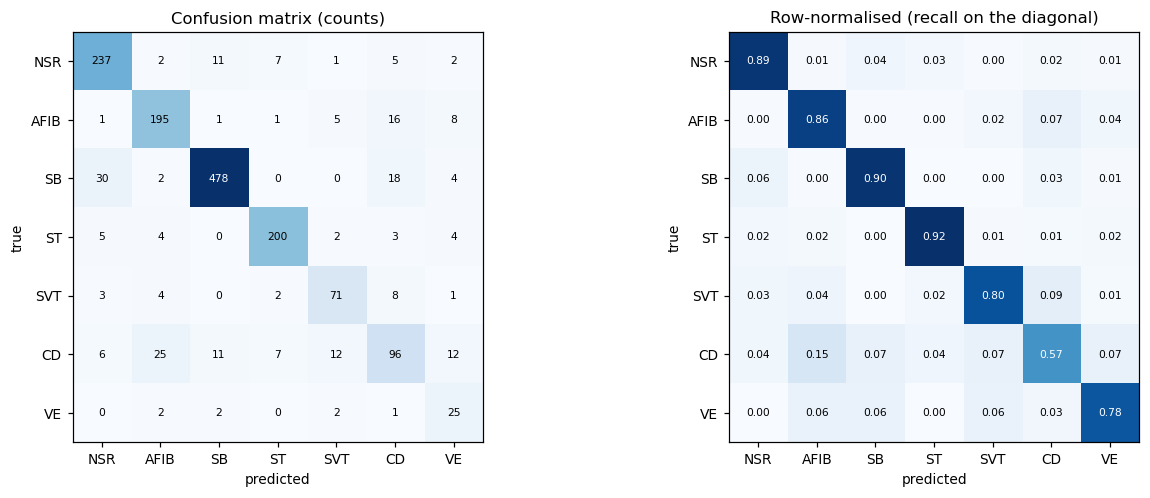

Largest confusions:
     SB -> NSR     30   (6% of SB)
     CD -> AFIB    25   (15% of CD)
     SB -> CD      18   (3% of SB)
   AFIB -> CD      16   (7% of AFIB)
     CD -> VE      12   (7% of CD)
     CD -> SVT     12   (7% of CD)


In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
for k, (M, ttl, fmt) in enumerate([(CM, "Confusion matrix (counts)", "{:.0f}"),
                                   (CM / row[:, None], "Row-normalised (recall on the diagonal)",
                                    "{:.2f}")]):
    ax[k].imshow(M, cmap="Blues")
    ax[k].set(xticks=range(len(CLASSES)), yticks=range(len(CLASSES)),
              xticklabels=CLASSES, yticklabels=CLASSES,
              xlabel="predicted", ylabel="true", title=ttl)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax[k].text(j, i, fmt.format(M[i, j]), ha="center", va="center", fontsize=7,
                       color="white" if M[i, j] > M.max()*.55 else "black")
    ax[k].grid(False)
plt.tight_layout(); plt.savefig(OUT_DIR / "figures" / "confusion_matrix.png",
                                bbox_inches="tight"); plt.show()

print("Largest confusions:")
for v, a, b in sorted(((int(CM[i, j]), CLASSES[i], CLASSES[j])
                       for i in range(len(CLASSES)) for j in range(len(CLASSES)) if i != j),
                      reverse=True)[:6]:
    print(f"  {a:>5} -> {b:<5} {v:>4}   ({100*v/row[CLASSES.index(a)]:.0f}% of {a})")

,average precision
NSR,0.9536
AFIB,0.9266
SB,0.9822
ST,0.9704
SVT,0.8669
CD,0.7097
VE,0.5586


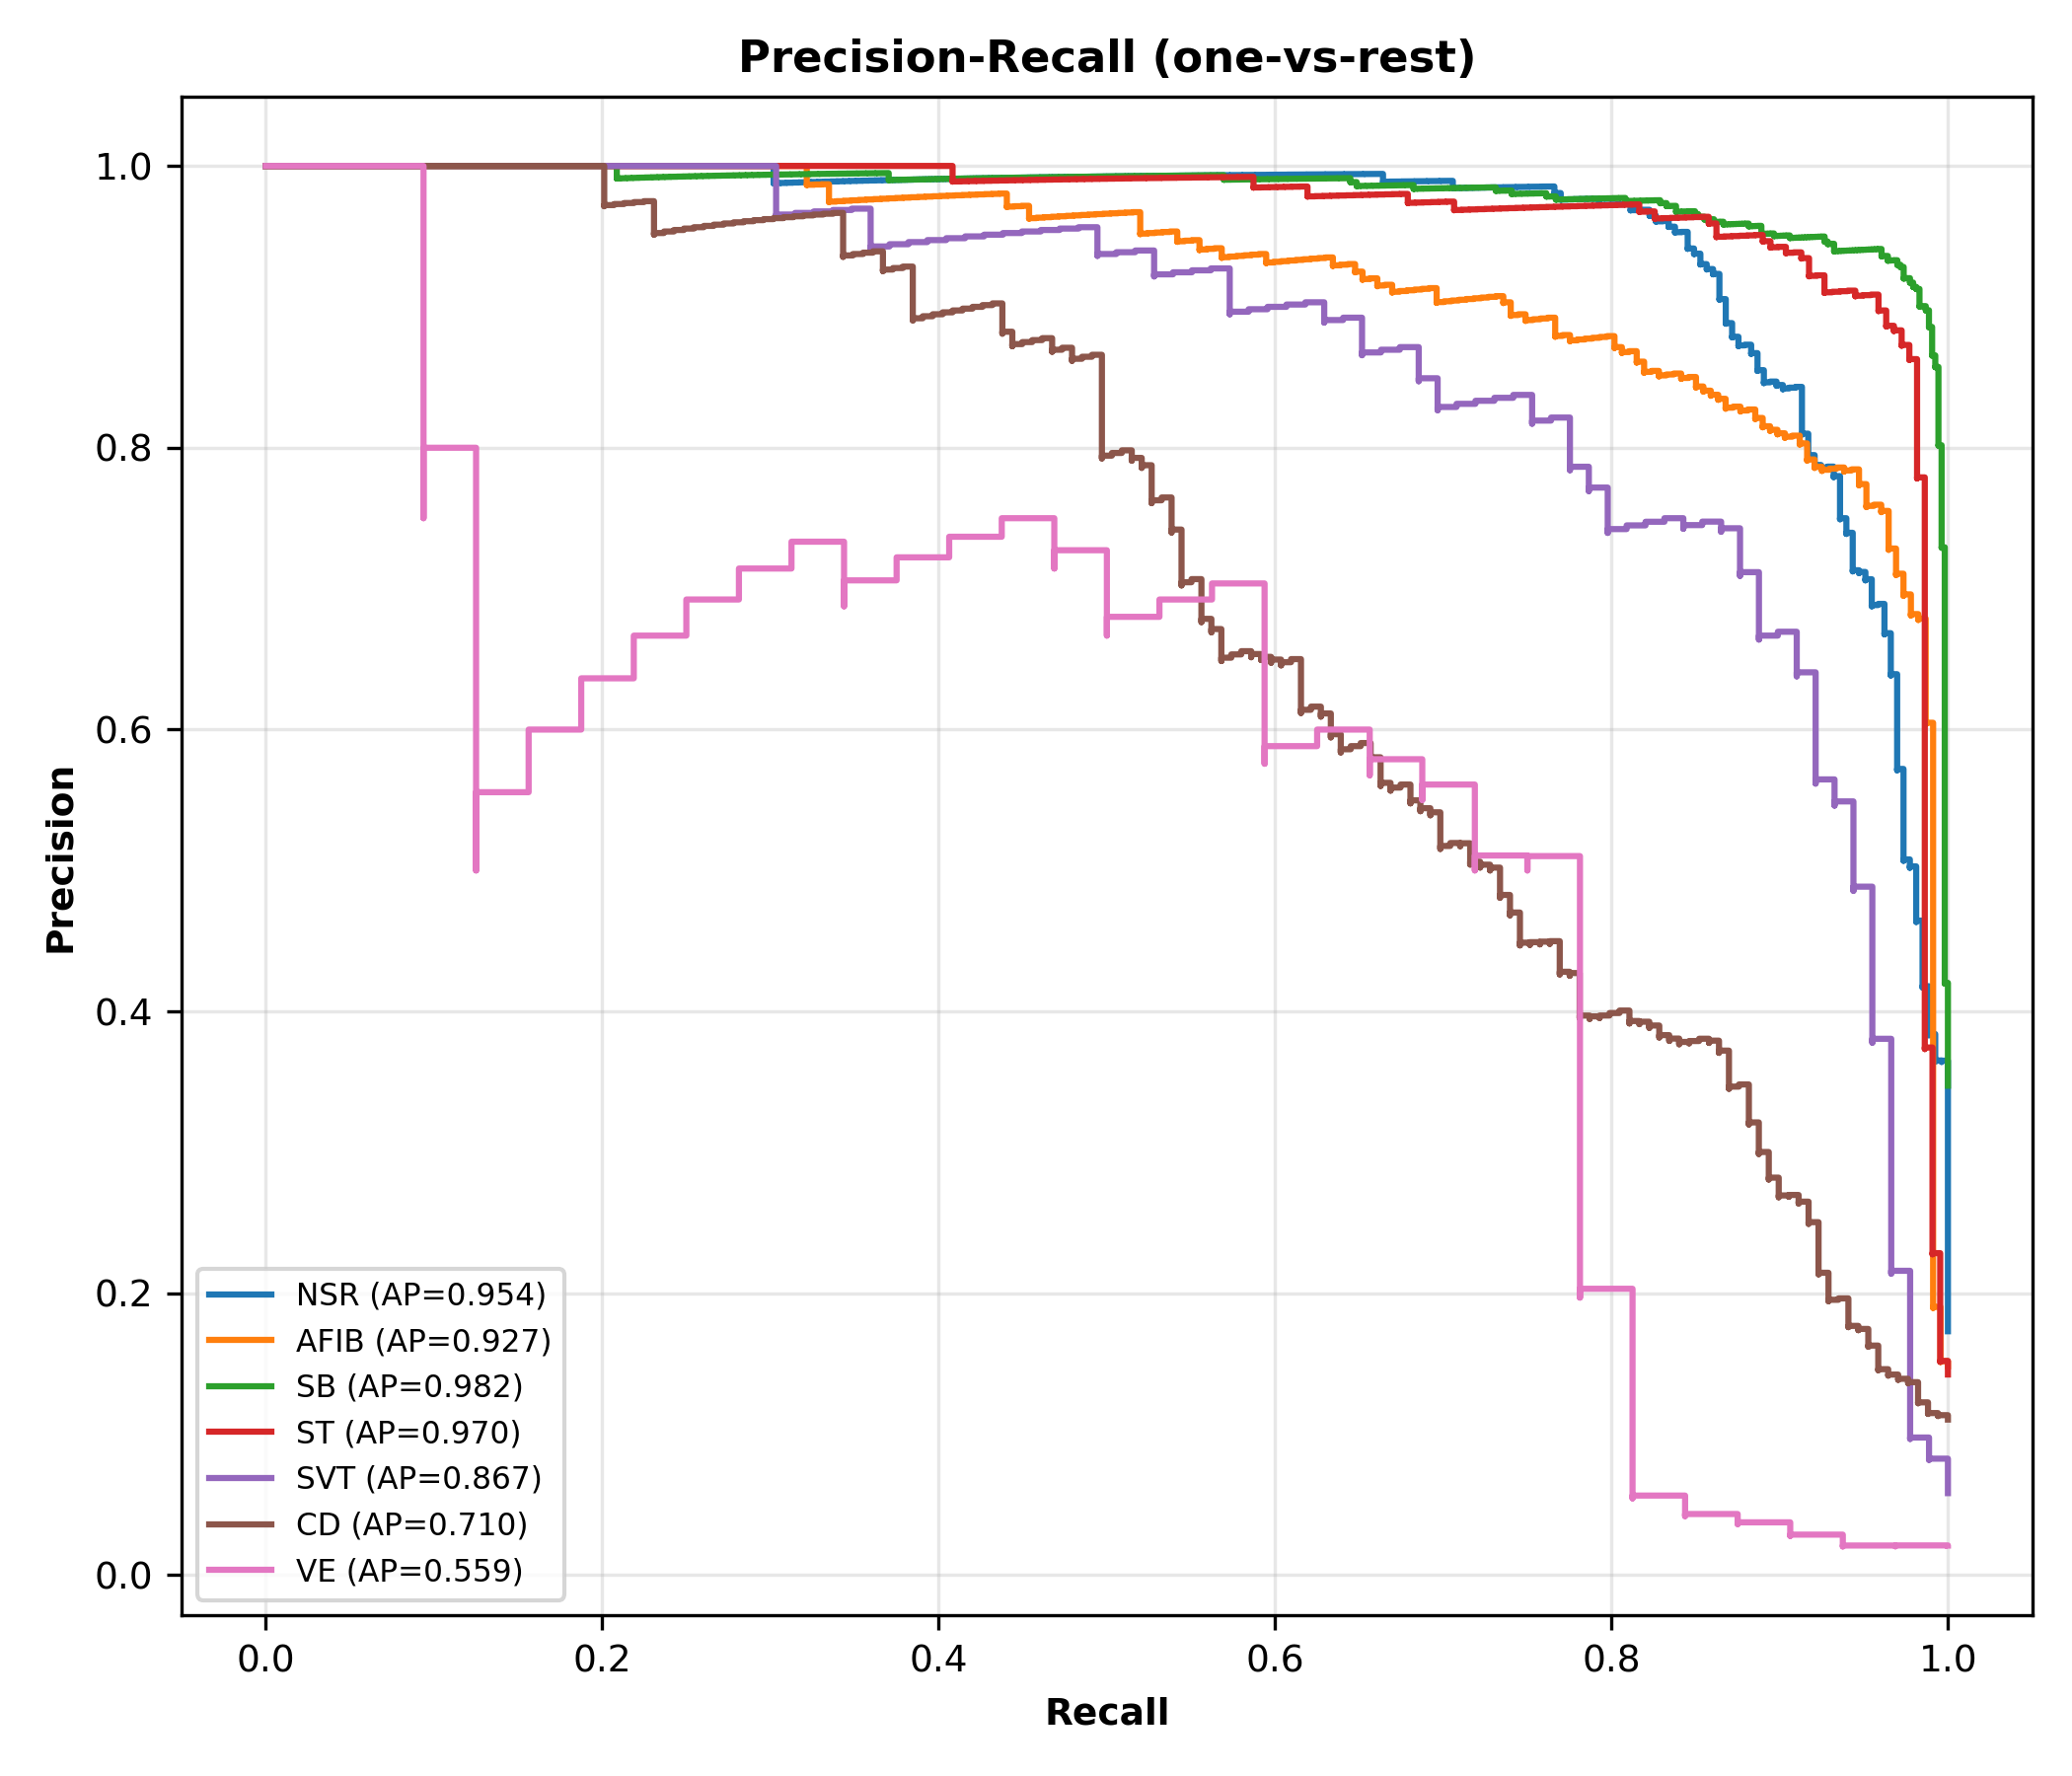

In [32]:
aps = plot_precision_recall(pred, CLASSES, OUT_DIR / "figures" / "precision_recall.png")
display(pd.Series(aps, name="average precision").round(4).to_frame())

from PIL import Image
display(Image.open(OUT_DIR / "figures" / "precision_recall.png"))

C:\Users\shahb\anaconda3\Lib\site-packages\torch\optim\lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  loss = float(closure())


,value
temperature,0.724303
val_nll_before,0.594201
val_nll_after,0.543078
val_ece_before,0.129944
val_ece_after,0.051273
val_accuracy_unchanged,0.857431


T > 1 softens an over-confident model; T < 1 sharpens an under-confident one.


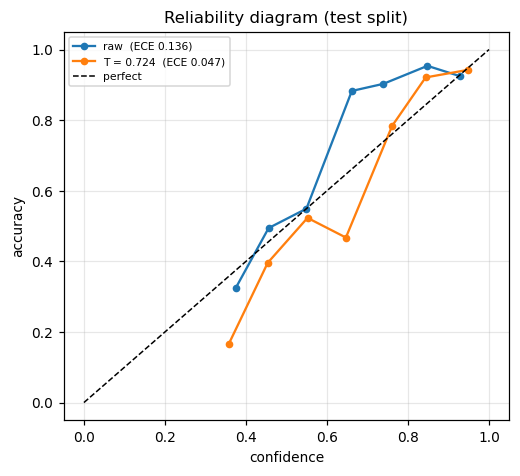

In [33]:
# Calibration. Dividing logits by one positive scalar is monotone, so it CANNOT change the
# argmax: accuracy, the confusion matrix and every AUC are unchanged by construction.
calib = fit_temperature(model, loaders["val"], device)
(OUT_DIR / "calibration.json").write_text(json.dumps(calib, indent=2))
display(pd.Series({k: calib[k] for k in ("temperature", "val_nll_before", "val_nll_after",
                                         "val_ece_before", "val_ece_after",
                                         "val_accuracy_unchanged")}, name="value").to_frame())
print("T > 1 softens an over-confident model; T < 1 sharpens an under-confident one.")

T = calib["temperature"]
p_cal = np.exp(np.log(np.clip(pred.probs, 1e-12, None)) / T)
p_cal /= p_cal.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(4.8, 4.4))
for p, lbl in ((pred.probs, f"raw  (ECE {expected_calibration_error(pred.probs, pred.y_true):.3f})"),
               (p_cal, f"T = {T:.3f}  (ECE {expected_calibration_error(p_cal, pred.y_true):.3f})")):
    conf, hit = p.max(1), (p.argmax(1) == pred.y_true)
    edges = np.linspace(0, 1, 11); xs, ys = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 5: xs.append(conf[m].mean()); ys.append(hit[m].mean())
    ax.plot(xs, ys, "o-", ms=4, label=lbl)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
ax.set(xlabel="confidence", ylabel="accuracy", title="Reliability diagram (test split)")
ax.legend(fontsize=7); plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "calibration.png", bbox_inches="tight"); plt.show()

## 10 · Explainability (§4.2–4.3)

Grad-CAM over the last block's pre-norm activations; Integrated Gradients with bootstrap
95% CIs per class × lead (eq. 19); Gradient SHAP for the global lead ranking;
insertion/deletion faithfulness; t-SNE of the CLS embeddings; and concordance against
AHA/ACC and ESC lead-sensitivity criteria.

In [34]:
# Explainability
class ViTGradCAM:
    """Grad-CAM over transformer tokens.

    Hooks the pre-norm LayerNorm of the last encoder block, which carries (B, 1+N, D)
    token activations. Channel weights are the token-averaged gradients; the CAM is the
    weighted channel sum, ReLU'd, CLS token dropped, min-max normalised to [0, 1].

    The hook handles are released by `close()` / the context manager. Registering hooks and
    never removing them leaks activations across calls and silently corrupts a long XAI
    sweep -- a real failure mode in the notebook version of this code.
    """

    def __init__(self, model, target_layer=None) -> None:
        self.model = model
        self.layer = target_layer if target_layer is not None else model.blocks[-1].norm1
        self.activations: Optional[torch.Tensor] = None
        self.gradients: Optional[torch.Tensor] = None
        self._handles = [
            self.layer.register_forward_hook(self._save_activation),
            self.layer.register_full_backward_hook(self._save_gradient),
        ]

    def _save_activation(self, module, inp, out) -> None:
        self.activations = out

    def _save_gradient(self, module, grad_in, grad_out) -> None:
        self.gradients = grad_out[0]

    def close(self) -> None:
        for h in self._handles:
            h.remove()
        self._handles = []

    def __enter__(self) -> "ViTGradCAM":
        return self

    def __exit__(self, *exc) -> None:
        self.close()

    def __call__(
        self, x: torch.Tensor, class_idx: Optional[int] = None
    ) -> Tuple[np.ndarray, int, np.ndarray]:
        """Returns (cam over N patches in [0,1], predicted class, softmax probabilities)."""
        if x.shape[0] != 1:
            raise ValueError("ViTGradCAM operates on one record at a time")
        was_training = self.model.training
        self.model.eval()

        x = x.detach().requires_grad_(True)
        logits = self.model(x)
        target = int(logits.argmax(1).item()) if class_idx is None else int(class_idx)

        self.model.zero_grad(set_to_none=True)
        logits[0, target].backward()

        if self.activations is None or self.gradients is None:
            raise RuntimeError("Grad-CAM hooks did not fire; check the target layer")

        weights = self.gradients.mean(dim=1, keepdim=True)          # (1, 1, D)
        cam = (weights * self.activations).sum(dim=2)               # (1, 1+N)
        cam = F.relu(cam)
        if self.model.cls_token is not None:
            cam = cam[:, 1:]                                        # drop CLS
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        probs = torch.softmax(logits.detach().float(), dim=1)[0].cpu().numpy()
        if was_training:
            self.model.train()
        return cam.detach().cpu().numpy()[0], target, probs


def upsample_cam(cam: np.ndarray, patch_len: int, n_samples: int = N_SAMPLES) -> np.ndarray:
    """Patch-level CAM -> per-sample envelope."""
    out = np.repeat(np.asarray(cam, dtype=np.float32), patch_len)
    if out.size < n_samples:
        out = np.pad(out, (0, n_samples - out.size), mode="edge")
    return out[:n_samples]


def plot_gradcam_12lead(
    signal: np.ndarray,
    cam_samples: np.ndarray,
    path: Path,
    title: str,
    fs: float = 500.0,
) -> None:
    """Figure 3 style: 12 stacked lead panels with the CAM envelope shaded."""
    # NOTE: the package calls matplotlib.use("Agg") here, which is right for the
    # headless CLI and wrong in a notebook -- it switches the backend for the whole
    # kernel, so every later figure would save to disk and never appear inline.

    t = np.arange(signal.shape[-1]) / fs
    fig, axes = plt.subplots(N_LEADS, 1, figsize=(11, 13), sharex=True)
    for i, ax in enumerate(axes):
        s = signal[i]
        lo, hi = float(s.min()), float(s.max())
        ax.fill_between(t, lo, lo + cam_samples * (hi - lo), color="red", alpha=0.35, lw=0)
        ax.plot(t, s, color="black", lw=0.6)
        ax.set_ylabel(LEAD_ORDER[i], rotation=0, labelpad=22, fontsize=9, va="center")
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.15)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontweight="bold", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.98))
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=200)
    plt.close(fig)


def _require_captum():
    try:
        from captum.attr import GradientShap, IntegratedGradients  # noqa: F401
    except ImportError as exc:  # pragma: no cover
        raise ImportError(
            "captum is required for the attribution layer: pip install captum==0.8.0"
        ) from exc


def integrated_gradients(
    model, x: torch.Tensor, target: int, n_steps: int = 50, baseline: Optional[torch.Tensor] = None
) -> np.ndarray:
    """IG attribution map A in R^{12 x T} for one record against a zero baseline."""
    _require_captum()
    from captum.attr import IntegratedGradients

    model.eval()
    ig = IntegratedGradients(model)
    base = torch.zeros_like(x) if baseline is None else baseline
    attr = ig.attribute(x.requires_grad_(True), baselines=base, target=target, n_steps=n_steps)
    return attr.detach().squeeze(0).float().cpu().numpy()


def gradient_shap(
    model,
    x: torch.Tensor,
    target: int,
    background: torch.Tensor,
    n_samples: int = 128,
) -> np.ndarray:
    """Gradient SHAP attribution against a background distribution of real records."""
    _require_captum()
    from captum.attr import GradientShap

    model.eval()
    gs = GradientShap(model)
    attr = gs.attribute(
        x.requires_grad_(True),
        baselines=background,
        target=target,
        n_samples=n_samples,
        stdevs=0.09,
    )
    return attr.detach().squeeze(0).float().cpu().numpy()


@dataclass
class LeadImportance:
    """Equation (19): I_c(l) = (1/M) sum_m (1/T) sum_t |A_c^(m)(l, t)|."""

    method: str
    class_names: List[str]
    lead_names: List[str]
    mean: np.ndarray          # (K, 12)
    ci_low: np.ndarray        # (K, 12)
    ci_high: np.ndarray       # (K, 12)
    n_samples: Dict[str, int]

    def to_rows(self) -> List[Dict[str, object]]:
        rows = []
        for ci, cname in enumerate(self.class_names):
            order = np.argsort(-self.mean[ci])
            rank = {int(l): r + 1 for r, l in enumerate(order)}
            for li, lname in enumerate(self.lead_names):
                rows.append(
                    {
                        "method": self.method,
                        "class": cname,
                        "lead": lname,
                        "lead_index": li,
                        "mean_abs_attribution": float(self.mean[ci, li]),
                        "ci95_low": float(self.ci_low[ci, li]),
                        "ci95_high": float(self.ci_high[ci, li]),
                        "rank_within_class": rank[li],
                        "n_records": self.n_samples.get(cname, 0),
                    }
                )
        return rows

    def top_k(self, k: int = 3) -> Dict[str, List[str]]:
        return {
            c: [self.lead_names[i] for i in np.argsort(-self.mean[ci])[:k]]
            for ci, c in enumerate(self.class_names)
        }


def per_class_lead_importance(
    attributions: Dict[int, List[np.ndarray]],
    method: str,
    class_names=None,
    confidence: float = 0.95,
    n_bootstrap: int = 1000,
    seed: int = 42,
) -> LeadImportance:
    """Aggregate per-record (12, T) maps into per-class lead importance with a bootstrap CI."""
    rng = np.random.default_rng(seed)
    K, L = len(class_names), N_LEADS
    mean = np.zeros((K, L))
    lo = np.zeros((K, L))
    hi = np.zeros((K, L))
    counts: Dict[str, int] = {}

    alpha = (1.0 - confidence) / 2.0
    for ci, cname in enumerate(class_names):
        maps = attributions.get(ci, [])
        counts[cname] = len(maps)
        if not maps:
            continue
        # (M, 12): mean |attribution| over time, per record
        per_record = np.stack([np.abs(m).mean(axis=-1) for m in maps], axis=0)
        mean[ci] = per_record.mean(axis=0)
        if per_record.shape[0] < 2:
            lo[ci] = hi[ci] = mean[ci]
            continue
        idx = rng.integers(0, per_record.shape[0], size=(n_bootstrap, per_record.shape[0]))
        boots = per_record[idx].mean(axis=1)          # (n_bootstrap, 12)
        lo[ci] = np.quantile(boots, alpha, axis=0)
        hi[ci] = np.quantile(boots, 1.0 - alpha, axis=0)

    return LeadImportance(
        method=method,
        class_names=list(class_names),
        lead_names=list(LEAD_ORDER),
        mean=mean, ci_low=lo, ci_high=hi, n_samples=counts,
    )


def plot_lead_importance(imp: LeadImportance, path: Path, title: str) -> None:
    # NOTE: the package calls matplotlib.use("Agg") here, which is right for the
    # headless CLI and wrong in a notebook -- it switches the backend for the whole
    # kernel, so every later figure would save to disk and never appear inline.

    K, L = imp.mean.shape
    width = 0.8 / max(K, 1)
    xs = np.arange(L)
    fig, ax = plt.subplots(figsize=(13, 5))
    for ci, cname in enumerate(imp.class_names):
        if imp.n_samples.get(cname, 0) == 0:
            continue
        off = (ci - (K - 1) / 2) * width
        err = np.vstack(
            [
                np.maximum(imp.mean[ci] - imp.ci_low[ci], 0),
                np.maximum(imp.ci_high[ci] - imp.mean[ci], 0),
            ]
        )
        ax.bar(xs + off, imp.mean[ci], width=width, label=cname, yerr=err,
               capsize=2, error_kw={"lw": 0.7})
    ax.set_xticks(xs, imp.lead_names)
    ax.set_xlabel("ECG lead", fontweight="bold")
    ax.set_ylabel(f"Mean |{imp.method}| attribution", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.legend(ncol=4, fontsize="small")
    ax.grid(alpha=0.25, axis="y")
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300)
    plt.close(fig)


def plot_global_lead_importance(imp: LeadImportance, path: Path) -> Dict[str, float]:
    """Figure 8: SHAP-based global lead importance, averaged over classes."""
    # NOTE: the package calls matplotlib.use("Agg") here, which is right for the
    # headless CLI and wrong in a notebook -- it switches the backend for the whole
    # kernel, so every later figure would save to disk and never appear inline.

    present = [i for i, c in enumerate(imp.class_names) if imp.n_samples.get(c, 0) > 0]
    global_mean = imp.mean[present].mean(axis=0) if present else imp.mean.mean(axis=0)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(imp.lead_names, global_mean, color="#3B76AF", edgecolor="black", lw=0.5)
    ax.set_xlabel("ECG lead", fontweight="bold")
    ax.set_ylabel(f"Mean |{imp.method}| contribution", fontweight="bold")
    ax.set_title(f"Global lead importance ({imp.method})", fontweight="bold")
    ax.grid(alpha=0.25, axis="y")
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300)
    plt.close(fig)
    return {n: float(v) for n, v in zip(imp.lead_names, global_mean)}


@torch.no_grad()
def _accuracy(model, X: torch.Tensor, y: torch.Tensor, batch: int = 64) -> float:
    model.eval()
    correct = 0
    for i in range(0, X.shape[0], batch):
        out = model(X[i : i + batch])
        correct += (out.argmax(1) == y[i : i + batch]).sum().item()
    return correct / max(X.shape[0], 1)


def insertion_deletion(
    model,
    X: torch.Tensor,
    y: torch.Tensor,
    attributions: np.ndarray,
    fractions: Sequence[float] = (0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 1.00),
    patch_len: int = 100,
) -> Dict[str, object]:
    """Faithfulness curves over attribution-ranked temporal patches.

    Deletion: progressively zero the HIGHEST-attributed patches; accuracy must fall fast.
    Insertion: start from an all-zero record and progressively restore the highest-attributed
    patches; accuracy must rise fast.

    Ranking is done per record over (lead, patch) cells, then aggregated to patches by max,
    so a patch important in any single lead counts. Reported as AUC over the fraction axis;
    `deletion_auc < insertion_auc` is the condition the tests assert.
    """
    device = next(model.parameters()).device
    X = X.to(device)
    y = y.to(device)
    B, C, T = X.shape
    n_patch = T // patch_len

    a = np.abs(np.asarray(attributions))                      # (B, C, T)
    a = a[..., : n_patch * patch_len].reshape(B, C, n_patch, patch_len)
    patch_score = a.mean(axis=-1).max(axis=1)                 # (B, n_patch)
    order = np.argsort(-patch_score, axis=1)                  # most important first

    ins_acc: List[float] = []
    del_acc: List[float] = []
    for frac in fractions:
        k = max(1, int(round(frac * n_patch)))
        keep = torch.zeros(B, n_patch, dtype=torch.bool, device=device)
        rows = torch.arange(B, device=device).unsqueeze(1)
        cols = torch.as_tensor(order[:, :k].copy(), device=device)
        keep[rows, cols] = True
        mask = keep.repeat_interleave(patch_len, dim=1)[:, :T].unsqueeze(1)  # (B,1,T)

        ins_acc.append(_accuracy(model, X * mask, y))
        del_acc.append(_accuracy(model, X * (~mask), y))

    fr = np.asarray(fractions, dtype=float)
    return {
        "fractions": fr.tolist(),
        "insertion_accuracy": ins_acc,
        "deletion_accuracy": del_acc,
        "insertion_auc": float(np.trapezoid(ins_acc, fr) / (fr[-1] - fr[0])),
        "deletion_auc": float(np.trapezoid(del_acc, fr) / (fr[-1] - fr[0])),
        "baseline_accuracy": _accuracy(model, X, y),
        "n_records": int(B),
        "n_patches": int(n_patch),
    }


def plot_faithfulness(res: Dict[str, object], path: Path) -> None:
    # NOTE: the package calls matplotlib.use("Agg") here, which is right for the
    # headless CLI and wrong in a notebook -- it switches the backend for the whole
    # kernel, so every later figure would save to disk and never appear inline.

    fr = np.asarray(res["fractions"]) * 100
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(fr, res["insertion_accuracy"], "o-")
    axes[0].set_title(
        f"Insertion (AUC={res['insertion_auc']:.3f})", fontweight="bold"
    )
    axes[0].set_xlabel("% highest-attribution patches inserted")
    axes[1].plot(fr, res["deletion_accuracy"], "o-", color="crimson")
    axes[1].set_title(
        f"Deletion (AUC={res['deletion_auc']:.3f})", fontweight="bold"
    )
    axes[1].set_xlabel("% highest-attribution patches removed")
    for a in axes:
        a.set_ylabel("Classification accuracy")
        a.axhline(res["baseline_accuracy"], ls="--", lw=0.8, color="grey",
                  label="full-signal accuracy")
        a.grid(alpha=0.3)
        a.legend(fontsize="small")
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300)
    plt.close(fig)


def tsne_embeddings(
    embeddings: np.ndarray,
    labels: np.ndarray,
    perplexity: float = 30.0,
    max_samples: int = 2000,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray]:
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

    rng = np.random.default_rng(seed)
    n = embeddings.shape[0]
    if n > max_samples:
        sel = rng.choice(n, size=max_samples, replace=False)
        embeddings, labels = embeddings[sel], labels[sel]
    X = StandardScaler().fit_transform(embeddings)
    perp = float(min(perplexity, max(5.0, (X.shape[0] - 1) / 3.0)))
    Z = TSNE(n_components=2, perplexity=perp, init="pca", random_state=seed).fit_transform(X)
    return Z, labels


def plot_tsne(Z: np.ndarray, labels: np.ndarray, path: Path, title: str,
              class_names=None) -> None:
    # NOTE: the package calls matplotlib.use("Agg") here, which is right for the
    # headless CLI and wrong in a notebook -- it switches the backend for the whole
    # kernel, so every later figure would save to disk and never appear inline.

    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    cmap = plt.get_cmap("tab10")
    for i, name in enumerate(class_names):
        m = labels == i
        if not m.any():
            continue
        ax.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.65, color=cmap(i % 10), label=name)
    ax.set_xlabel("t-SNE component 1")
    ax.set_ylabel("t-SNE component 2")
    ax.set_title(title, fontweight="bold")
    ax.legend(markerscale=2.5, fontsize="small", title="Class")
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300)
    plt.close(fig)


CLINICALLY_EXPECTED_LEADS: Dict[str, List[str]] = {
    "AFIB": ["II", "V1"],
    "CD": ["V1", "V2"],
    "SB": ["II", "aVF"],
    "ST": ["V3", "V4", "V5"],
    "SVT": ["II", "V1"],
    "NSR": ["II", "aVF"],
    "OTHER": ["V1", "II"],
}


CLINICAL_CRITERIA: Dict[str, str] = {
    "AFIB": "Absent or disorganised P waves, irregularly irregular RR intervals (ESC 2020).",
    "CD": "QRS > 120 ms, RSR' in V1-V3 (RBBB) or broad slurred R in I/aVL (LBBB) "
          "(AHA/ACCF/HRS Part IV).",
    "SB": "Regular P waves with normal axis, rate < 60 bpm, prolonged RR (ACC/AHA/HRS 2018).",
    "ST": "ST elevation >= 1 mm in two contiguous leads, or T inversion / depression in "
          "precordial leads (Fourth Universal Definition of MI).",
    "SVT": "Narrow-QRS tachycardia > 100 bpm, retrograde or absent P waves, regular RR "
           "(ACC/AHA/HRS 2015).",
    "NSR": "Regular P-QRS-T, PR 120-200 ms, QRS < 120 ms, rate 60-100 bpm (AHA/ACCF/HRS).",
    "OTHER": "Mixed morphology not meeting criteria for the primary classes.",
}


def clinical_concordance(imp: LeadImportance, k: int = 3) -> List[Dict[str, object]]:
    top = imp.top_k(k)
    rows = []
    for cname in imp.class_names:
        model_leads = top.get(cname, [])
        expected = CLINICALLY_EXPECTED_LEADS.get(cname, [])
        overlap = [l for l in model_leads if l in expected]
        rows.append(
            {
                "class": cname,
                "n_records": imp.n_samples.get(cname, 0),
                "model_top_leads": model_leads,
                "clinically_expected_leads": expected,
                "overlap": overlap,
                "concordant": bool(overlap) if imp.n_samples.get(cname, 0) > 0 else None,
                "clinical_criterion": CLINICAL_CRITERIA.get(cname, ""),
            }
        )
    return rows

In [35]:
rng = np.random.default_rng(SEED)
test_ds = loaders["test"].dataset
take = rng.choice(len(test_ds), size=min(cfg_xai.ig_samples, len(test_ds)), replace=False)
X = torch.stack([test_ds[int(i)][0] for i in take]).to(device)
Y = torch.tensor([int(test_ds[int(i)][1]) for i in take], device=device)
cnt = Counter(CLASSES[int(v)] for v in Y.cpu())
print(f"XAI sample: {X.shape[0]} test records")
display(pd.Series({c: cnt.get(c, 0) for c in CLASSES}, name="records").to_frame().T)
print("A top-3 lead ranking from a handful of records is not interpretable. For the paper,")
print("sample stratified with >= 50 per class — Integrated Gradients on 350 records is seconds.")

XAI sample: 256 test records


,NSR,AFIB,SB,ST,SVT,CD,VE
records,57,36,75,43,11,33,1


A top-3 lead ranking from a handful of records is not interpretable. For the paper,
sample stratified with >= 50 per class — Integrated Gradients on 350 records is seconds.


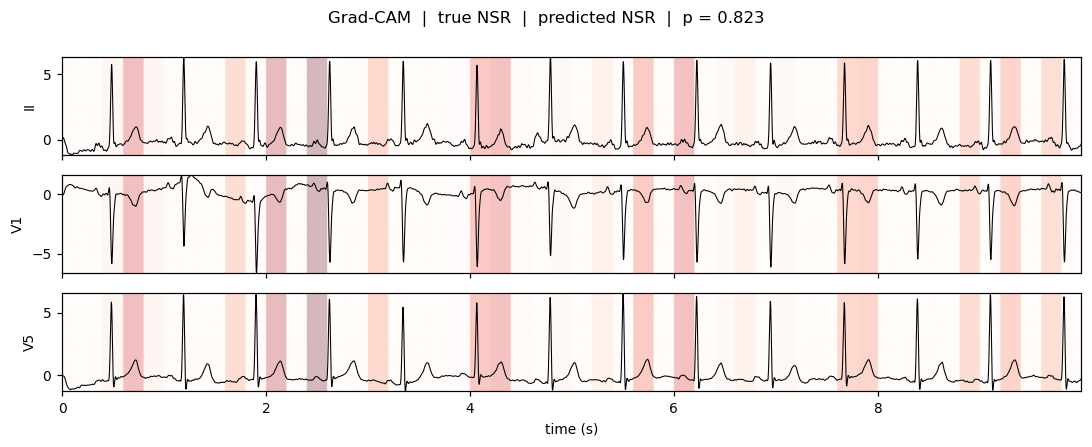

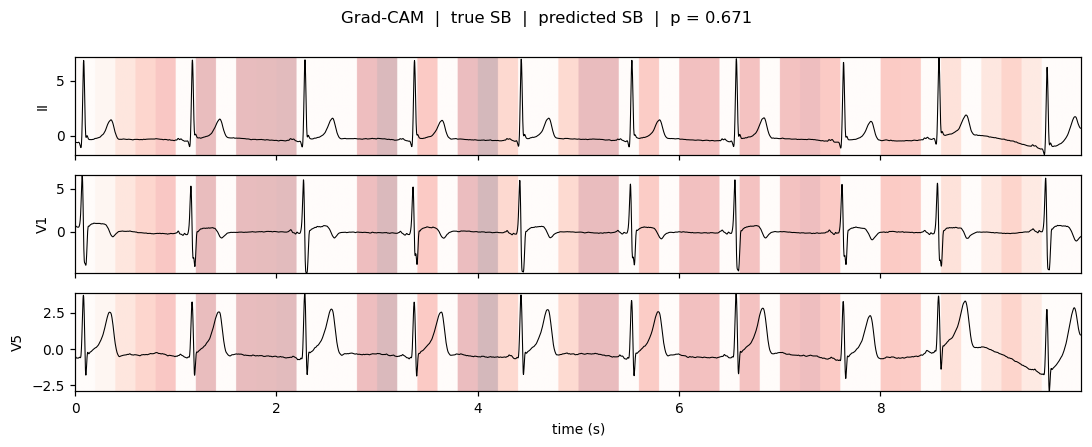

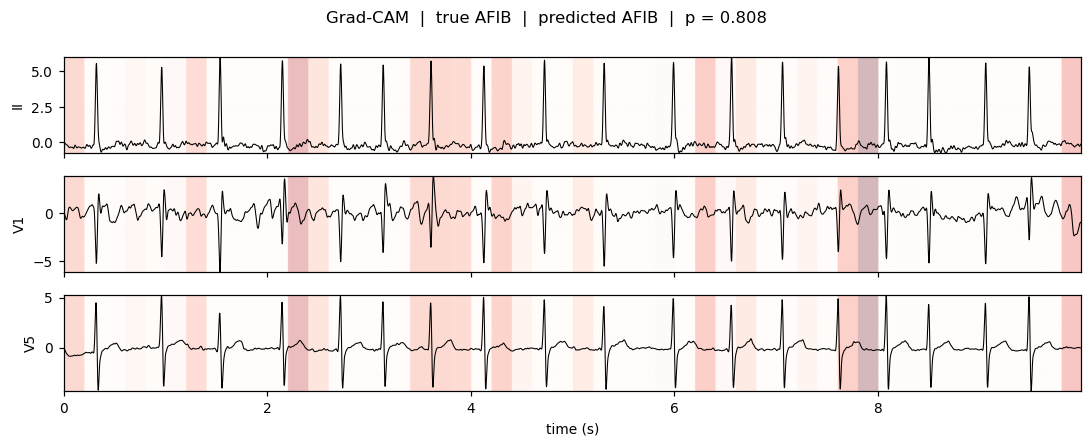

In [36]:
# Grad-CAM: where in the 10-second strip the evidence for the predicted class sits.
shown = defaultdict(int)
with ViTGradCAM(model) as cam_fn:
    for j in range(X.shape[0]):
        c = int(Y[j])
        if shown[c] or sum(shown.values()) >= 3: continue
        shown[c] = 1
        cam, pred_idx, probs = cam_fn(X[j:j+1], class_idx=None)
        env = upsample_cam(cam, cfg_model.patch_len, cfg_model.seq_len)
        sig = X[j].cpu().numpy(); t = np.arange(sig.shape[1]) / FS_HZ
        fig, axs = plt.subplots(3, 1, figsize=(10, 4), sharex=True)
        for k, lead in enumerate(["II", "V1", "V5"]):
            i = LEAD_ORDER.index(lead)
            axs[k].plot(t, sig[i], lw=.7, color="black")
            axs[k].imshow(env[None, :], aspect="auto", cmap="Reds", alpha=.28,
                          extent=[0, t[-1], sig[i].min(), sig[i].max()])
            axs[k].set_ylabel(lead); axs[k].grid(False)
        axs[-1].set_xlabel("time (s)")
        fig.suptitle(f"Grad-CAM  |  true {CLASSES[c]}  |  predicted {CLASSES[pred_idx]}"
                     f"  |  p = {probs[pred_idx]:.3f}", y=1.0)
        plt.tight_layout()
        plt.savefig(OUT_DIR / "figures" / f"gradcam_{CLASSES[c]}.png", bbox_inches="tight")
        plt.show()

In [38]:
%pip install captum==0.9.0

  Using cached captum-0.9.0-py3-none-any.whl.metadata (24 kB)
Using cached captum-0.9.0-py3-none-any.whl (455 kB)
Note: you may need to restart the kernel to use updated packages.


IG on 256 records x 50 steps in 6.7s


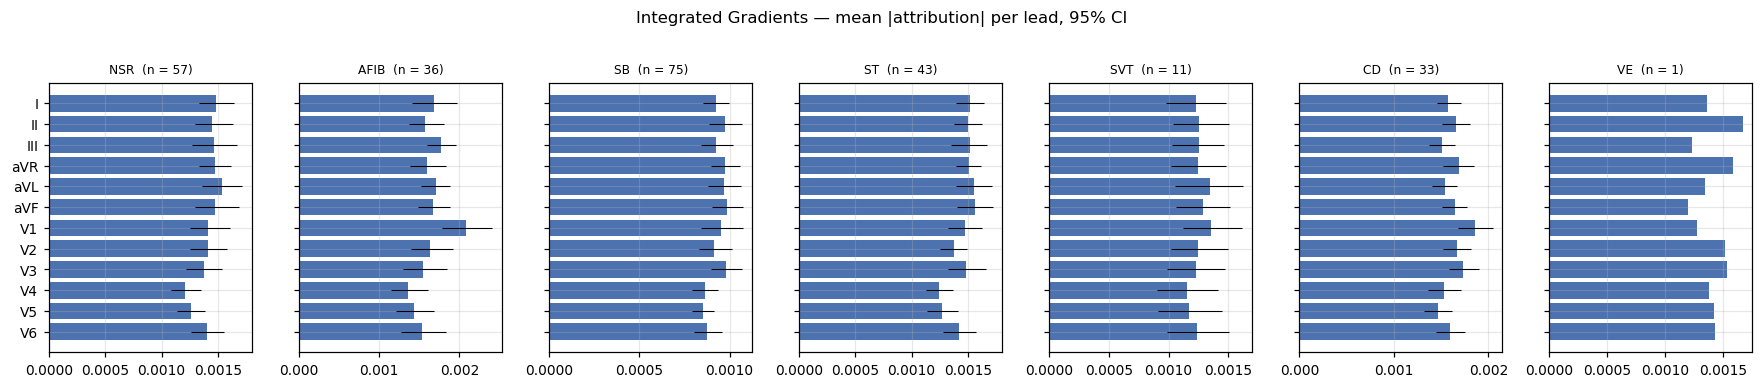

,n,top lead,max/min,CV %,top > 2nd?,top > bottom?
class,,,,,,
NSR,57,aVL,1.27,6.7,False,True
AFIB,36,V1,1.53,11.1,False,True
SB,75,aVF,1.16,5.1,False,False
ST,43,aVF,1.25,7.3,False,True
SVT,11,V1,1.18,4.7,False,False
CD,33,V1,1.26,6.7,False,True
VE,1,II,1.39,10.2,True,True


Where 'top > 2nd?' is False the first place is NOT statistically resolved. Report the
intervals, not the ordering — you already computed them.


In [39]:
# Integrated Gradients, per class and lead, with bootstrap 95% CIs.
ig_by_class = defaultdict(list)
ig_maps = np.zeros((X.shape[0], N_LEADS, cfg_model.seq_len), dtype=np.float32)
t0 = time.time()
for j in range(X.shape[0]):
    a = integrated_gradients(model, X[j:j+1].clone(), int(Y[j]), cfg_xai.ig_steps)
    ig_maps[j] = a; ig_by_class[int(Y[j])].append(a)
print(f"IG on {X.shape[0]} records x {cfg_xai.ig_steps} steps in {time.time()-t0:.1f}s")

ig_imp = per_class_lead_importance(ig_by_class, "IntegratedGradients", CLASSES,
                                   cfg_xai.ig_confidence, cfg_xai.bootstrap_iterations, SEED)
ig_df = pd.DataFrame(ig_imp.to_rows())
ig_df.to_csv(OUT_DIR / "integrated_gradients_lead_importance.csv", index=False)

present = [c for c in CLASSES if ig_imp.n_samples.get(c, 0) > 0]
fig, axes = plt.subplots(1, len(present), figsize=(2.3*len(present), 3.4), sharey=True)
for ax, c in zip(np.atleast_1d(axes), present):
    s = ig_df[ig_df["class"] == c].sort_values("lead_index")
    ax.barh(s.lead, s.mean_abs_attribution, color="#4C72B0",
            xerr=[s.mean_abs_attribution - s.ci95_low, s.ci95_high - s.mean_abs_attribution],
            error_kw=dict(lw=.7))
    ax.set_title(f"{c}  (n = {int(s.n_records.iloc[0])})", fontsize=8); ax.invert_yaxis()
fig.suptitle("Integrated Gradients — mean |attribution| per lead, 95% CI", y=1.02)
plt.tight_layout(); plt.savefig(OUT_DIR / "figures" / "ig_lead_importance.png",
                                bbox_inches="tight"); plt.show()

chk = []
for c in present:
    s = ig_df[ig_df["class"] == c].sort_values("mean_abs_attribution", ascending=False)
    top, second, bottom = s.iloc[0], s.iloc[1], s.iloc[-1]
    chk.append({"class": c, "n": int(s.n_records.iloc[0]), "top lead": top.lead,
                "max/min": round(top.mean_abs_attribution/bottom.mean_abs_attribution, 2),
                "CV %": round(100*s.mean_abs_attribution.std()/s.mean_abs_attribution.mean(), 1),
                "top > 2nd?": bool(top.ci95_low > second.ci95_high),
                "top > bottom?": bool(top.ci95_low > bottom.ci95_high)})
display(pd.DataFrame(chk).set_index("class"))
print("Where 'top > 2nd?' is False the first place is NOT statistically resolved. Report the")
print("intervals, not the ordering — you already computed them.")

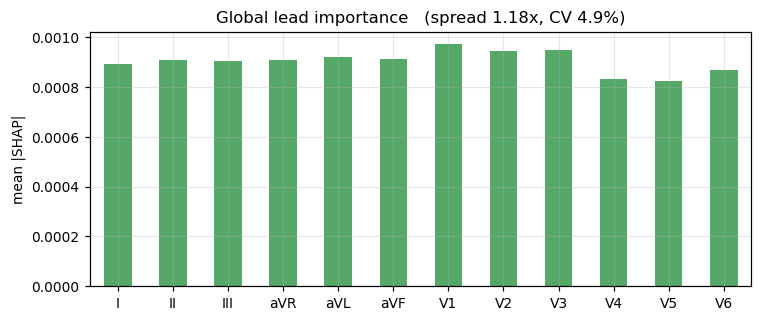

most important V1, least V5. A spread near 1 means the model
uses all twelve leads roughly equally — say so rather than claiming lead specificity
the effect size does not support.


In [40]:
# Gradient SHAP: global lead ranking.
bg = X[rng.choice(X.shape[0], size=min(cfg_xai.shap_background, X.shape[0]), replace=False)].clone()
shap_by_class = defaultdict(list)
for j in range(X.shape[0]):
    shap_by_class[int(Y[j])].append(
        gradient_shap(model, X[j:j+1].clone(), int(Y[j]), bg, n_samples=cfg_xai.shap_samples))
shap_imp = per_class_lead_importance(shap_by_class, "GradientSHAP", CLASSES,
                                     cfg_xai.ig_confidence, cfg_xai.bootstrap_iterations, SEED)
pd.DataFrame(shap_imp.to_rows()).to_csv(OUT_DIR / "shap_lead_importance.csv", index=False)

g = pd.DataFrame(shap_imp.to_rows()).groupby("lead").mean_abs_attribution.mean()
g = g.reindex(list(LEAD_ORDER))
json.dump({k: float(v) for k, v in g.items()},
          open(OUT_DIR / "shap_global_lead_importance.json", "w"), indent=2)
fig, ax = plt.subplots(figsize=(7, 3))
g.plot.bar(ax=ax, color="#55A868")
ax.set(ylabel="mean |SHAP|", xlabel="",
       title=f"Global lead importance   (spread {g.max()/g.min():.2f}x, "
             f"CV {100*g.std()/g.mean():.1f}%)")
ax.tick_params(axis="x", rotation=0); plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "shap_global.png", bbox_inches="tight"); plt.show()
print(f"most important {g.idxmax()}, least {g.idxmin()}. A spread near 1 means the model")
print("uses all twelve leads roughly equally — say so rather than claiming lead specificity")
print("the effect size does not support.")

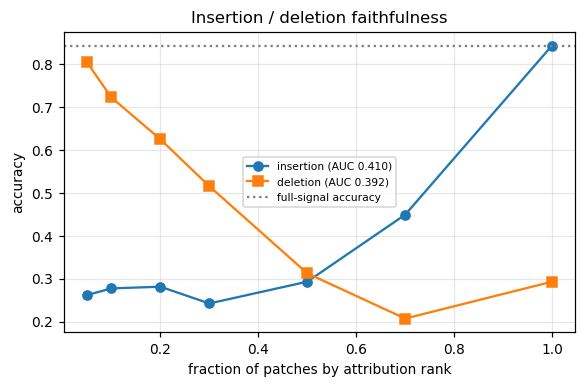

deletion AUC 0.3920 < insertion AUC 0.4097  ->  FAITHFUL
Removing the top 5% of patches costs 0.039 accuracy — a small
drop is expected for rhythm, where the evidence is rate and RR regularity spread
across the whole strip rather than one decisive segment.


In [41]:
# Faithfulness: do the attributions identify what the model actually uses?
faith = insertion_deletion(model, X, Y, ig_maps, cfg_xai.faithfulness_fractions,
                           cfg_model.patch_len)
faith["attribution_method"] = "IntegratedGradients"
faith["faithful"] = bool(faith["deletion_auc"] < faith["insertion_auc"])
json.dump(faith, open(OUT_DIR / "faithfulness.json", "w"), indent=2)

fr = list(faith["fractions"])
fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.plot(fr, faith["insertion_accuracy"], "o-", label=f"insertion (AUC {faith['insertion_auc']:.3f})")
ax.plot(fr, faith["deletion_accuracy"], "s-", label=f"deletion (AUC {faith['deletion_auc']:.3f})")
ax.axhline(faith["baseline_accuracy"], color="grey", ls=":", label="full-signal accuracy")
ax.set(xlabel="fraction of patches by attribution rank", ylabel="accuracy",
       title="Insertion / deletion faithfulness")
ax.legend(fontsize=7); plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "faithfulness.png", bbox_inches="tight"); plt.show()
print(f"deletion AUC {faith['deletion_auc']:.4f} < insertion AUC {faith['insertion_auc']:.4f}"
      f"  ->  {'FAITHFUL' if faith['faithful'] else 'NOT FAITHFUL'}")
print(f"Removing the top {fr[0]:.0%} of patches costs "
      f"{faith['baseline_accuracy'] - faith['deletion_accuracy'][0]:.3f} accuracy — a small")
print("drop is expected for rhythm, where the evidence is rate and RR regularity spread")
print("across the whole strip rather than one decisive segment.")

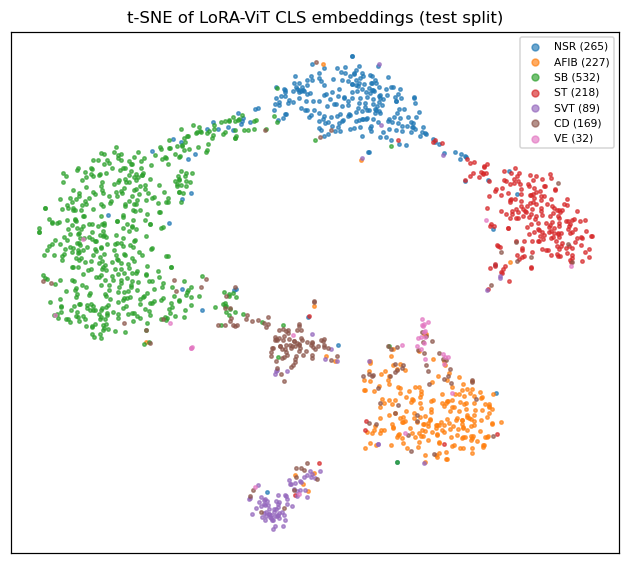

In [42]:
Z, lab = tsne_embeddings(pred.embeddings, pred.y_true, cfg_xai.tsne_perplexity,
                         cfg_xai.tsne_samples, SEED)
np.savez_compressed(OUT_DIR / "tsne.npz", Z=Z, labels=lab)
fig, ax = plt.subplots(figsize=(5.8, 5.2))
for i, c in enumerate(CLASSES):
    m = lab == i
    if m.sum(): ax.scatter(Z[m, 0], Z[m, 1], s=5, alpha=.65, label=f"{c} ({m.sum()})")
ax.set(title="t-SNE of LoRA-ViT CLS embeddings (test split)", xticks=[], yticks=[])
ax.legend(fontsize=7, markerscale=2); plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "tsne.png", bbox_inches="tight"); plt.show()

In [43]:
conc = {"integrated_gradients": clinical_concordance(ig_imp),
        "gradient_shap": clinical_concordance(shap_imp),
        "note": ("Concordance means the model's top-3 leads intersect the leads a "
                 "cardiologist would weight under AHA/ACC and ESC criteria. It is a sanity "
                 "check on the explanation, not evidence of clinical validity, and was not "
                 "adjudicated by a reader study.")}
json.dump(conc, open(OUT_DIR / "clinical_concordance.json", "w"), indent=2)

t = pd.DataFrame(conc["integrated_gradients"])
for c in ("model_top_leads", "clinically_expected_leads", "overlap"):
    t[c] = t[c].apply(lambda v: ", ".join(v) or "-")
display(t[["class", "n_records", "model_top_leads", "clinically_expected_leads",
           "overlap", "concordant"]].set_index("class"))
print(f"\n{int(t.concordant.sum())} of {len(t)} classes concordant. Read the PATTERN, not")
print("the count: concordance holds for the morphology-defined classes (AFIB, SVT, CD) and")
print("fails for the rate-defined ones (NSR, SB, ST), where 'which lead shows the rate' is")
print("not a well-posed question.")

,n_records,model_top_leads,clinically_expected_leads,overlap,concordant
class,,,,,
NSR,57,"aVL, I, aVF","II, aVF",aVF,True
AFIB,36,"V1, III, aVL","II, V1",V1,True
SB,75,"aVF, V3, aVR","II, aVF",aVF,True
ST,43,"aVF, aVL, I","V3, V4, V5",-,False
SVT,11,"V1, aVL, aVF","II, V1",V1,True
CD,33,"V1, V3, aVR","V1, V2",V1,True
VE,1,"II, aVR, V3",-,-,False



5 of 7 classes concordant. Read the PATTERN, not
the count: concordance holds for the morphology-defined classes (AFIB, SVT, CD) and
fails for the rate-defined ones (NSR, SB, ST), where 'which lead shows the rate' is
not a well-posed question.


## 11 · Paired statistics — LoRA against the full fine-tune

Identical test records, identical preprocessing. The only difference is whether the 92% of
parameters outside the adapters were trained.

In [44]:
# McNemar and DeLong
def mcnemar_test(
    y_true: np.ndarray,
    pred_a: np.ndarray,
    pred_b: np.ndarray,
    name_a: str = "model_a",
    name_b: str = "model_b",
    exact_threshold: int = 25,
) -> Dict[str, object]:
    """Paired comparison of two classifiers' error patterns on identical samples.

    Uses the exact binomial test when the number of discordant pairs is small
    (<= `exact_threshold`), where the chi-square approximation is unreliable, and the
    continuity-corrected chi-square otherwise. The manuscript reports the chi-square form.
    """
    y_true = np.asarray(y_true)
    a_ok = np.asarray(pred_a) == y_true
    b_ok = np.asarray(pred_b) == y_true

    both_correct = int(np.sum(a_ok & b_ok))
    a_only = int(np.sum(a_ok & ~b_ok))   # A correct, B wrong
    b_only = int(np.sum(~a_ok & b_ok))   # B correct, A wrong
    both_wrong = int(np.sum(~a_ok & ~b_ok))
    n = int(y_true.size)
    discordant = a_only + b_only

    if discordant == 0:
        statistic, p_value, method = 0.0, 1.0, "degenerate_no_discordant_pairs"
        statistic_name = "none (no discordant pairs)"
    elif discordant <= exact_threshold:
        p_value = float(stats.binomtest(a_only, discordant, 0.5).pvalue)
        statistic = float(min(a_only, b_only))
        # NOT a chi-square. Reporting it under a chi2 label -- as this did -- produces
        # impossible-looking lines such as "chi2=11.0, p=1.0000" in a paper.
        statistic_name = "min(b, c), exact binomial"
        method = "exact_binomial"
    else:
        statistic = float((abs(a_only - b_only) - 1) ** 2 / discordant)
        p_value = float(stats.chi2.sf(statistic, df=1))
        statistic_name = "chi-square with continuity correction, df=1"
        method = "chi2_continuity_corrected"

    return {
        "model_a": name_a,
        "model_b": name_b,
        "both_correct": both_correct,
        f"{name_a}_correct_{name_b}_wrong": a_only,
        f"{name_b}_correct_{name_a}_wrong": b_only,
        "both_wrong": both_wrong,
        "n_samples": n,
        "discordant_pairs": discordant,
        "disagreement_rate": round(discordant / n, 6) if n else 0.0,
        "statistic": round(statistic, 6),
        "statistic_name": statistic_name,
        "p_value": p_value,
        "method": method,
        "significant_at_0.05": bool(p_value < 0.05),
        # Three genuinely different outcomes. The previous text collapsed the first two,
        # so a run with 22 discordant pairs was reported as "no evidence the two models
        # misclassify different samples" -- which is false: they demonstrably do, they
        # simply do so symmetrically.
        "interpretation": (
            f"the two models produce IDENTICAL predictions on all {n} samples; "
            "the comparison is degenerate and no test is possible"
            if discordant == 0 else
            f"{name_a} is right on {a_only} of the {discordant} disagreements and "
            f"{name_b} on {b_only}; the difference is significant (p = {p_value:.4g}), so "
            f"{(name_a if a_only > b_only else name_b)} makes fewer errors"
            if p_value < 0.05 else
            f"the models disagree on {discordant} of {n} samples "
            f"({name_a} right on {a_only}, {name_b} on {b_only}) but neither is "
            f"systematically more accurate (p = {p_value:.4g}). Note this is a failure to "
            "reject a difference, not a demonstration of equivalence -- for that, "
            "pre-specify a margin and run an equivalence test"
        ),
    }


def _midrank(x: np.ndarray) -> np.ndarray:
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(N, dtype=float)
    out[J] = T
    return out


def _fast_delong(predictions_sorted_transposed: np.ndarray, m: int):
    """Sun & Xu (2014) fast DeLong. First `m` columns are the positive samples."""
    k, total = predictions_sorted_transposed.shape
    n = total - m
    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]

    tx = np.empty((k, m)); ty = np.empty((k, n)); tz = np.empty((k, total))
    for r in range(k):
        tx[r] = _midrank(pos[r])
        ty[r] = _midrank(neg[r])
        tz[r] = _midrank(predictions_sorted_transposed[r])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    if k == 1:
        sx = np.array([[float(sx)]])
        sy = np.array([[float(sy)]])
    delongcov = sx / m + sy / n
    return aucs, delongcov


def delong_roc_test(
    y_true: np.ndarray, probs_a: np.ndarray, probs_b: np.ndarray
) -> Tuple[float, float, float, float]:
    """Returns (auc_a, auc_b, z, p) for one binary problem on paired predictions."""
    y = np.asarray(y_true).astype(int)
    order = (-y).argsort(kind="mergesort")   # positives first, stable
    label_sorted = y[order]
    m = int(label_sorted.sum())
    n = len(y) - m
    if m == 0 or n == 0:
        return float("nan"), float("nan"), float("nan"), float("nan")

    preds = np.vstack([np.asarray(probs_a)[order], np.asarray(probs_b)[order]])
    aucs, cov = _fast_delong(preds, m)
    diff = aucs[0] - aucs[1]
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    if var <= 0:
        # Identical rankings, or a perfect AUC in both -> zero variance, p undefined.
        return float(aucs[0]), float(aucs[1]), float("nan"), float("nan")
    z = diff / np.sqrt(var)
    p = 2.0 * stats.norm.sf(abs(z))
    return float(aucs[0]), float(aucs[1]), float(z), float(p)


def delong_per_class(
    y_true: np.ndarray,
    probs_a: np.ndarray,
    probs_b: np.ndarray,
    class_names=None,
    n_bootstrap: int = 1000,
    seed: int = 42,
    name_a: str = "no_lora",
    name_b: str = "lora",
) -> Dict[str, object]:
    """Per-class one-vs-rest DeLong plus a bootstrap CI on the AUC difference (Table 5)."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    rows: List[Dict[str, object]] = []

    for i, cname in enumerate(class_names):
        yi = (y_true == i).astype(int)
        if yi.sum() == 0 or yi.sum() == len(yi):
            rows.append(
                {"class": cname, "auc_" + name_a: None, "auc_" + name_b: None,
                 "difference": None, "ci95_low": None, "ci95_high": None,
                 "z": None, "p_value": None, "estimable": False,
                 "reason": "class absent from this split"}
            )
            continue

        auc_a, auc_b, z, p = delong_roc_test(yi, probs_a[:, i], probs_b[:, i])

        diffs = np.full(n_bootstrap, np.nan)
        idx_pos = np.where(yi == 1)[0]
        idx_neg = np.where(yi == 0)[0]
        from sklearn.metrics import roc_auc_score

        for b in range(n_bootstrap):
            sp = rng.choice(idx_pos, size=idx_pos.size, replace=True)
            sn = rng.choice(idx_neg, size=idx_neg.size, replace=True)
            s = np.concatenate([sp, sn])
            ys = yi[s]
            if ys.sum() in (0, ys.size):
                continue
            diffs[b] = roc_auc_score(ys, probs_a[s, i]) - roc_auc_score(ys, probs_b[s, i])
        finite = diffs[np.isfinite(diffs)]
        var_zero = bool(finite.size and np.allclose(finite, 0.0))

        rows.append(
            {
                "class": cname,
                f"auc_{name_a}": round(auc_a, 6),
                f"auc_{name_b}": round(auc_b, 6),
                "difference": round(auc_a - auc_b, 6),
                "ci95_low": None if var_zero or not finite.size else round(float(np.quantile(finite, 0.025)), 6),
                "ci95_high": None if var_zero or not finite.size else round(float(np.quantile(finite, 0.975)), 6),
                "z": None if not np.isfinite(z) else round(z, 6),
                "p_value": None if not np.isfinite(p) else p,
                "estimable": bool(np.isfinite(p)) and not var_zero,
                "reason": (
                    "perfect or identical AUC in both models -> zero bootstrap variance; "
                    "CI and p-value are not estimable"
                    if var_zero or not np.isfinite(p)
                    else ""
                ),
                "significant_at_0.05": bool(np.isfinite(p) and p < 0.05 and not var_zero),
            }
        )

    est = [r for r in rows if r.get("estimable")]
    macro_a = np.mean([r[f"auc_{name_a}"] for r in rows if r.get(f"auc_{name_a}") is not None])
    macro_b = np.mean([r[f"auc_{name_b}"] for r in rows if r.get(f"auc_{name_b}") is not None])
    return {
        "model_a": name_a,
        "model_b": name_b,
        "n_bootstrap": n_bootstrap,
        "per_class": rows,
        "macro_auc_" + name_a: float(macro_a),
        "macro_auc_" + name_b: float(macro_b),
        "macro_difference": float(macro_a - macro_b),
        "n_estimable_classes": len(est),
        "note": (
            "Per-class DeLong statistics do not aggregate to a single macro-level test; "
            "the macro AUCs are a summary average only."
        ),
    }

In [45]:
base_model = load_model(with_lora=False)
p_base = predict(base_model, loaders["test"], device, record_ids=test_ids,
                 return_embeddings=False)

mc = mcnemar_test(p_base.y_true, p_base.y_pred, pred.y_pred, "no_lora", "lora")
json.dump(mc, open(OUT_DIR / "mcnemar.json", "w"), indent=2)
display(pd.Series({
    "both correct": mc["both_correct"], "both wrong": mc["both_wrong"],
    "no_lora right / lora wrong": mc["no_lora_correct_lora_wrong"],
    "lora right / no_lora wrong": mc["lora_correct_no_lora_wrong"],
    "discordant pairs": mc["discordant_pairs"],
    mc["statistic_name"]: mc["statistic"],
    "p": round(mc["p_value"], 4), "method": mc["method"],
}, name="McNemar").to_frame())
print(mc["interpretation"])

,McNemar
both correct,1295
both wrong,217
no_lora right / lora wrong,13
lora right / no_lora wrong,7
discordant pairs,20
"min(b, c), exact binomial",7.0
p,0.2632
method,exact_binomial


the models disagree on 20 of 1532 samples (no_lora right on 13, lora on 7) but neither is systematically more accurate (p = 0.2632). Note this is a failure to reject a difference, not a demonstration of equivalence -- for that, pre-specify a margin and run an equivalence test


In [46]:
dl = delong_per_class(p_base.y_true, p_base.probs, pred.probs, CLASSES,
                      cfg_xai.bootstrap_iterations, SEED, "no_lora", "lora")
json.dump(dl, open(OUT_DIR / "delong_auc.json", "w"), indent=2)
tt = pd.DataFrame(dl["per_class"])[["class", "auc_no_lora", "auc_lora", "difference",
                                    "ci95_low", "ci95_high", "p_value", "estimable"]]
display(tt.round(6).set_index("class"))
print(f"macro AUC   no_lora {dl['macro_auc_no_lora']:.4f}   lora {dl['macro_auc_lora']:.4f}")

ps = tt.set_index("class")["p_value"].dropna().sort_values()
m = len(ps)
holm = np.maximum.accumulate((ps.values * (m - np.arange(m))).clip(max=1.0))
display(pd.DataFrame({"raw p": ps.round(4), "Holm-corrected": np.round(holm, 4)}))
print("An AUC difference of 1e-4 can reach p < 0.05 on paired scores. Correct for the seven")
print("tests, and state an equivalence margin if the claim is 'LoRA matches full fine-tuning'.")

,auc_no_lora,auc_lora,difference,ci95_low,ci95_high,p_value,estimable
class,,,,,,,
NSR,0.984471,0.985209,-0.000739,-0.001632,-0.000003,0.065383,True
AFIB,0.981110,0.981272,-0.000162,-0.000787,0.000392,0.572020,True
SB,0.991039,0.991041,-0.000002,-0.000448,0.000400,0.993191,True
ST,0.988811,0.989063,-0.000251,-0.000946,0.000168,0.368392,True
SVT,0.972817,0.975947,-0.003130,-0.009408,0.000319,0.247568,True
CD,0.902139,0.900741,0.001398,-0.000560,0.003721,0.215600,True
VE,0.876229,0.873563,0.002667,-0.001043,0.008025,0.255404,True


macro AUC   no_lora 0.9567   lora 0.9567


,raw p,Holm-corrected
class,,
NSR,0.0654,0.4577
CD,0.2156,1.0000
SVT,0.2476,1.0000
VE,0.2554,1.0000
ST,0.3684,1.0000
AFIB,0.5720,1.0000
SB,0.9932,1.0000


An AUC difference of 1e-4 can reach p < 0.05 on paired scores. Correct for the seven
tests, and state an equivalence margin if the claim is 'LoRA matches full fine-tuning'.


## 12 · Artefacts and summary

In [47]:
metrics.update({"split": "test", "resolution_order": TAXONOMY, "recipe": RECIPE,
                "patch_len": cfg_model.patch_len,
                "cohen_kappa": float(kappa), "matthews_cc": float(mcc)})
json.dump(metrics, open(OUT_DIR / "metrics.json", "w"), indent=2, default=str)
np.save(OUT_DIR / "confusion_matrix.npy", CM.astype(np.int64))
json.dump({"total": dict(index_report.label_counts),
           "splits": {s: dict(c) for s, c in index_report.split_counts.items()},
           "n_indexed": index_report.n_indexed,
           "n_unassigned": index_report.n_unassigned},
          open(OUT_DIR / "index_report.json", "w"), indent=2)
json.dump({"no_lora": acct_base.to_dict(), "lora": acct_lora.to_dict()},
          open(OUT_DIR / "param_efficiency.json", "w"), indent=2)
pd.DataFrame({"record_id": pred.record_ids,
              "true": [CLASSES[i] for i in pred.y_true],
              "pred": [CLASSES[i] for i in pred.y_pred],
              **{f"prob_{c}": pred.probs[:, i] for i, c in enumerate(CLASSES)}}
             ).to_csv(OUT_DIR / "predictions.csv", index=False)
print("wrote:", *sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()), sep="\n  ")

wrote:
  calibration.json
  clinical_concordance.json
  confusion_matrix.npy
  delong_auc.json
  faithfulness.json
  index_report.json
  integrated_gradients_lead_importance.csv
  mcnemar.json
  metrics.json
  param_efficiency.json
  predictions.csv
  shap_global_lead_importance.json
  shap_lead_importance.csv
  training_history.json
  tsne.npz


In [48]:
display(pd.DataFrame({"value": [
    TAXONOMY, RECIPE, int(metrics["n_samples"]),
    round(metrics["overall_accuracy"], 4), round(metrics["balanced_accuracy"], 4),
    round(metrics["macro_f1"], 4), round(metrics["macro_auc"], 4),
    round(kappa, 4), round(mcc, 4),
    f"{acct_base.total_parameters:,}", f"{acct_lora.lora_parameters:,}",
    f"{acct_lora.total_parameters:,}", round(acct_lora.trainable_reduction_pct, 4),
    round(acct_lora.reduction_factor, 4), round(metrics["inference_ms_per_sample"], 3),
    f"{faith['deletion_auc']:.3f} < {faith['insertion_auc']:.3f}",
    calib["temperature"], mc["discordant_pairs"],
]}, index=["taxonomy", "recipe", "test records", "accuracy", "balanced accuracy", "macro F1",
           "macro AUC", "Cohen kappa", "Matthews CC", "base parameters", "LoRA adapters",
           "LoRA total", "reduction (%)", "reduction (x)", "inference ms/sample",
           "faithfulness (deletion < insertion)", "temperature",
           "LoRA vs backbone discordant pairs"]))

# The literature-comparable figure: the standard Chapman four-class protocol, which excludes
# the beat-level findings entirely.
groups = {"SR": ["NSR"], "AFIB": ["AFIB"], "GSVT": ["ST", "SVT"], "SB": ["SB"]}
gl = [g for g in groups if all(c in CLASSES for c in groups[g])]
G = np.zeros((len(gl), len(gl)))
for a, ga in enumerate(gl):
    for b, gb in enumerate(gl):
        G[a, b] = CM[np.ix_([CLASSES.index(x) for x in groups[ga]],
                            [CLASSES.index(x) for x in groups[gb]])].sum()
rec4 = np.diag(G) / G.sum(1)
print(f"\nChapman four-class collapse — CD and VE excluded, as that protocol does:")
print(f"  n = {int(G.sum())}   accuracy {np.trace(G)/G.sum():.4f}   "
      f"balanced accuracy {rec4.mean():.4f}")
print("  per-class recall:", {c: round(r, 3) for c, r in zip(gl, rec4)})
print("\nReport BOTH, clearly labelled. The seven-class task adds CD and VE, which are")
print("beat-level findings coexisting with every rhythm, and is materially harder.")

,value
taxonomy,canonical_v2
recipe,v2
test records,1532
accuracy,0.8499
balanced accuracy,0.8166
macro F1,0.7874
macro AUC,0.9567
Cohen kappa,0.8115
Matthews CC,0.812
base parameters,"1,648,839"



Chapman four-class collapse — CD and VE excluded, as that protocol does:
  n = 1262   accuracy 0.9390   balanced accuracy 0.9404
  per-class recall: {'SR': np.float64(0.919), 'AFIB': np.float64(0.961), 'GSVT': np.float64(0.945), 'SB': np.float64(0.937)}

Report BOTH, clearly labelled. The seven-class task adds CD and VE, which are
beat-level findings coexisting with every rhythm, and is materially harder.


## 13 · Equivalence check

This notebook is generated by extracting source from `solution/src/ecgvit/`, so it *should*
be the same code the 221-test suite covers. This cell proves it rather than asserting it:
it imports the package alongside the notebook's own definitions and compares the label
mapping, the label assigned to every indexed record, and the parameter counts.

Skipped with a clear message if the package is not importable — the notebook does not
depend on it.

In [49]:
try:
    sys.path.insert(0, str(Path("solution") / "src"))
    from ecgvit.labels import get_class_map as _pkg_map
    from ecgvit.model import LoRAViT as _PkgViT
    from ecgvit.lora import count_parameters as _pkg_count, inject_lora as _pkg_inject
    from ecgvit.config import ModelConfig as _PkgMC, LoRAConfig as _PkgLC
except Exception as exc:
    print(f"package not importable ({exc}) — skipping. The notebook stands alone.")
else:
    checks = []
    pkg = _pkg_map(Path("environment") / "data", TAXONOMY)
    checks.append(("class list", pkg.classes == CLASSES))
    checks.append(("class index", dict(pkg.class_index) == CLASS_IX))
    checks.append(("precedence order", list(pkg.resolution_order) == TAX["resolution_order"]))
    checks.append(("fallback class", pkg.fallback == TAX["fallback_class"]))
    checks.append(("SNOMED buckets", {c: sorted(pkg.class_to_codes[c]) for c in pkg.classes}
                  == {c: sorted(TAX["class_to_codes"][c]) for c in CLASSES}))

    mismatch = sum(1 for r in records
                   if pkg.resolve(r.codes, r.record_id).label != r.label)
    checks.append((f"label of all {len(records):,} indexed records", mismatch == 0))

    pm = _PkgViT(_PkgMC(n_classes=len(CLASSES), patch_len=cfg_model.patch_len))
    _pkg_inject(pm, _PkgLC())
    pa = _pkg_count(pm, _PkgLC())
    checks.append(("total parameters", pa.total_parameters == acct_lora.total_parameters))
    checks.append(("adapter parameters", pa.lora_parameters == acct_lora.lora_parameters))

    display(pd.DataFrame([{"check": k, "identical": "yes" if v else "NO"} for k, v in checks])
            .set_index("check"))
    print("PASS — the notebook and the package are the same implementation."
          if all(v for _, v in checks) else
          "MISMATCH — regenerate with notebooks/build_standalone.py")

package not importable (No module named 'ecgvit') — skipping. The notebook stands alone.


---

### Command line equivalent

```powershell
python -m ecgvit.cli --resolution-order canonical_v2 --recipe v2 `
    --batch-size 64 --num-workers 4 run-all
python -m ecgvit.cli --resolution-order canonical_v2 --recipe v2 --cv-folds 5 cv
```

`docs/UPGRADE_PLAN.md` — the protocol and the evidence behind each setting.
`docs/RESULTS_REVIEW.md` — referee-style audit of the first completed run.
`docs/CLASS_MAPPING.md` — the taxonomy and its five corrections.

**Data.** [Chapman-Shaoxing](https://physionet.org/content/ecg-arrhythmia/1.0.0/),
PhysioNet v1.0.0, CC BY 4.0 — Zheng, J., Guo, H. & Chu, H. (2022); Zheng, J. et al.,
*Scientific Data* 7, 48 (2020). De-identified by the providers; age and sex are never used
as model inputs. **Code.** MIT.

> Research artefact. Not a medical device, not validated for clinical use, not evaluated in
> a reader study. Concordance with AHA/ACC and ESC criteria is a sanity check on the model's
> attributions, not evidence of diagnostic validity.